In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/MS Research/Sem 1/ML/Phase 2 Project/Dataset/data-forest/covtype.csv')

## Data




In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

#df = pd.read_csv('/content/drive/MyDrive/MS Research/Sem 1/ML/Phase 2 Project/Dataset/data-forest/covtype.csv')

print("\nFirst 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nShape of the DataFrame (rows, columns):")
print(df.shape)

print("\nColumn names in the DataFrame:")
print(df.columns.tolist())

column_to_check = 'Forest Cover Type'
print(f"\nDoes the column '{column_to_check}' exist in the DataFrame? {'Forest Cover Type' in df.columns}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

First 5 rows of the DataFrame:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade

## Descriptive Statistics

### Subtask:
Generate comprehensive descriptive statistics for all numerical features in the DataFrame. Additionally, identify unique values and their counts for any categorical or discrete features to understand their distribution.


In [ ]:
print("Descriptive Statistics for Numerical Features:")
print(df.describe())

categorical_discrete_cols = [
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
    'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
    'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
    'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
    'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
    'Cover_Type'
]

print("\nUnique values and counts for Categorical/Discrete Features:")
for col in categorical_discrete_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
    else:
        print(f"Column '{col}' not found in DataFrame. Skipping.")

Descriptive Statistics for Numerical Features:
           Elevation         Aspect          Slope  \
count  581012.000000  581012.000000  581012.000000   
mean     2959.365301     155.656807      14.103704   
std       279.984734     111.913721       7.488242   
min      1859.000000       0.000000       0.000000   
25%      2809.000000      58.000000       9.000000   
50%      2996.000000     127.000000      13.000000   
75%      3163.000000     260.000000      18.000000   
max      3858.000000     360.000000      66.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     581012.000000                   581012.000000   
mean                         269.428217                       46.418855   
std                          212.549356                       58.295232   
min                            0.000000                     -173.000000   
25%                          108.000000                        7.000000   
50%             

In [ ]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

columns_with_missing_values = missing_values[missing_values > 0].index.tolist()

if columns_with_missing_values:
    print(f"\nColumns with missing values: {columns_with_missing_values}")
else:
    print("\nNo missing values found in the DataFrame.")

Missing values per column:
Series([], dtype: int64)

No missing values found in the DataFrame.


## Univariate Analysis of Numerical Features



Numerical columns selected for univariate analysis: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']


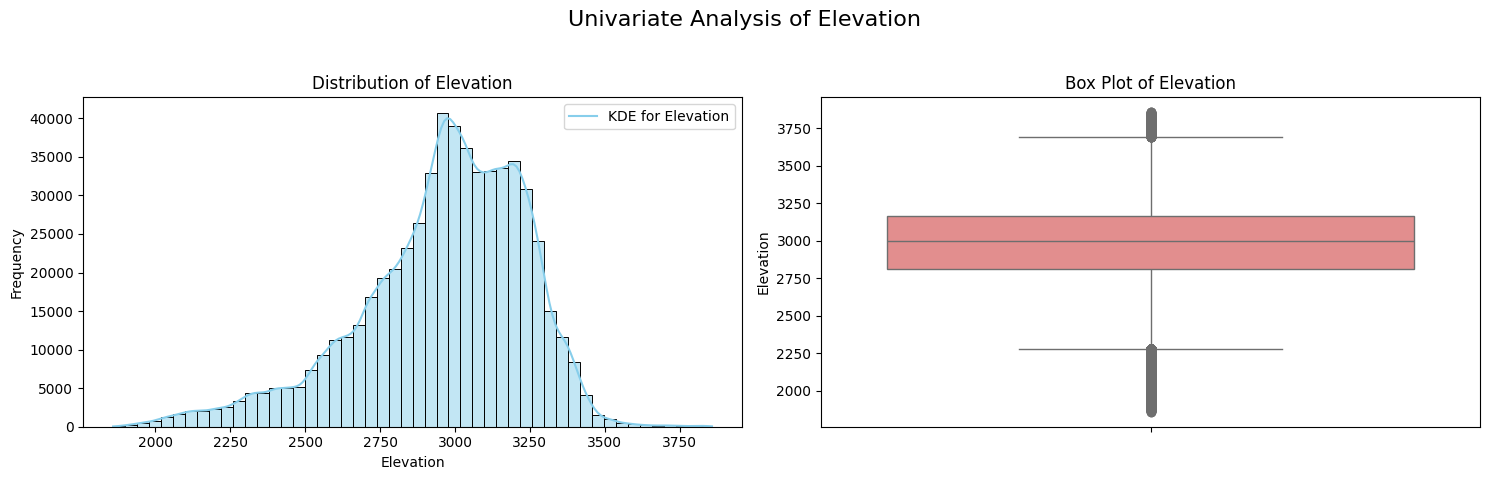

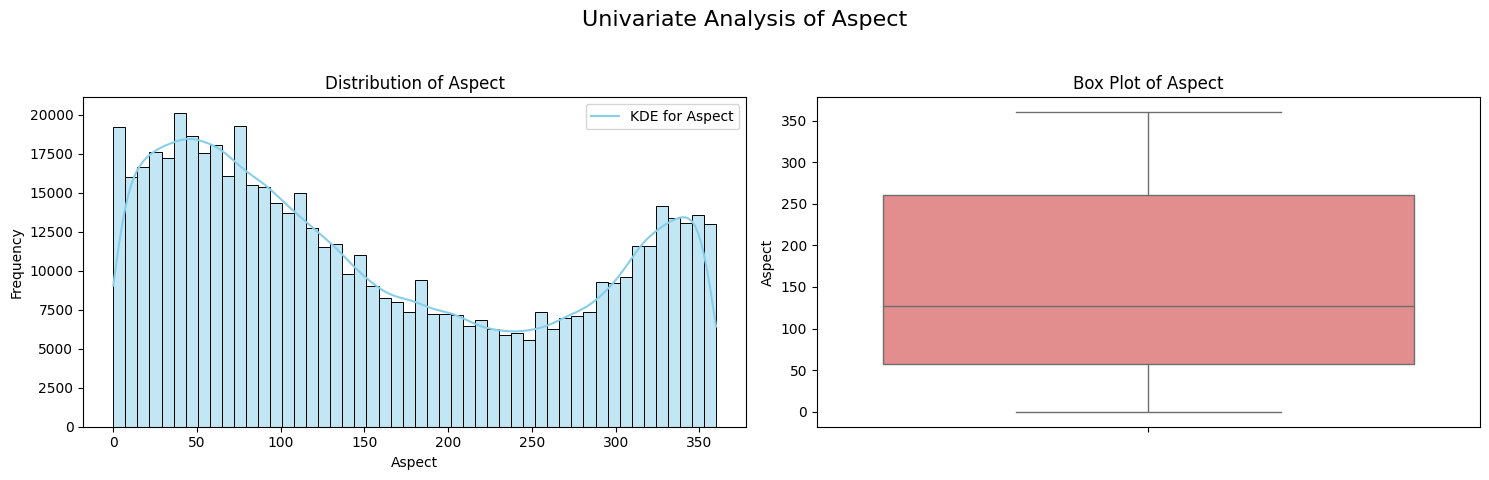

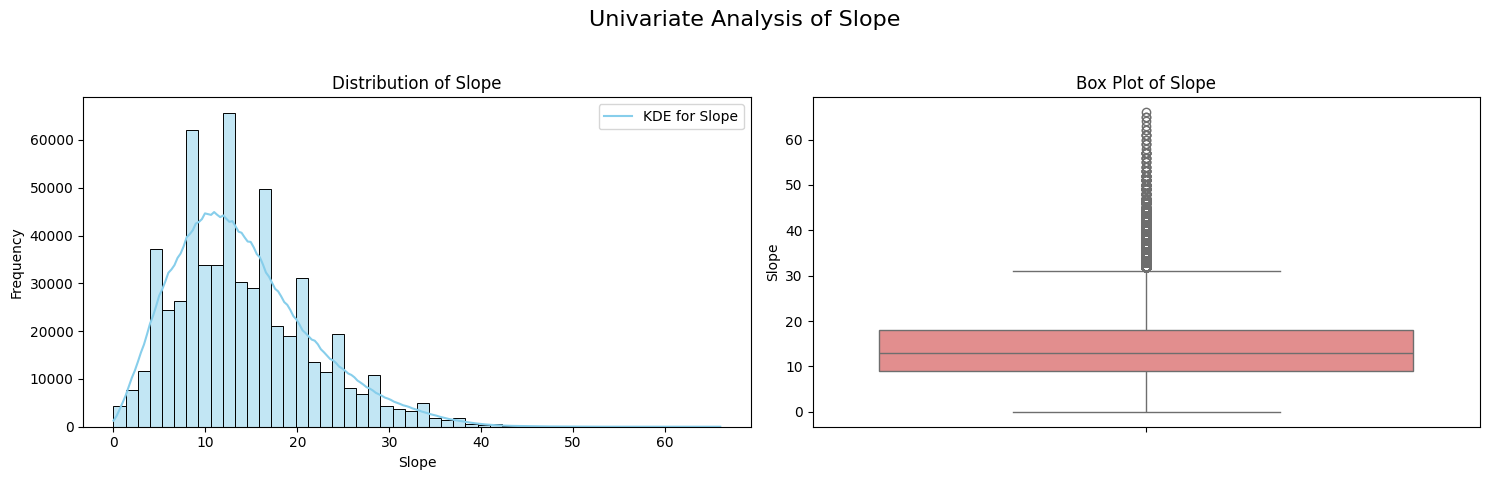

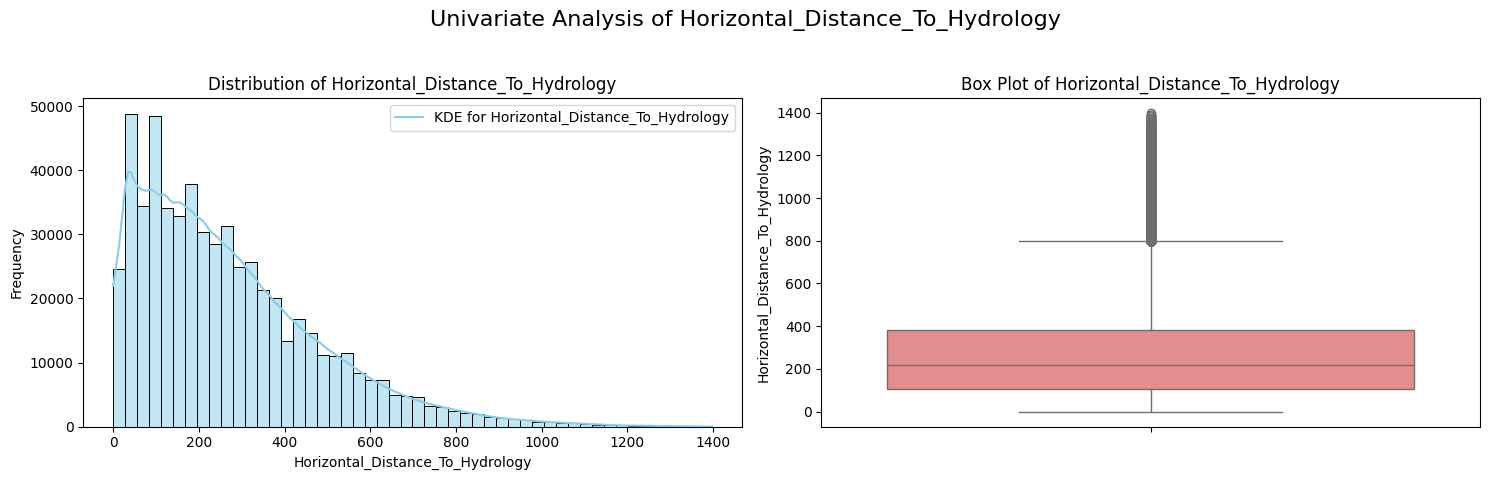

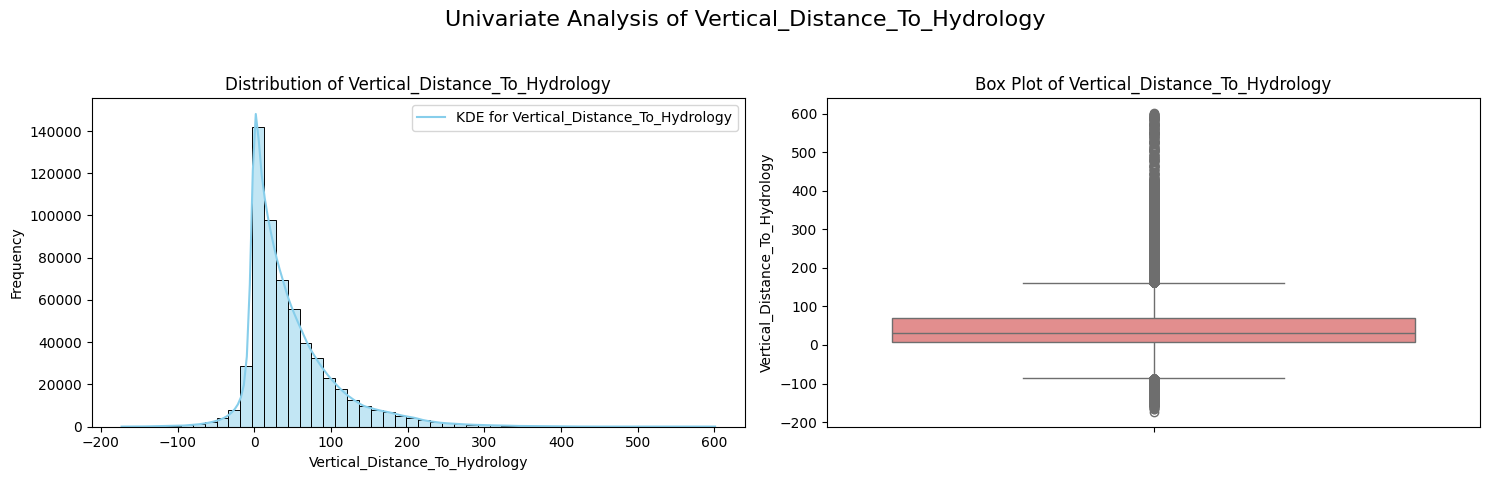

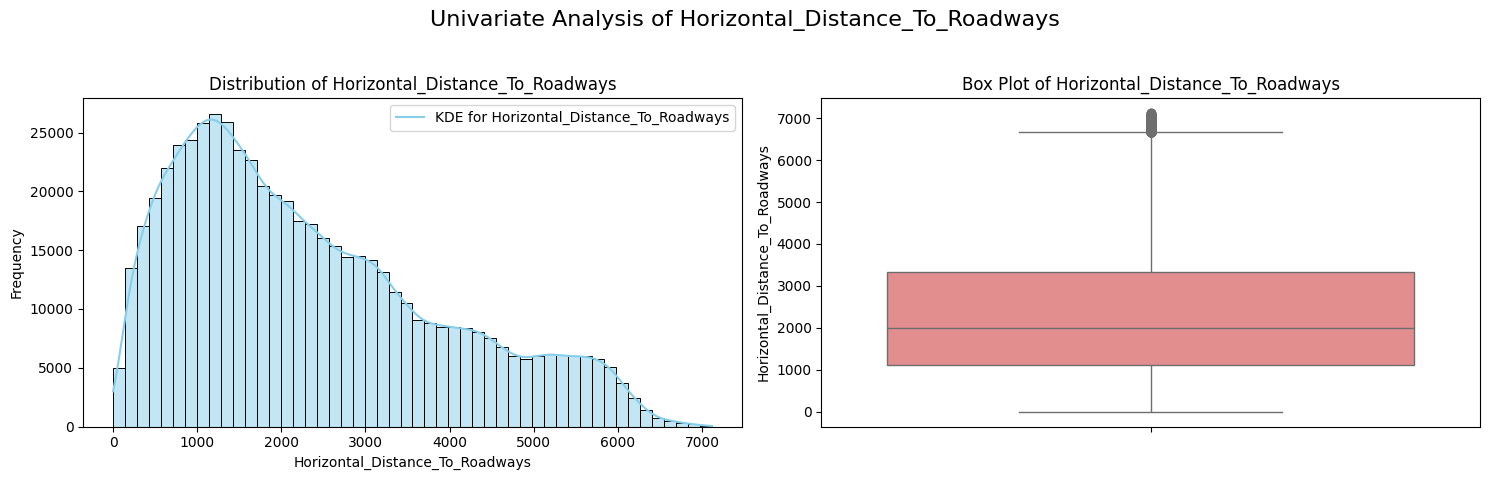

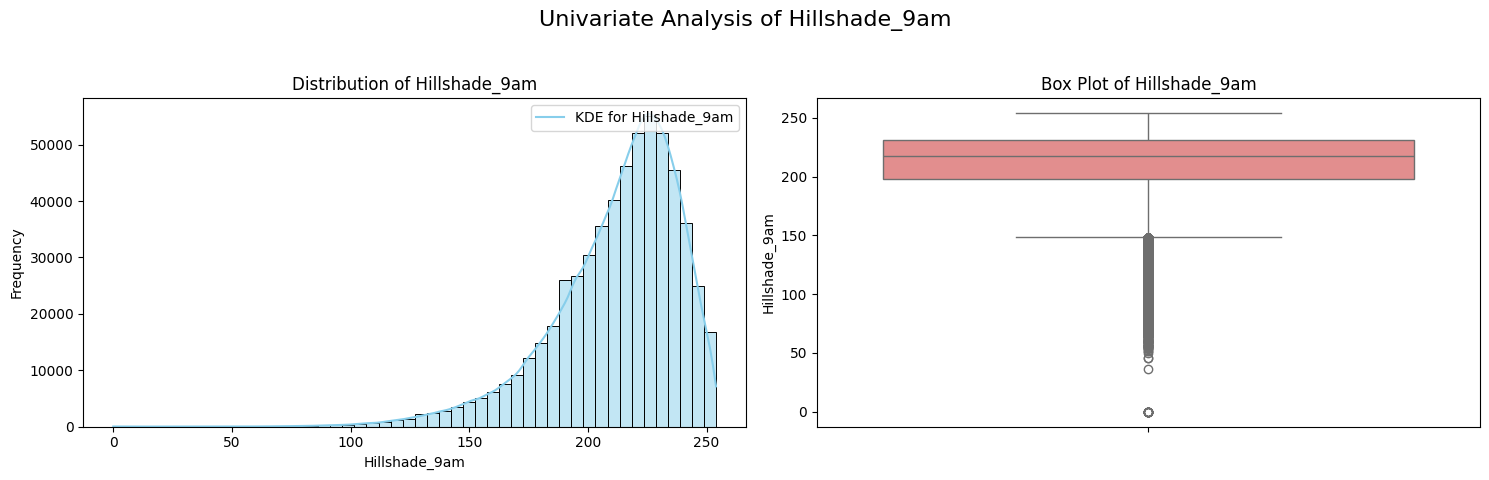

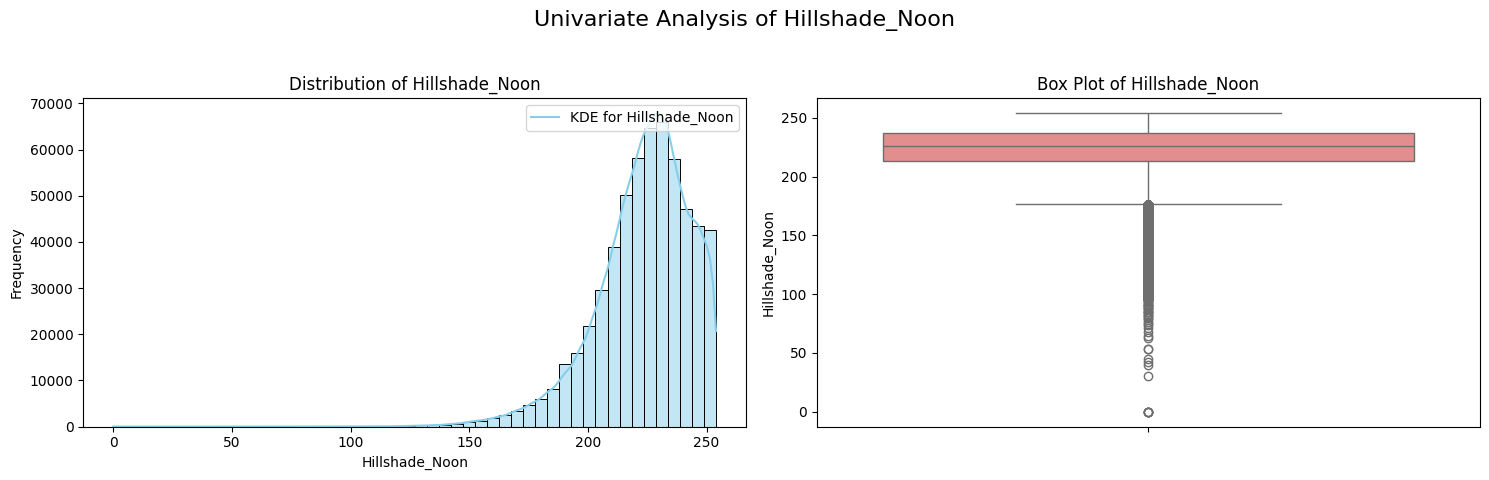

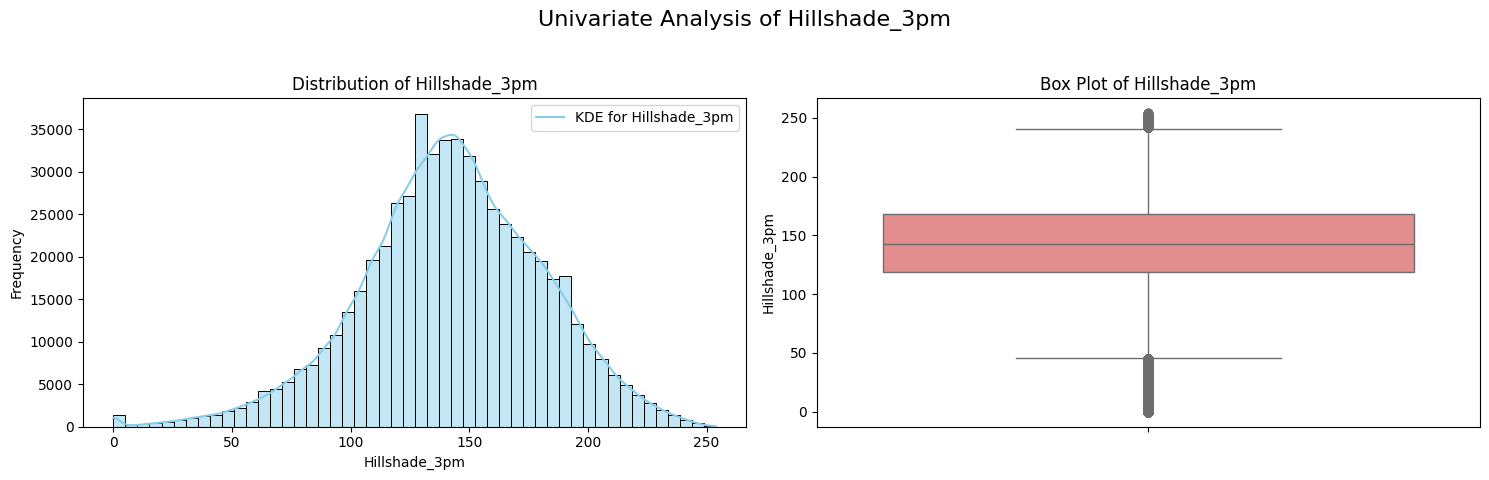

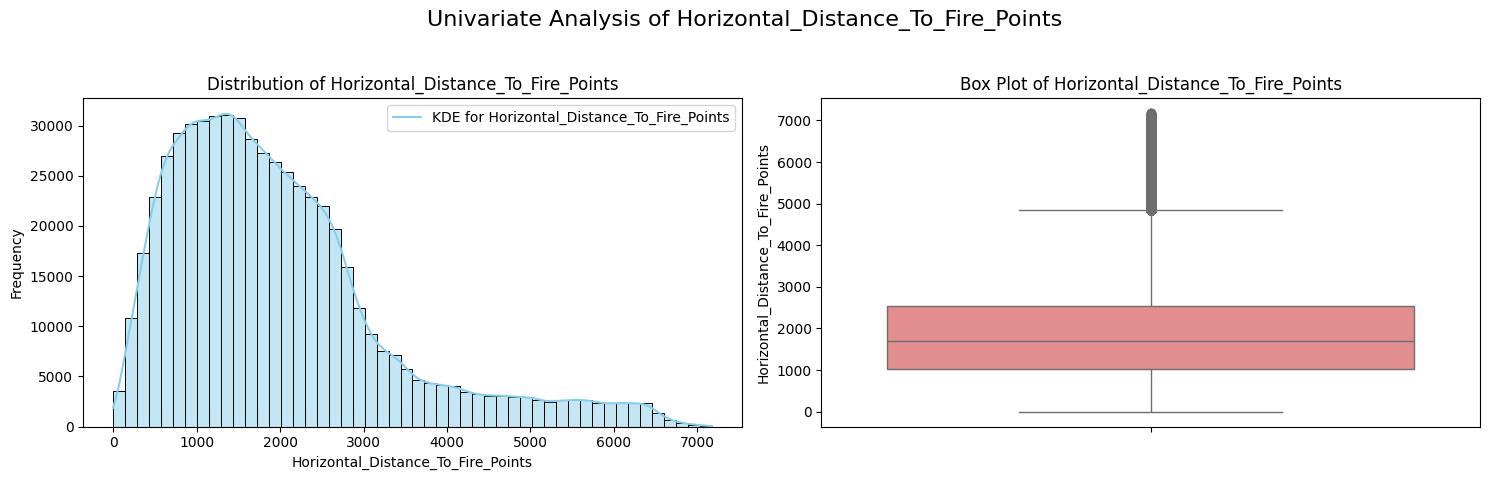

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns to analyze based on instructions
# Exclude 'Wilderness_AreaX', 'Soil_TypeX', and 'Cover_Type'

all_columns = df.columns.tolist()

# Columns to explicitly exclude from univariate numerical analysis
# These were either treated as categorical/discrete or are the target variable
excluded_cols = [
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
    'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
    'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
    'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
    'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
    'Cover_Type'
]

numerical_cols_for_analysis = [col for col in all_columns if col not in excluded_cols]

print(f"Numerical columns selected for univariate analysis: {numerical_cols_for_analysis}")

# Create visualizations for each numerical feature
for col in numerical_cols_for_analysis:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Univariate Analysis of {col}', fontsize=16)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0], bins=50, color='skyblue')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].legend([f'KDE for {col}'], loc='upper right')

    # Box Plot
    sns.boxplot(y=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_ylabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Generating bar plots for categorical/discrete features...


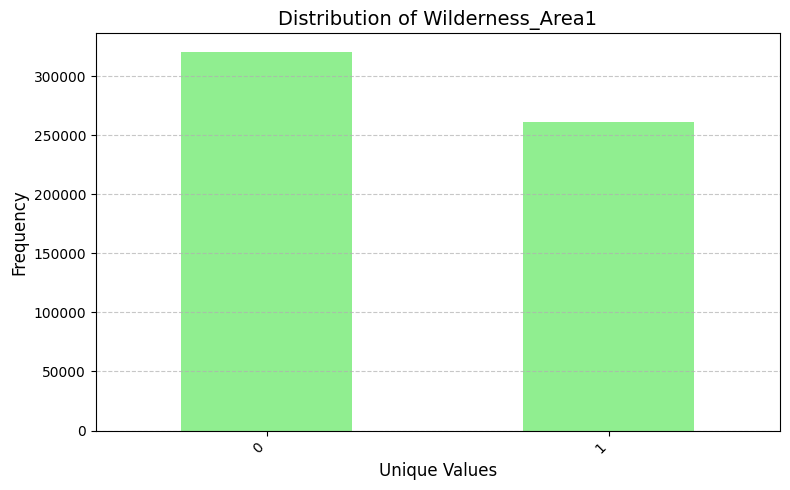

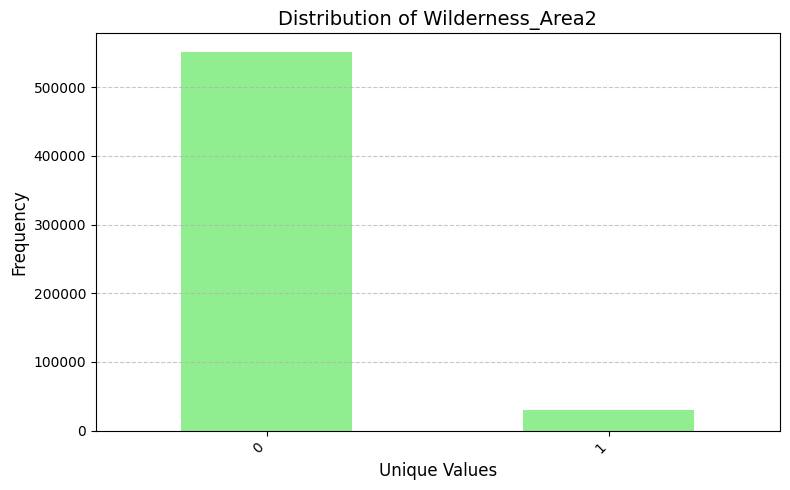

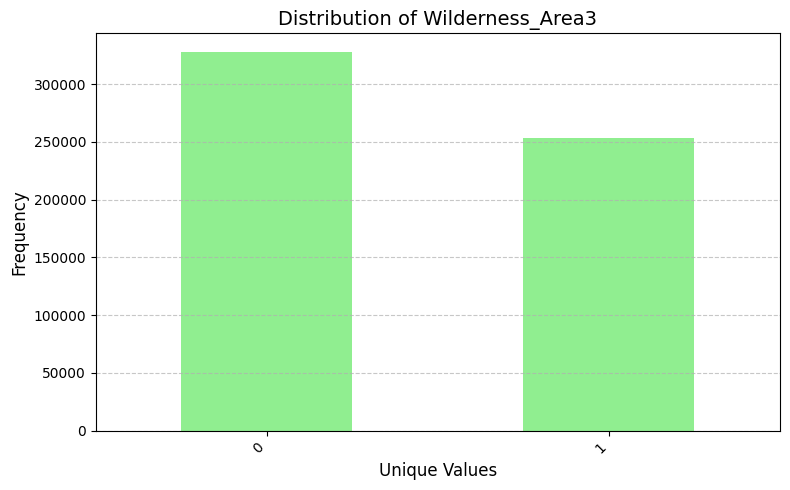

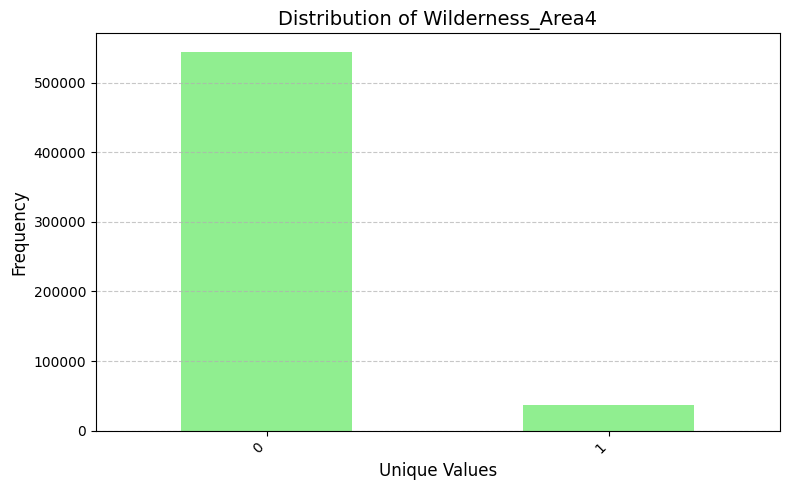

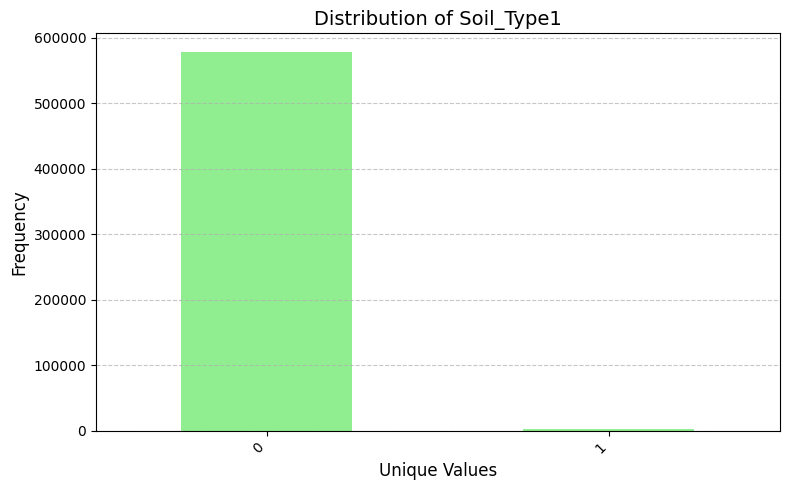

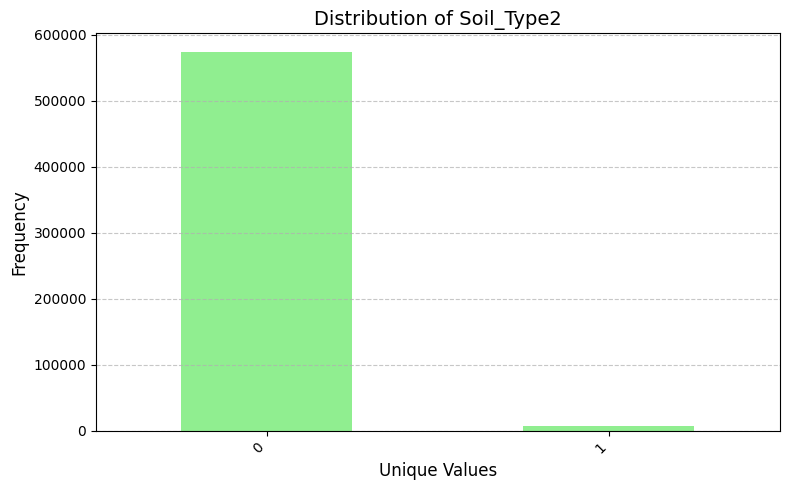

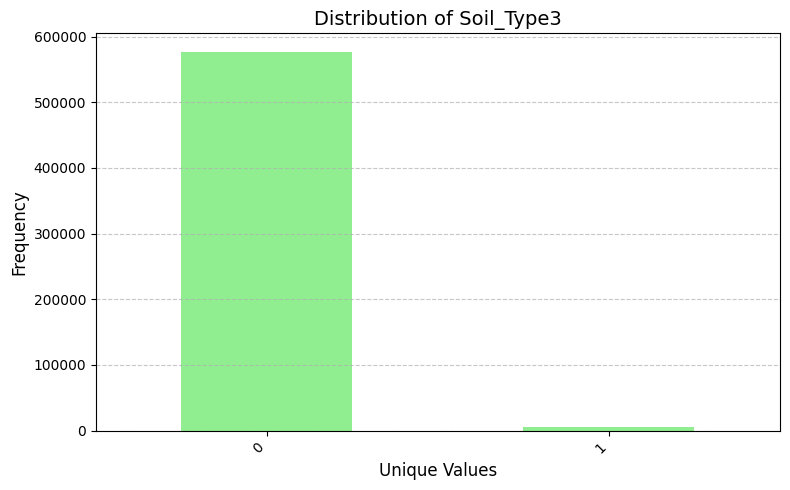

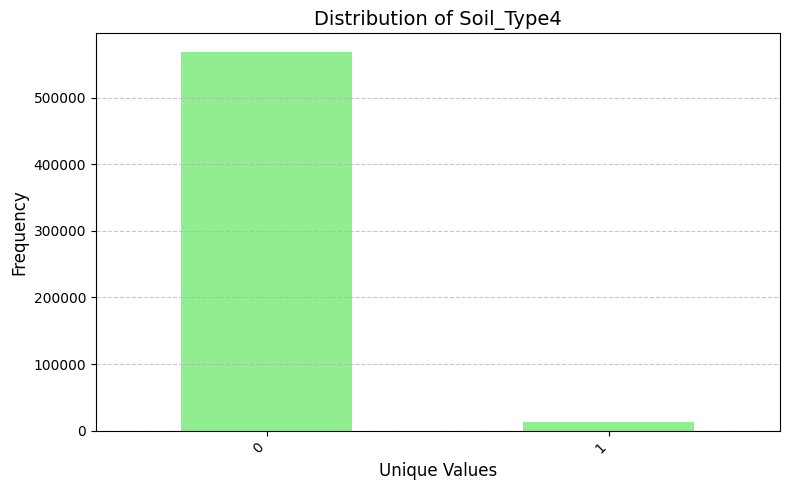

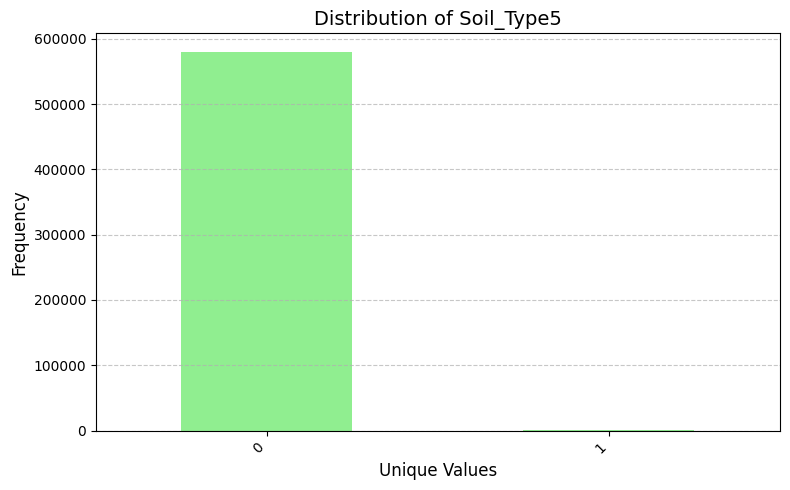

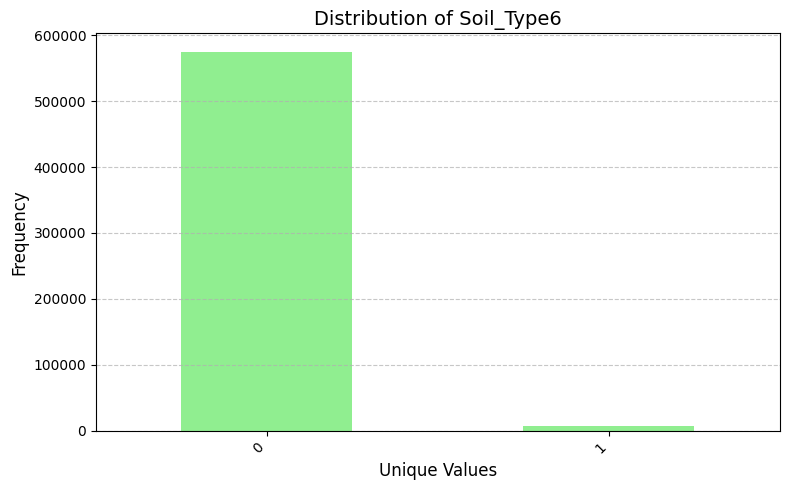

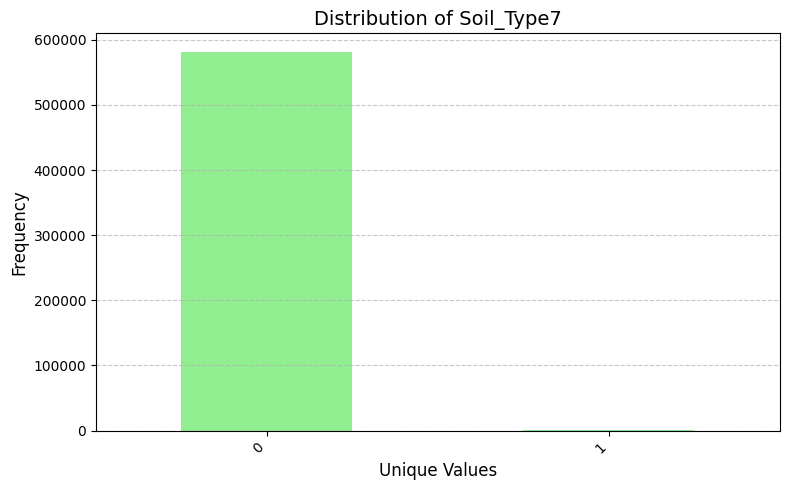

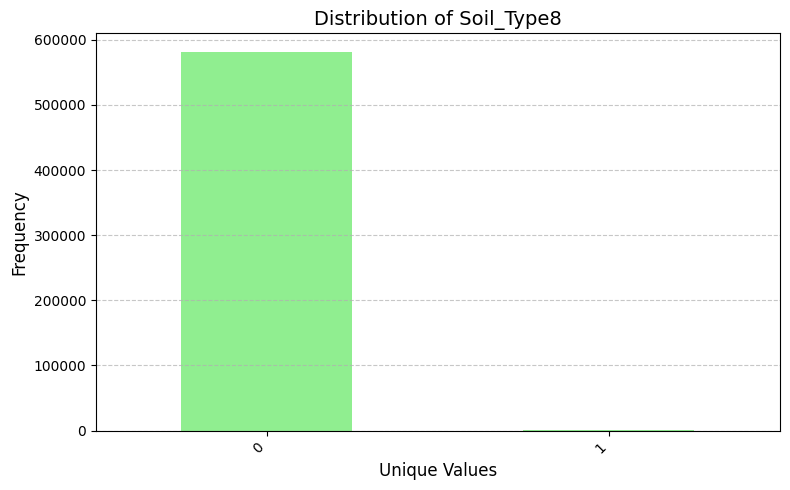

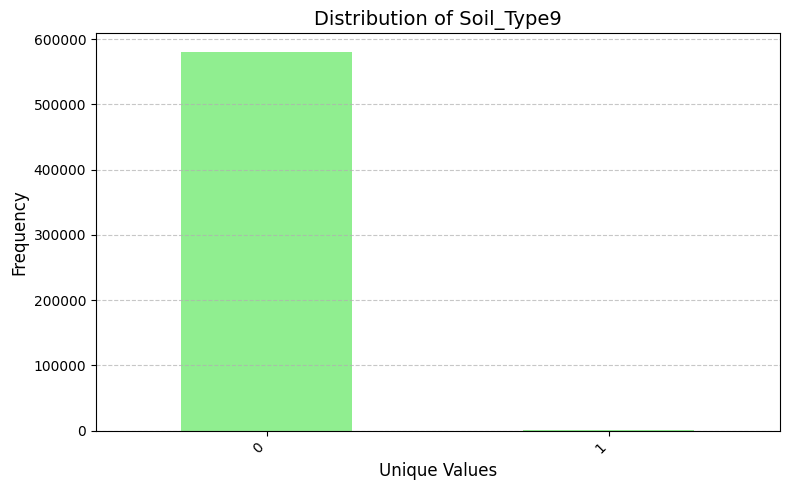

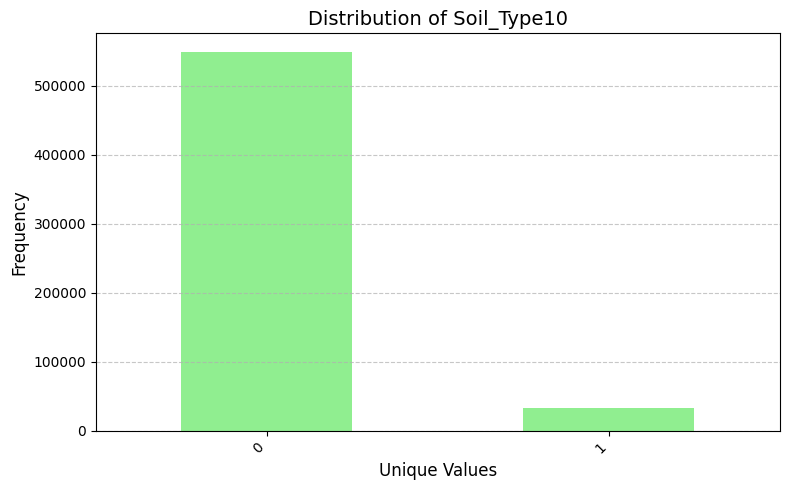

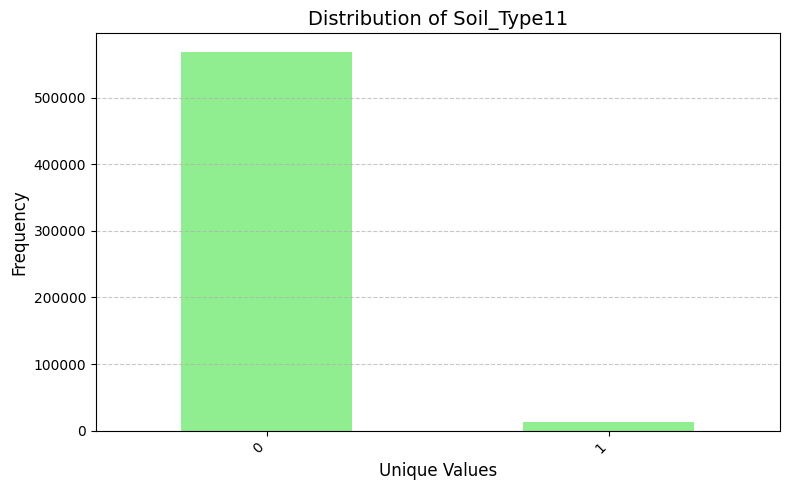

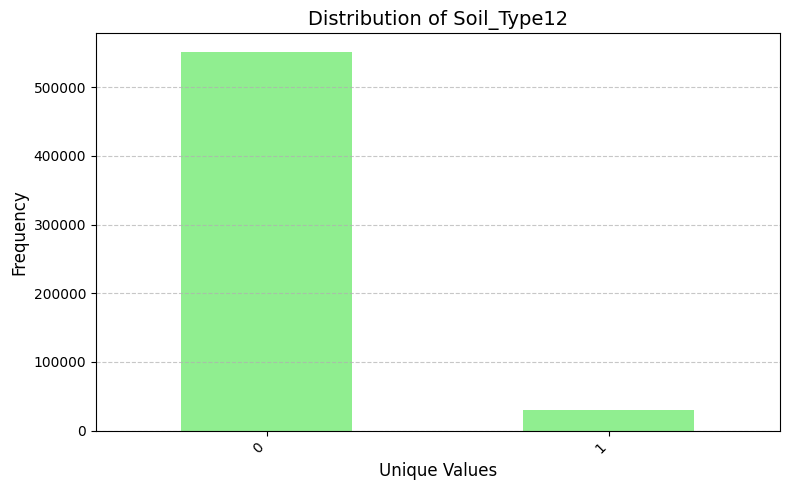

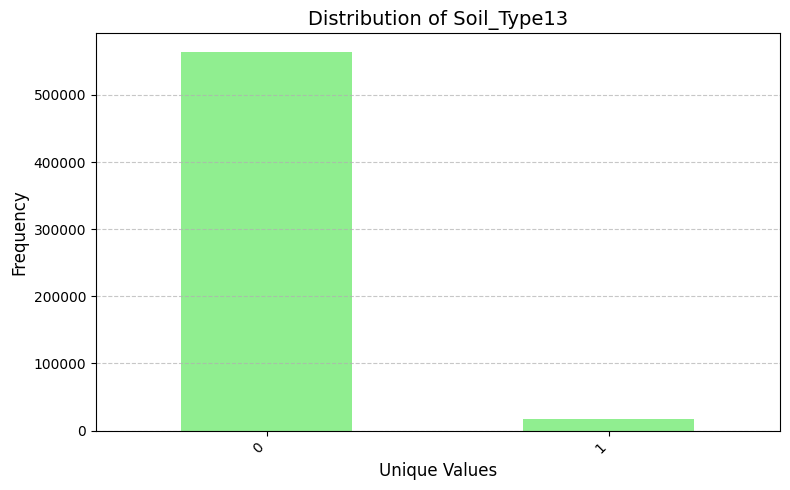

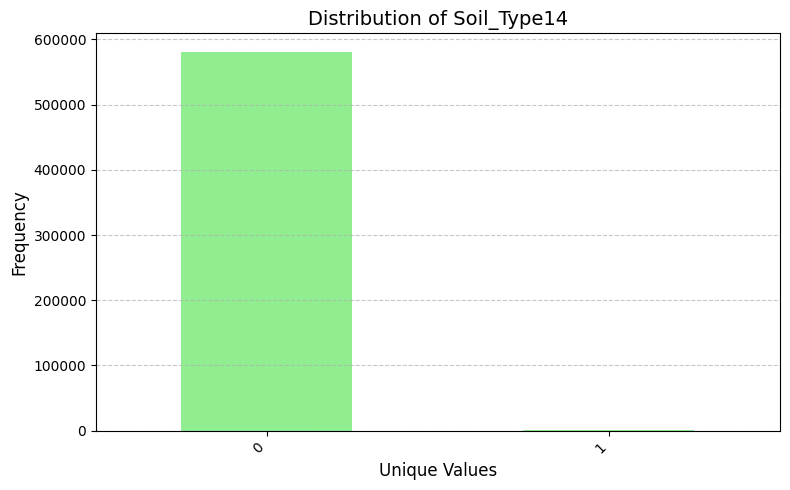

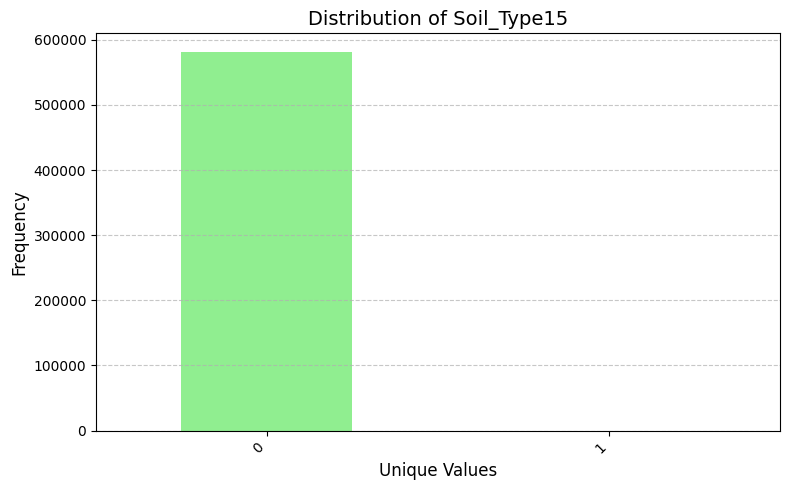

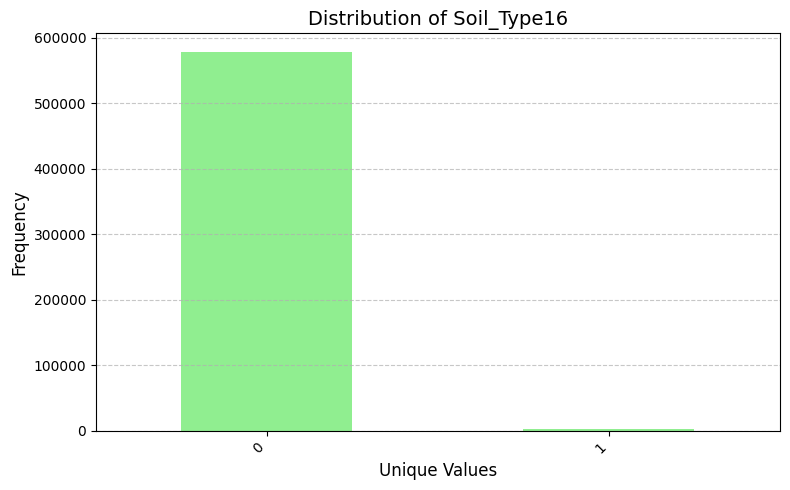

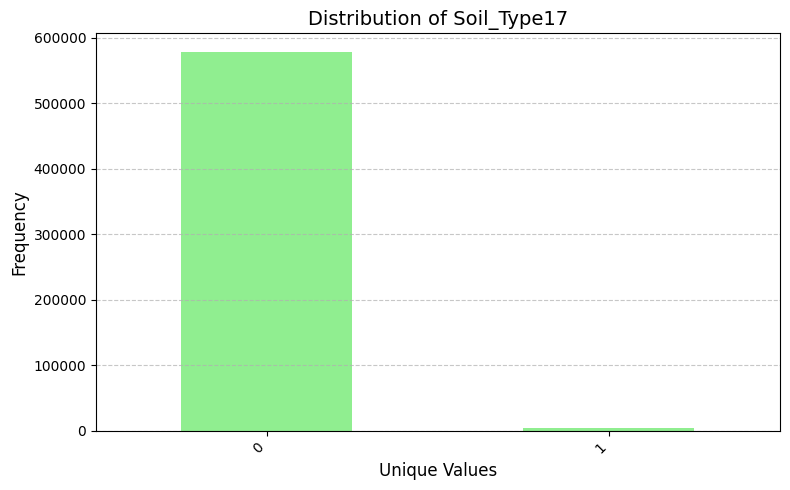

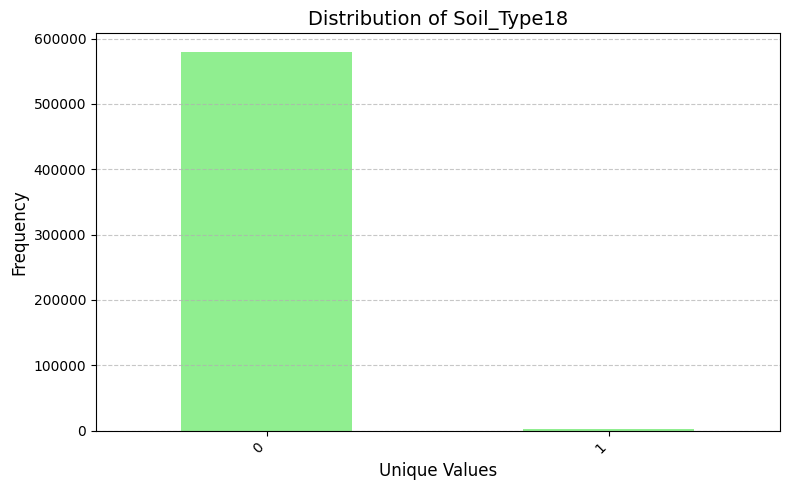

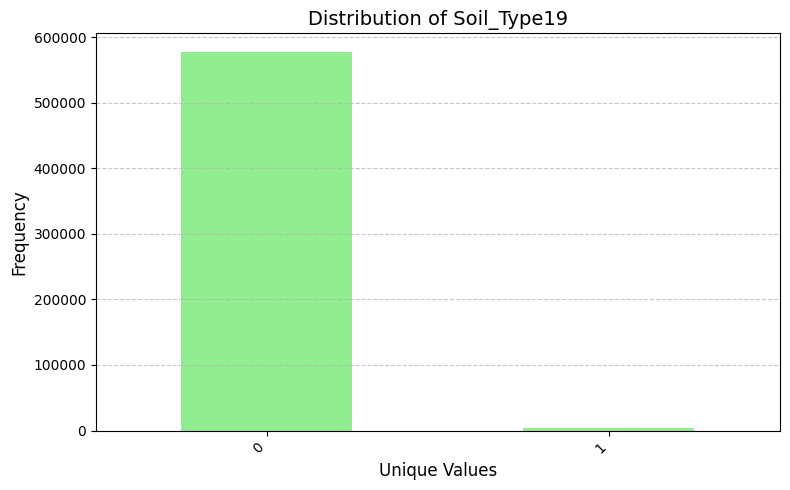

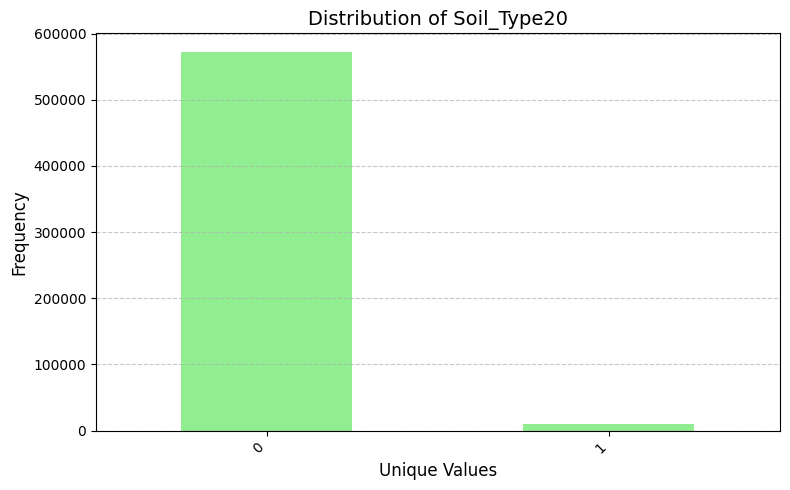

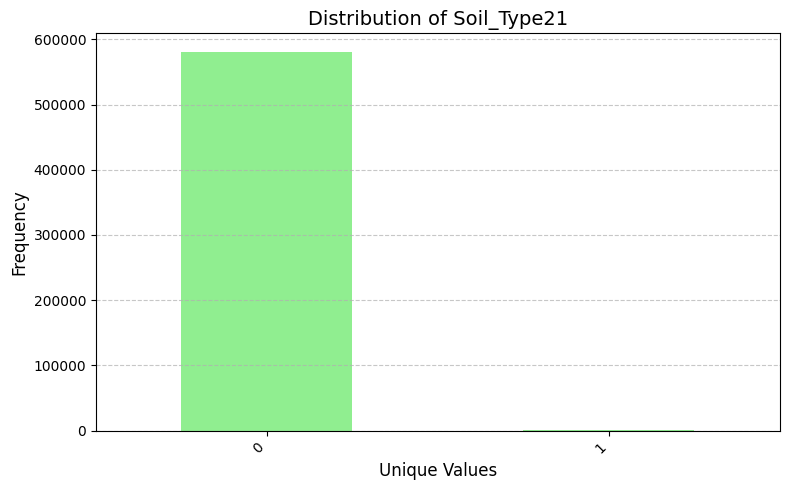

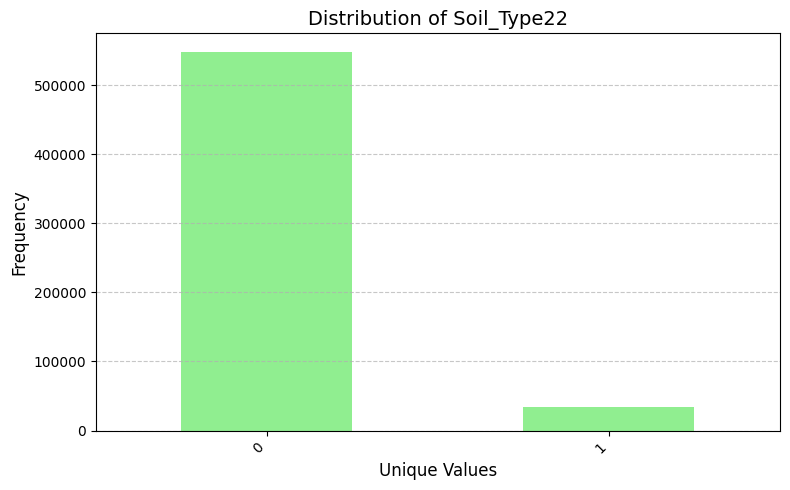

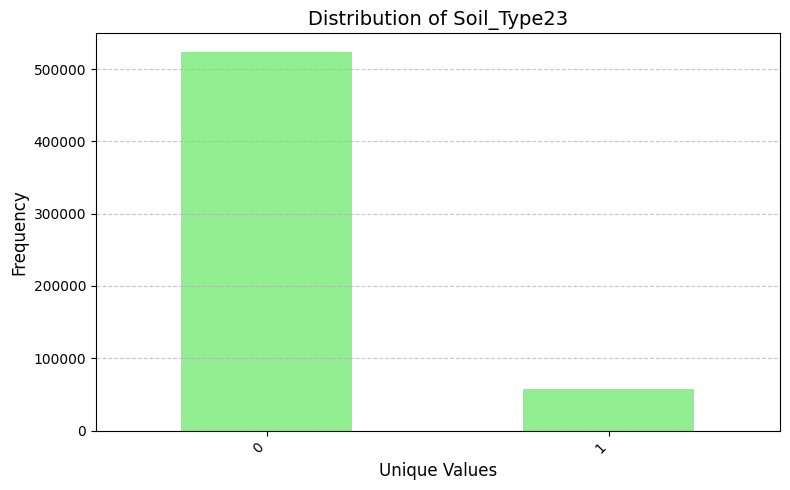

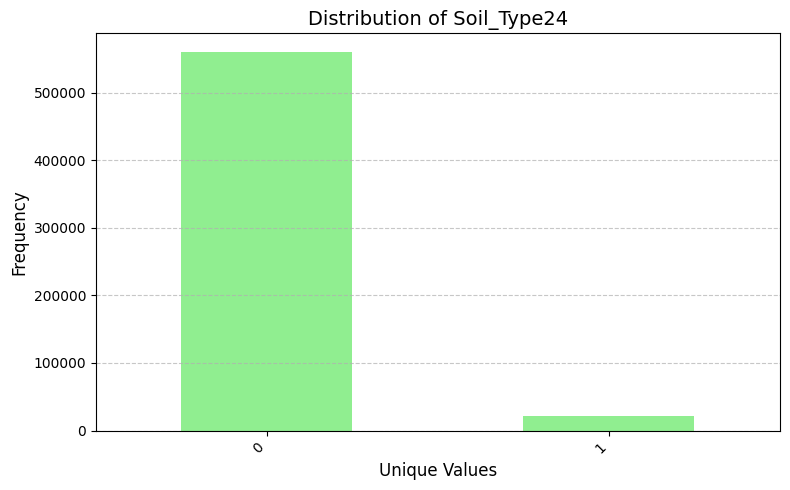

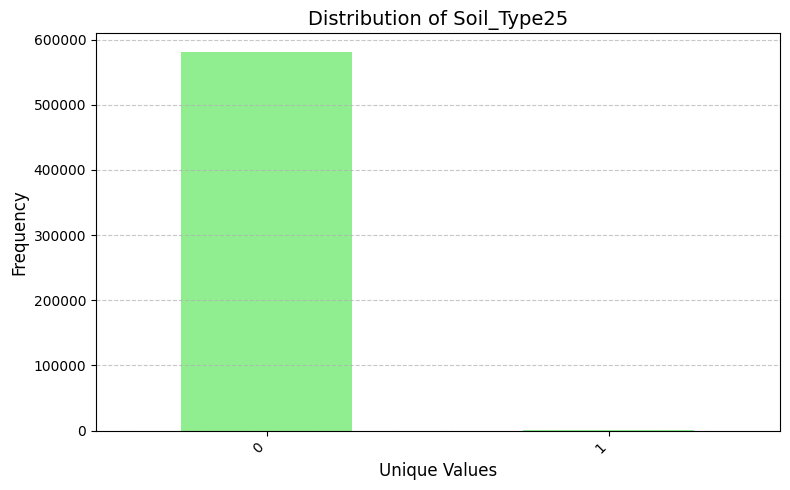

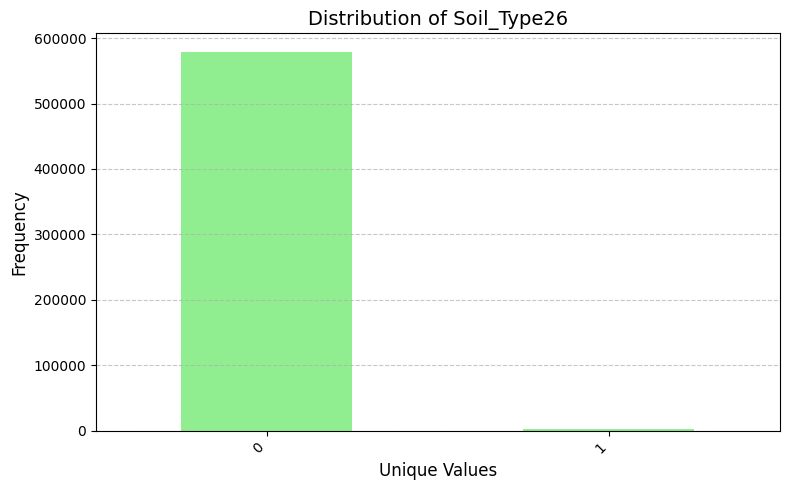

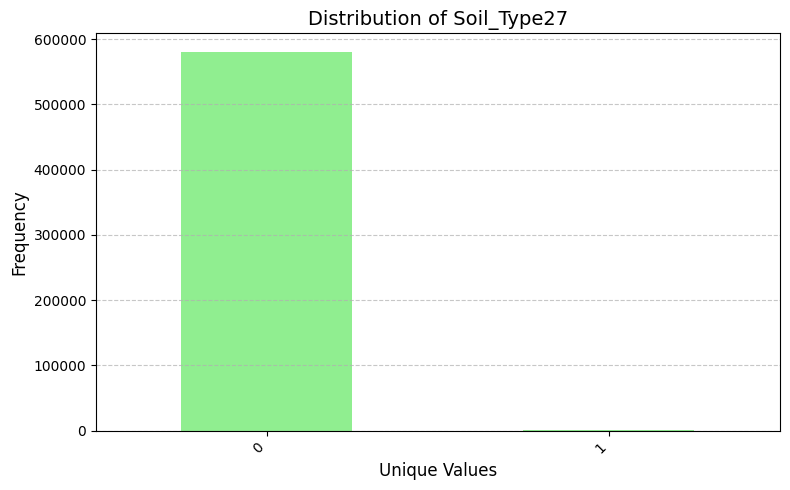

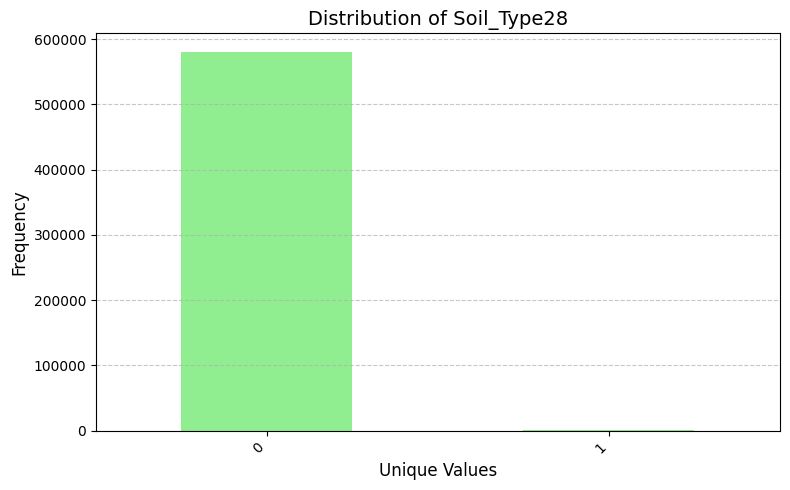

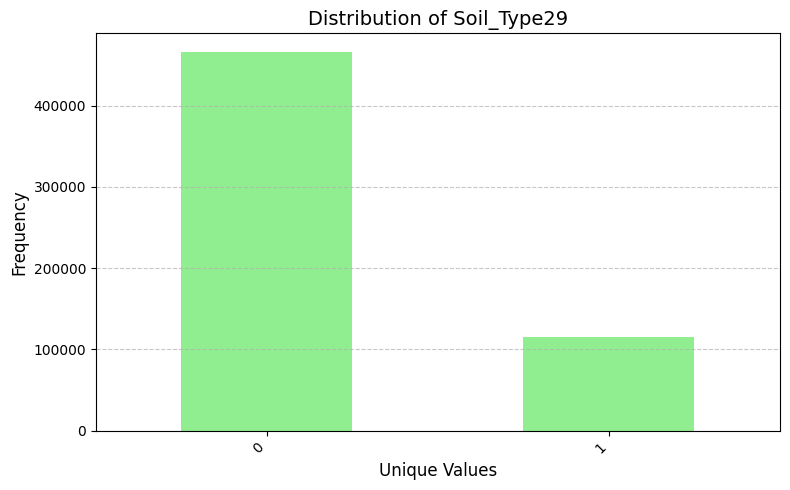

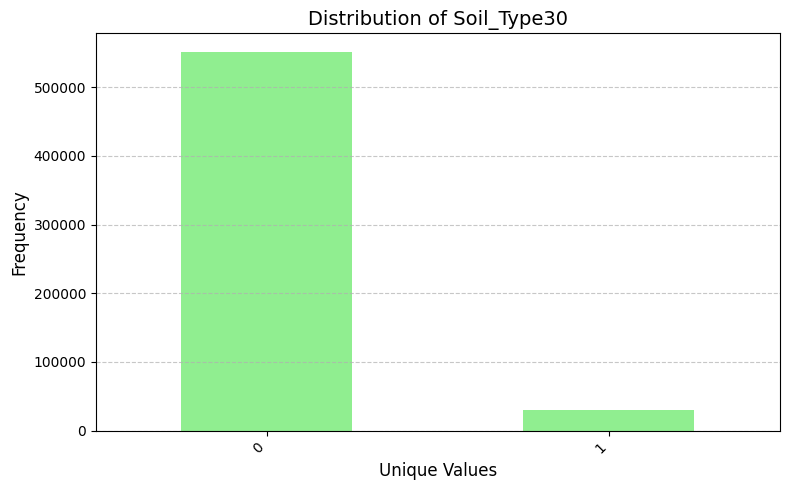

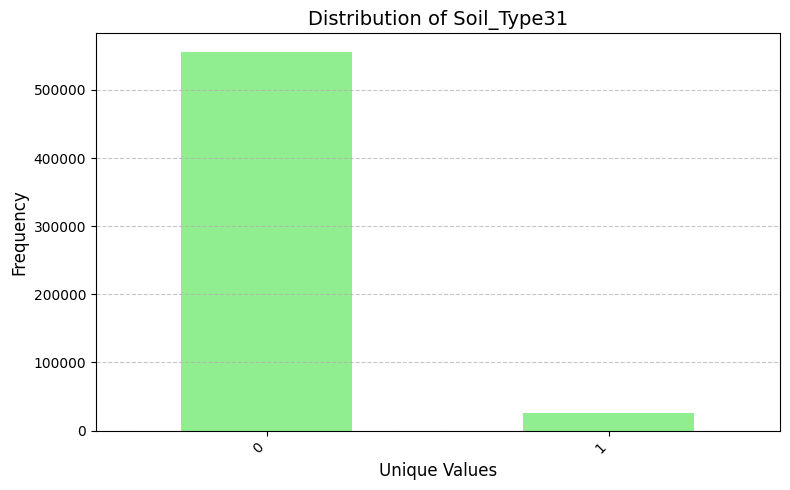

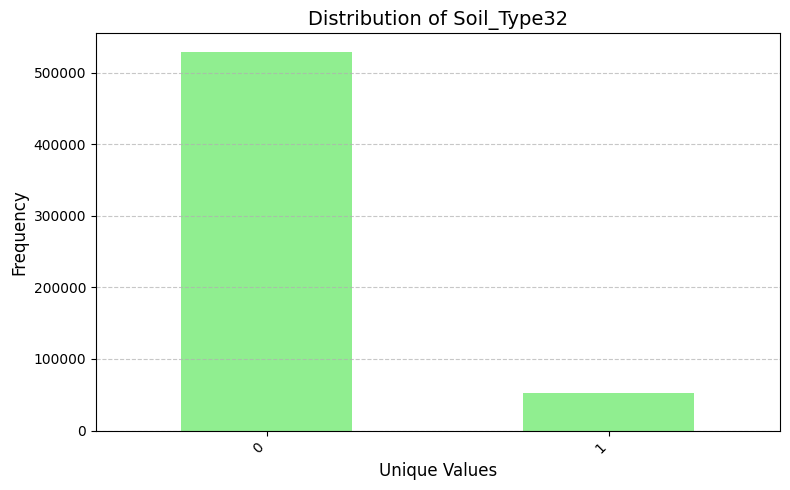

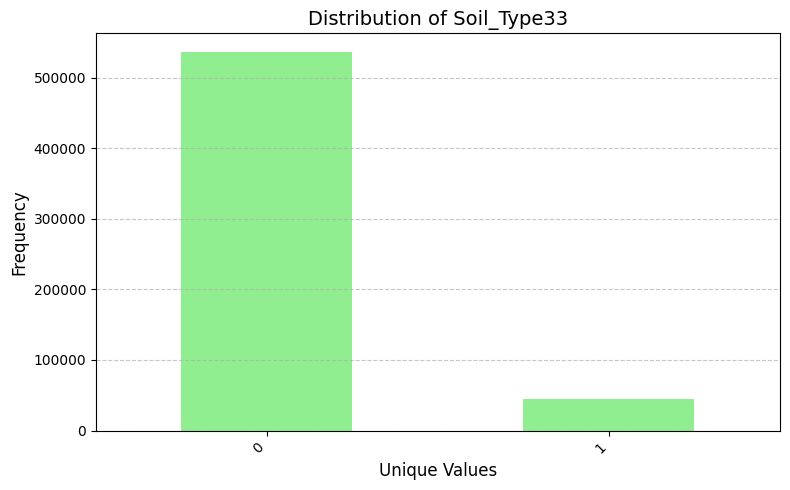

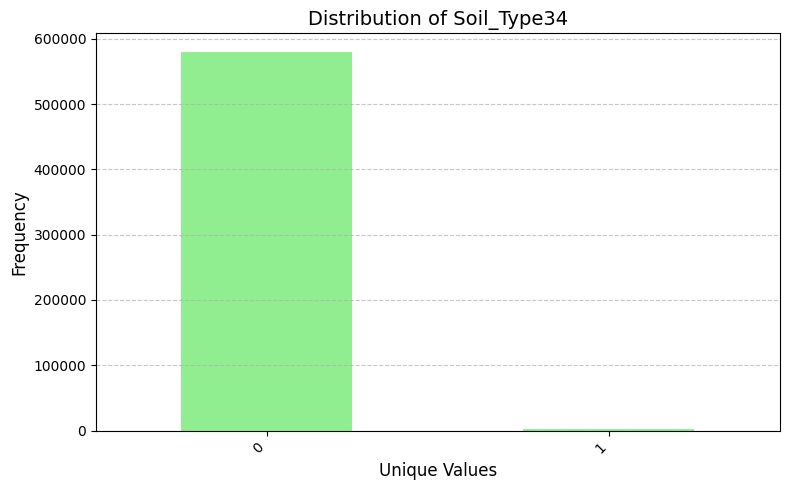

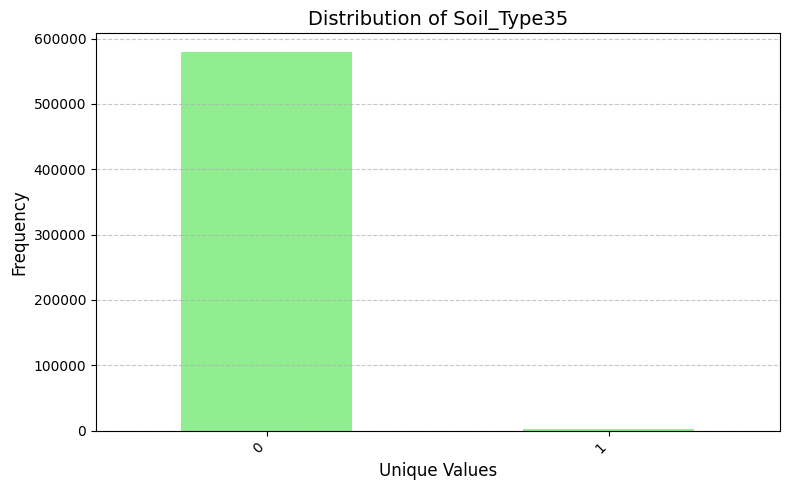

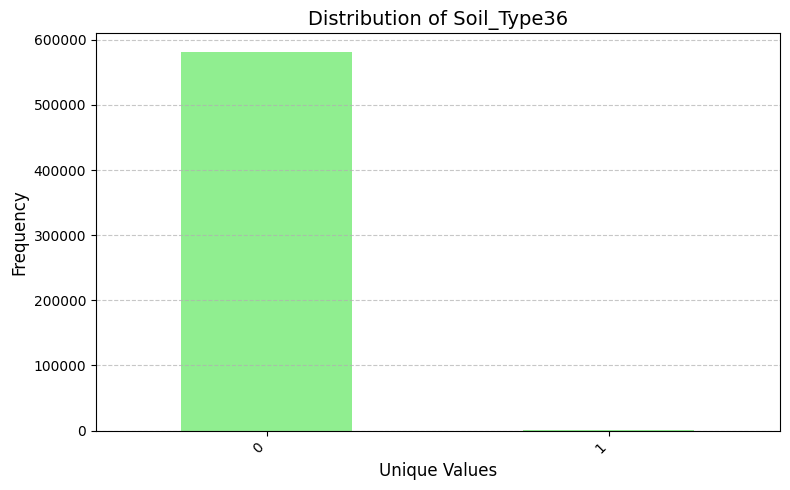

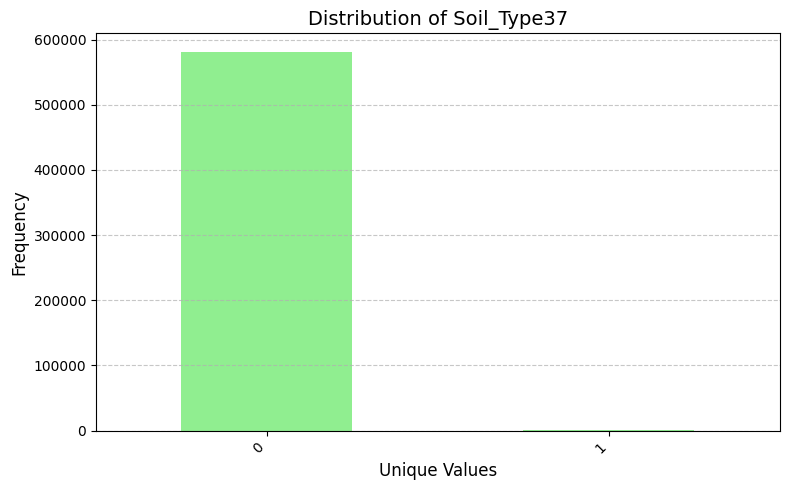

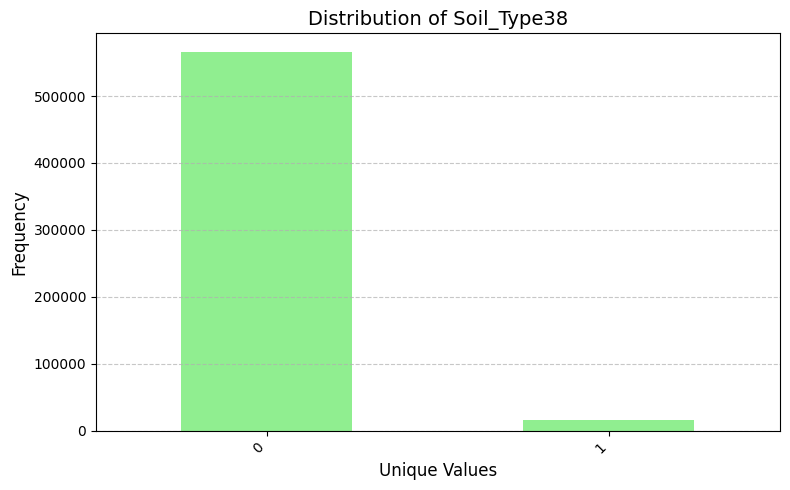

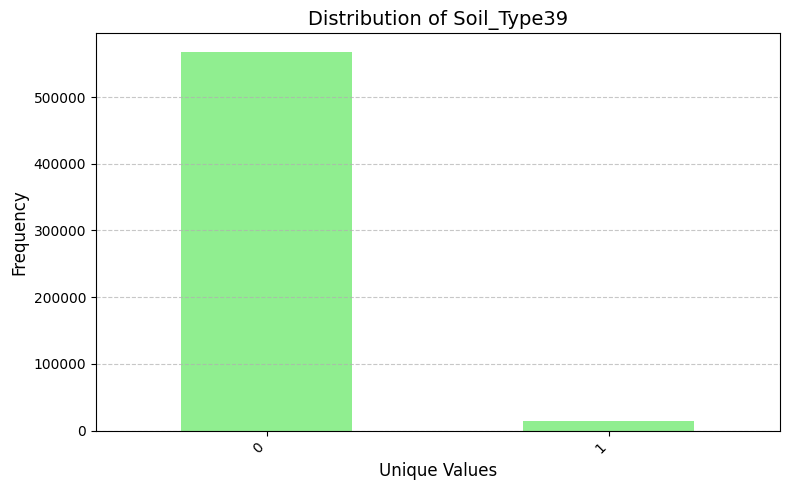

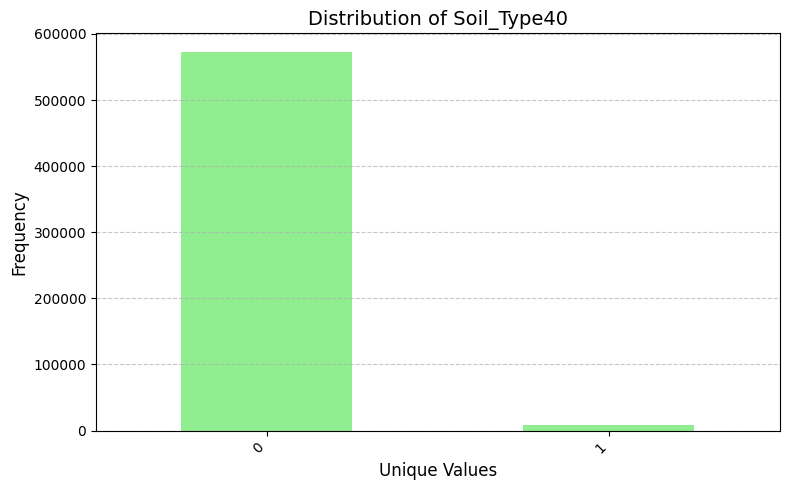

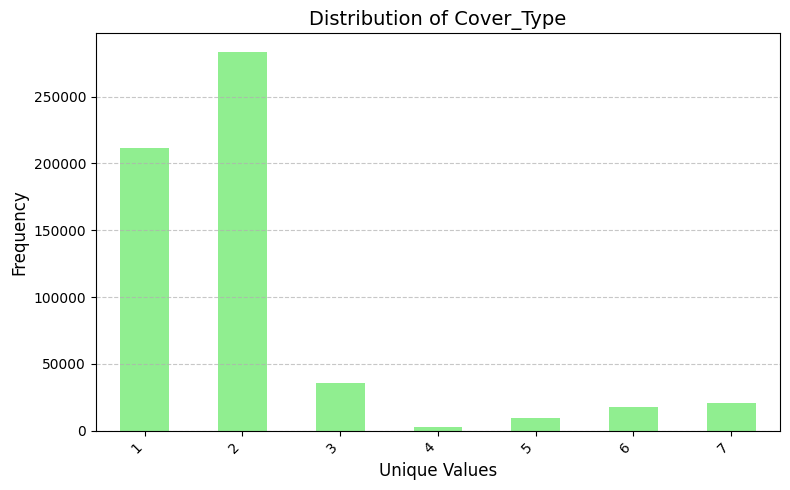

Bar plots generation complete.


In [ ]:
print("Generating bar plots for categorical/discrete features...")

# Ensure categorical_discrete_cols is defined. It was defined in a previous step.
# categorical_discrete_cols = [
#     'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
#     'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
#     'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
#     'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
#     'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
#     'Cover_Type'
# ]

for col in categorical_discrete_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        df[col].value_counts().sort_index().plot(kind='bar', color='lightgreen')
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('Unique Values', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in DataFrame. Skipping.")

print("Bar plots generation complete.")

## Correlation Analysis



Calculating correlation matrix...
Generating heatmap of the correlation matrix...


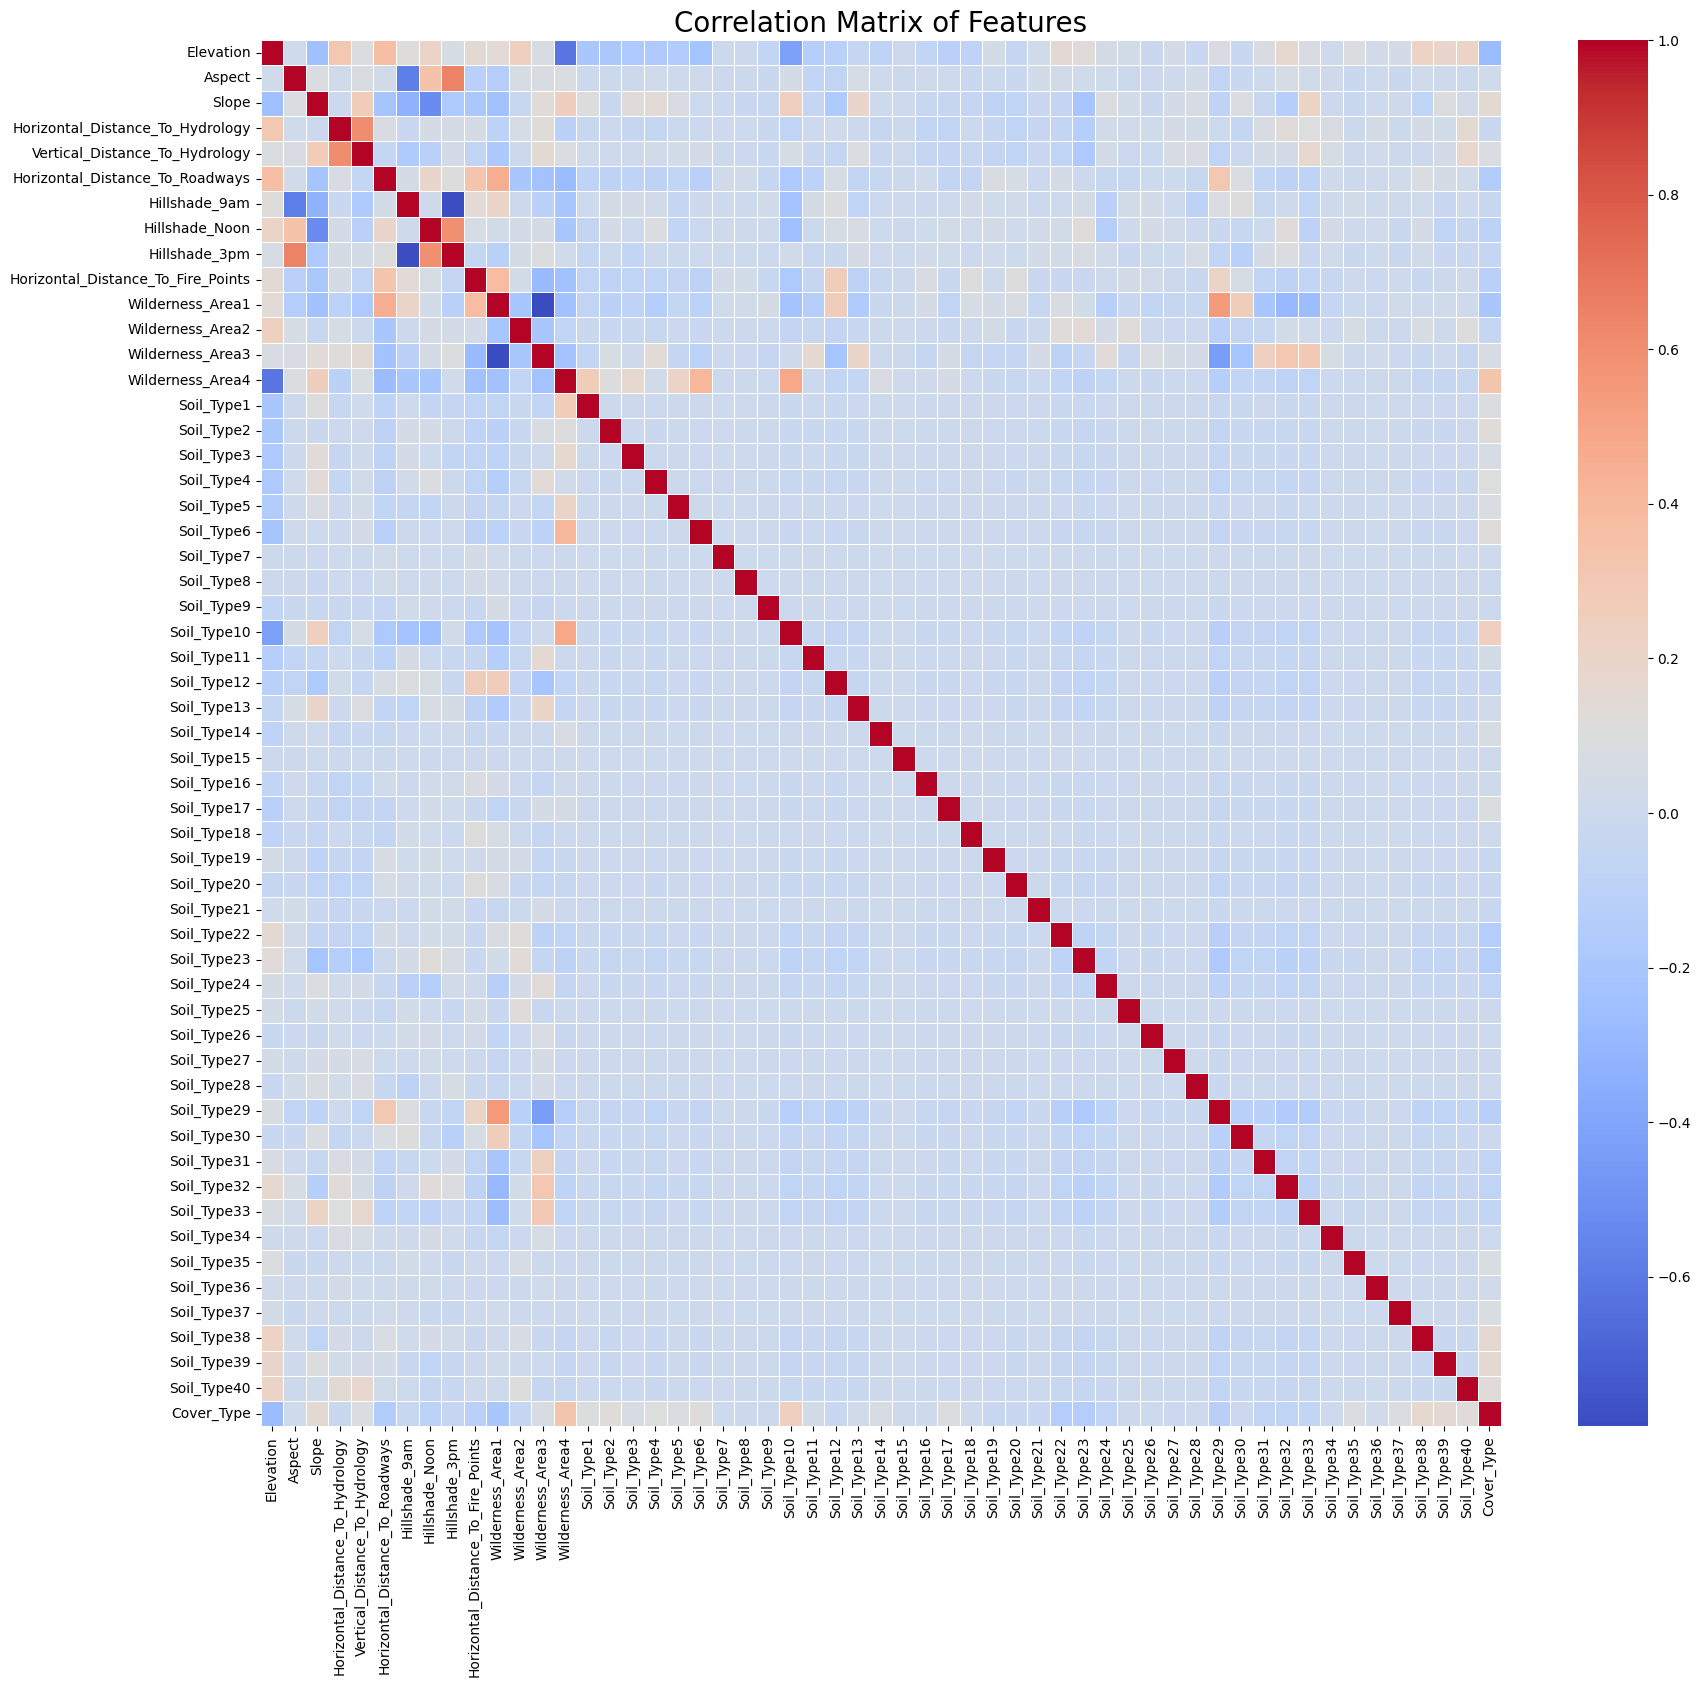

Correlation matrix and heatmap generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating correlation matrix...")

# Calculate the correlation matrix for all numerical features
# Since all columns in df are numerical (int64 as per df.info() in previous output), we can use the entire DataFrame.
correlation_matrix = df.corr()

print("Generating heatmap of the correlation matrix...")

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 18)) # Adjust figure size for readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=20)
plt.show()

print("Correlation matrix and heatmap generated.")

## Bivariate Analysis (Features vs. Target)



Generating box plots for numerical features against Cover_Type...


/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


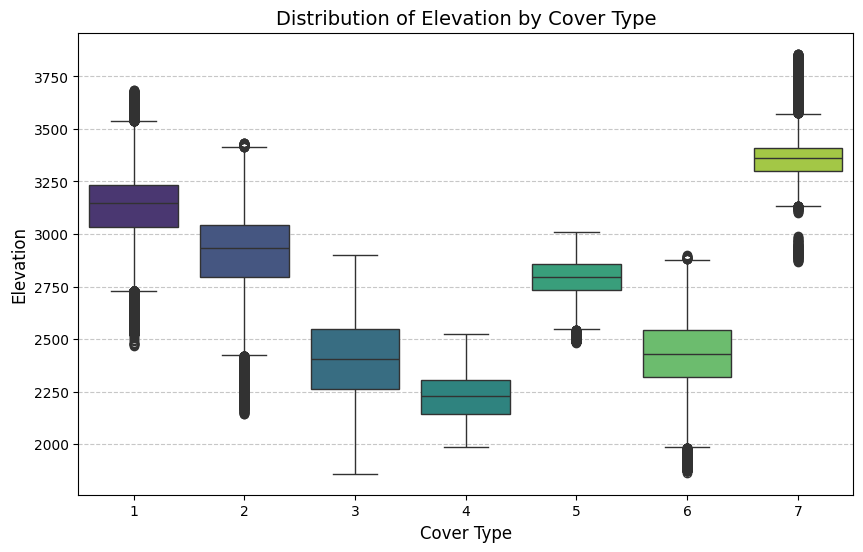

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


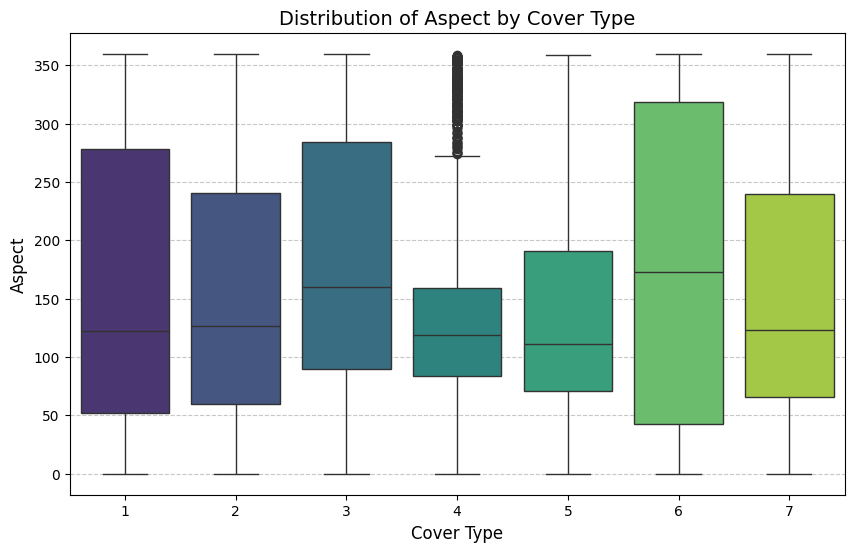

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


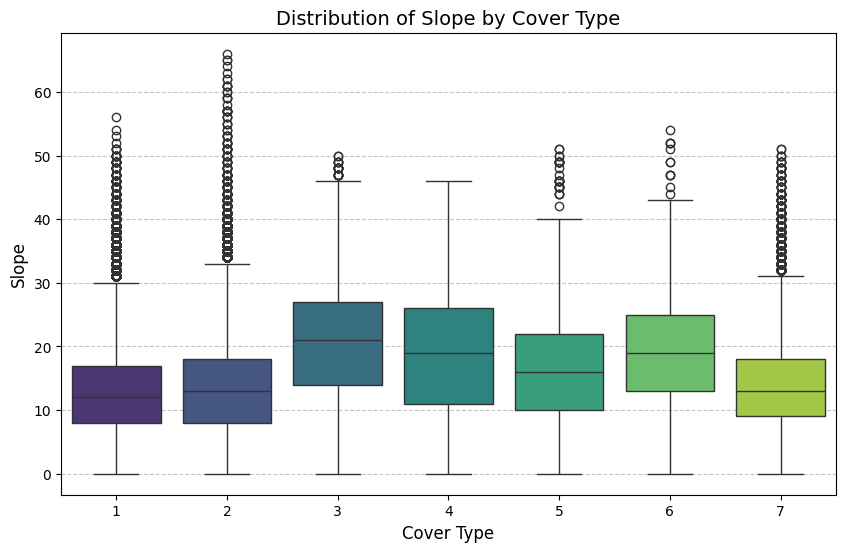

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


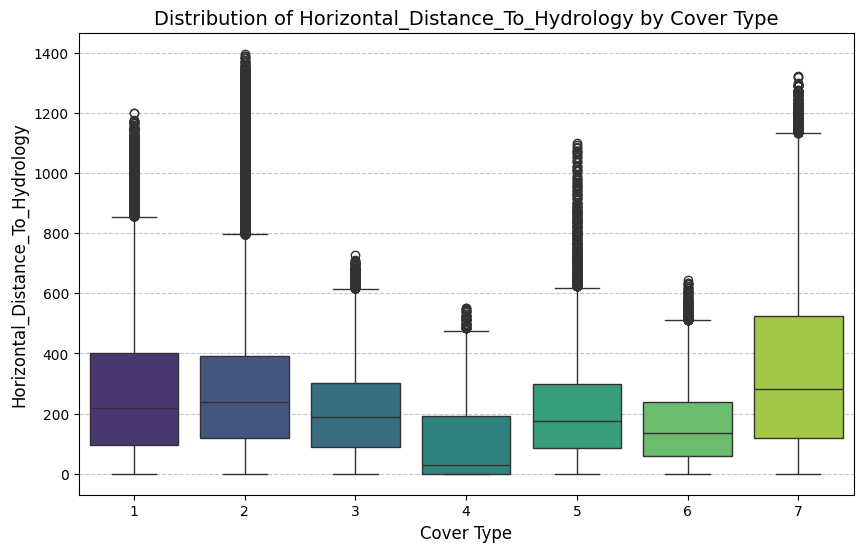

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


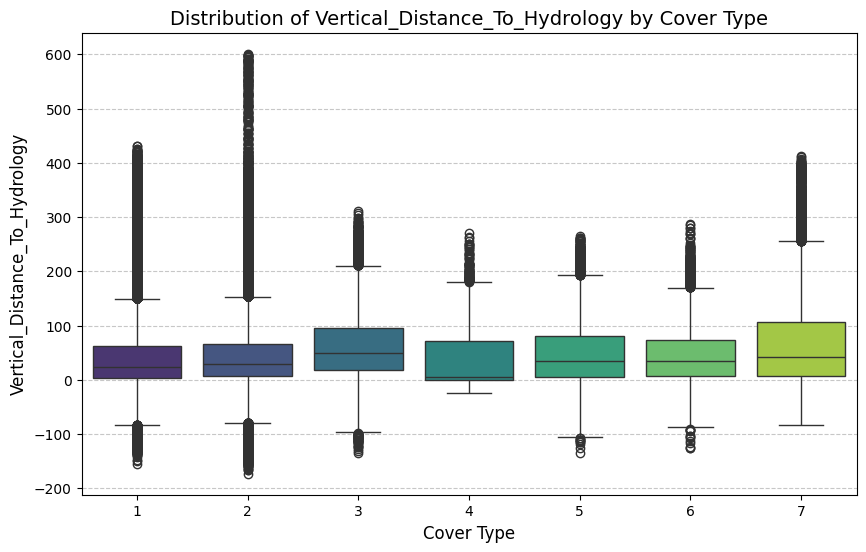

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


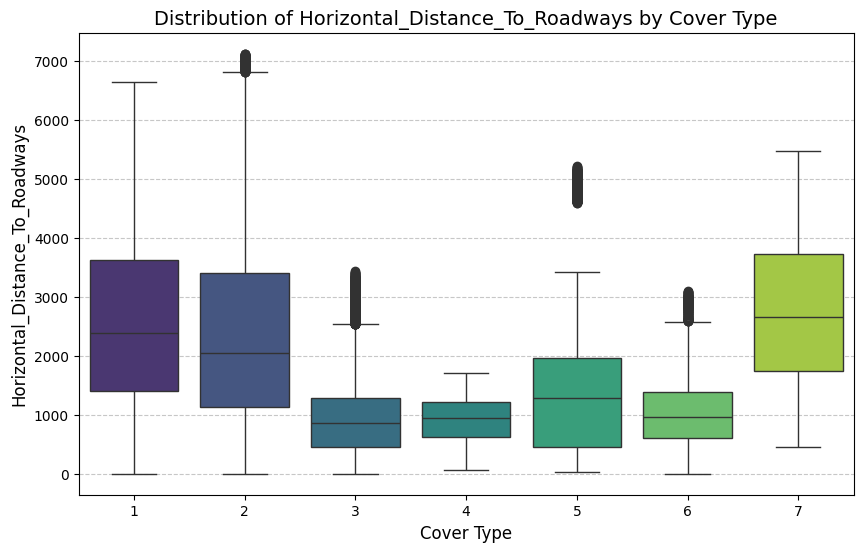

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


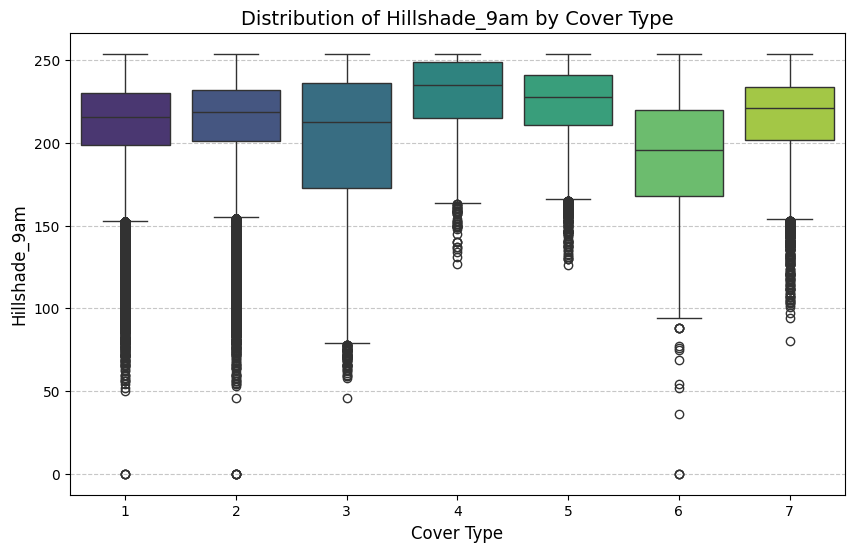

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


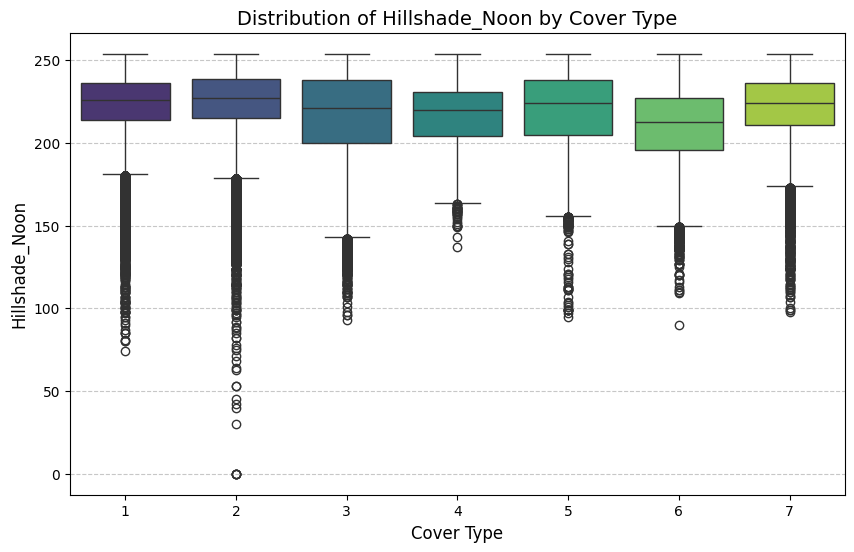

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


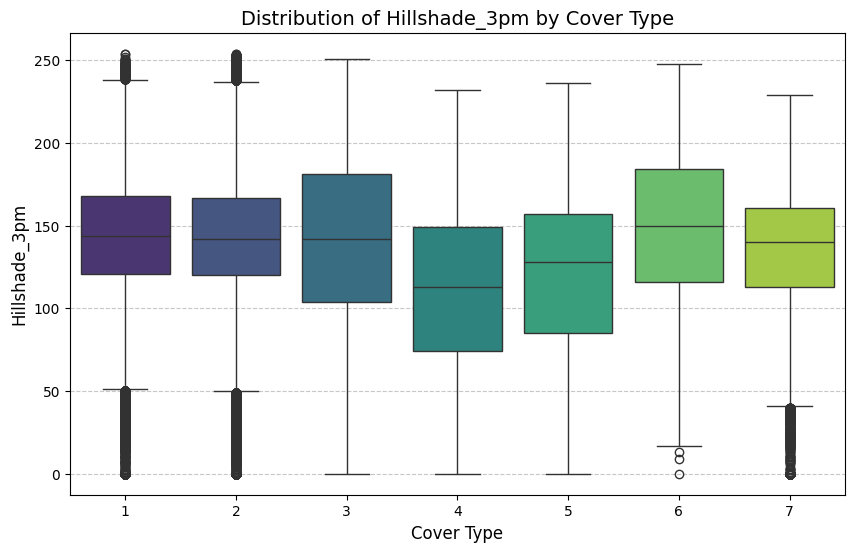

/tmp/ipython-input-3844755475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')


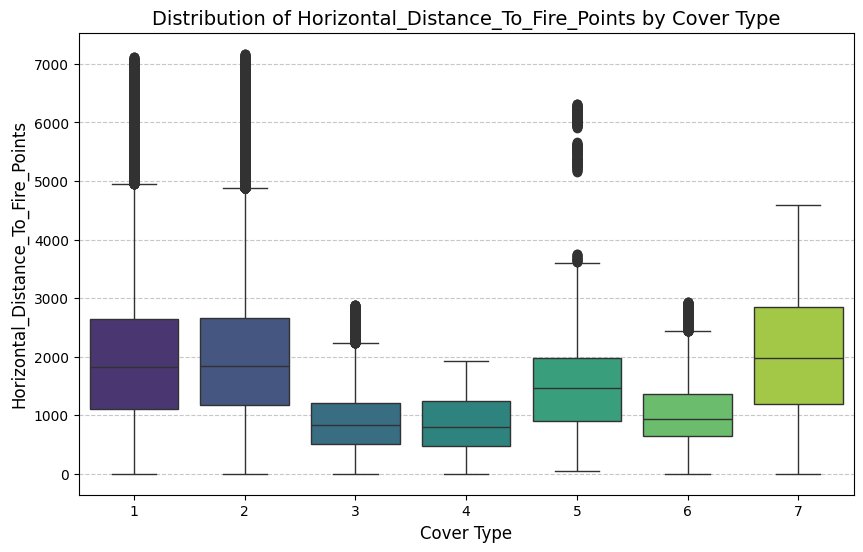

Box plots for numerical features generation complete.


In [ ]:
print("Generating box plots for numerical features against Cover_Type...")

# Ensure numerical_cols_for_analysis is defined from previous steps
# numerical_cols_for_analysis = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

for col in numerical_cols_for_analysis:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col} by Cover Type', fontsize=14)
    plt.xlabel('Cover Type', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("Box plots for numerical features generation complete.")

Generating box plots for numerical features against Cover_Type...


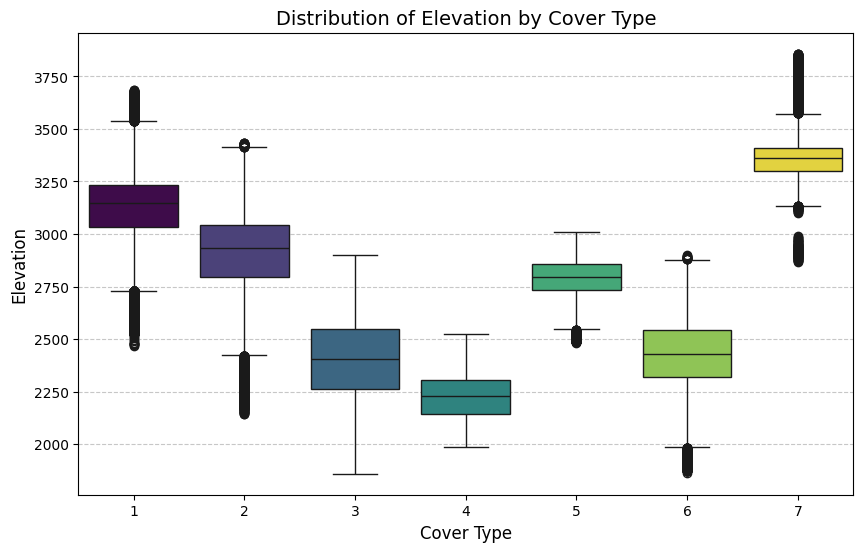

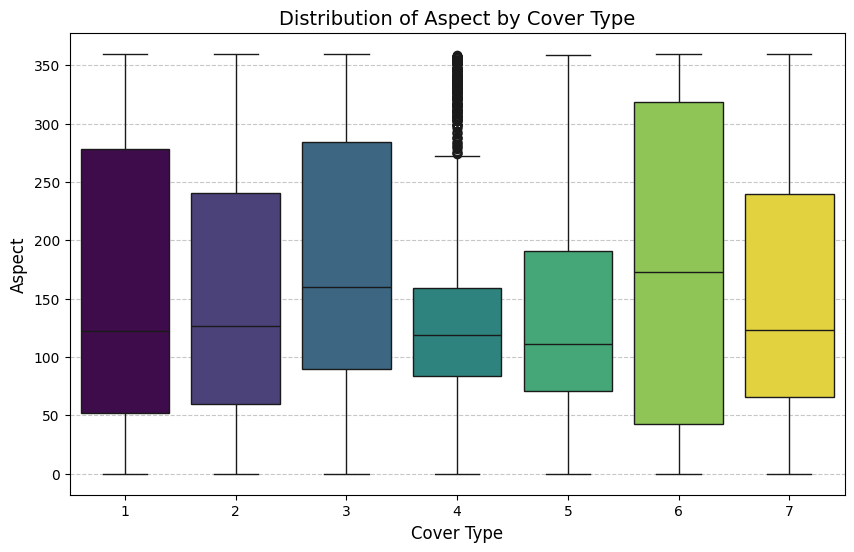

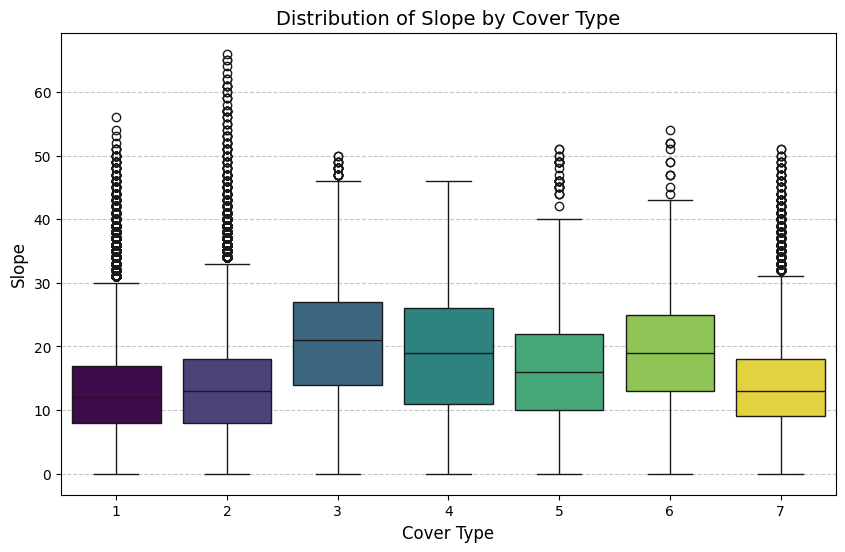

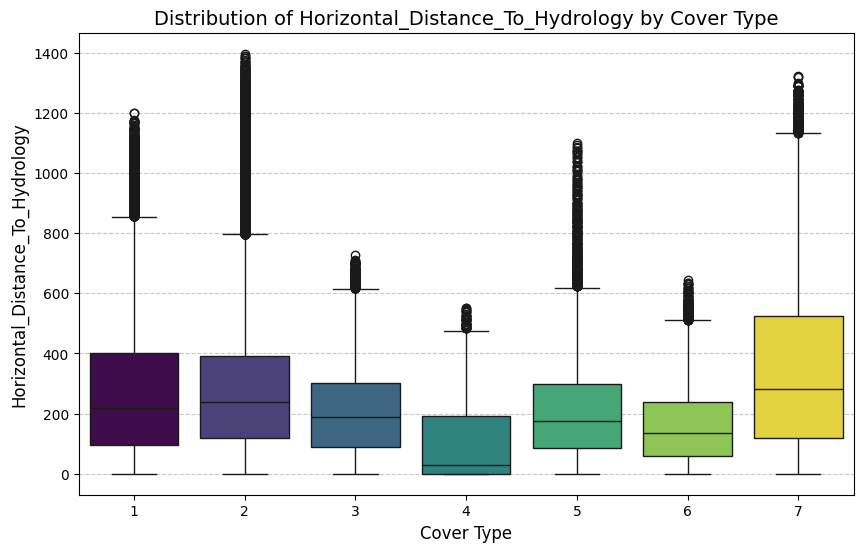

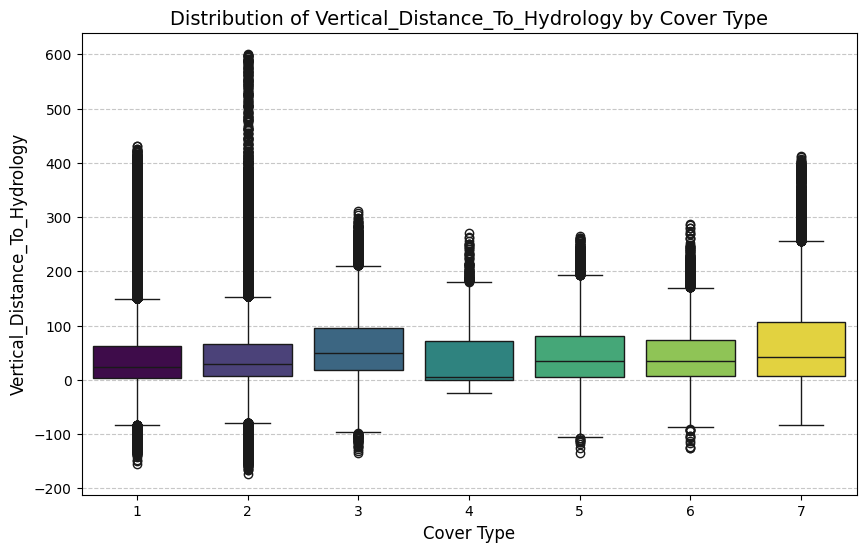

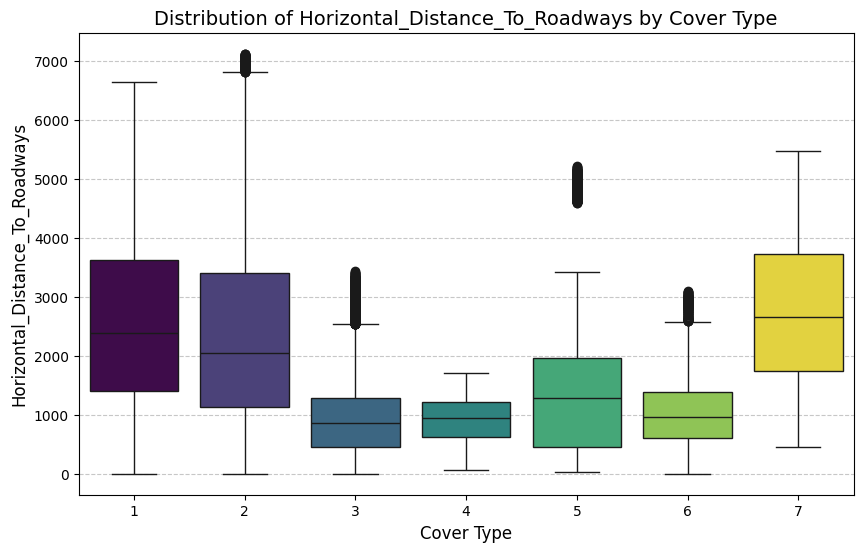

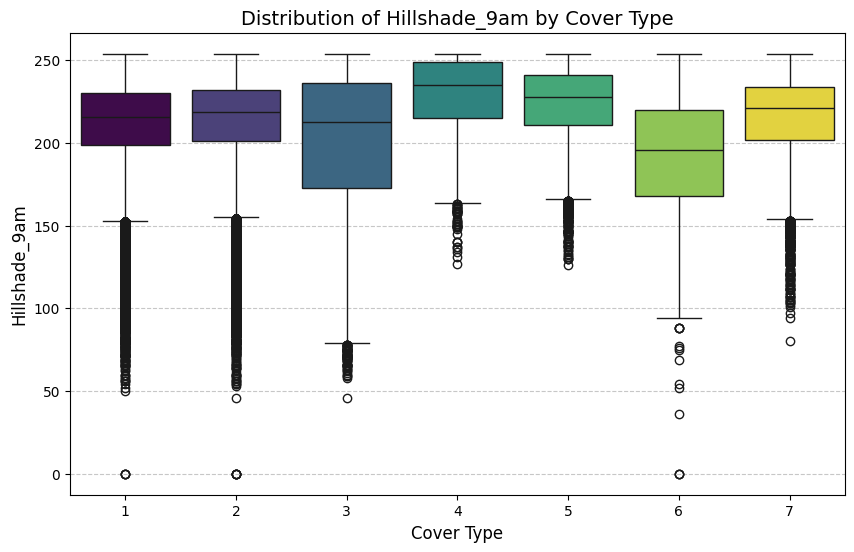

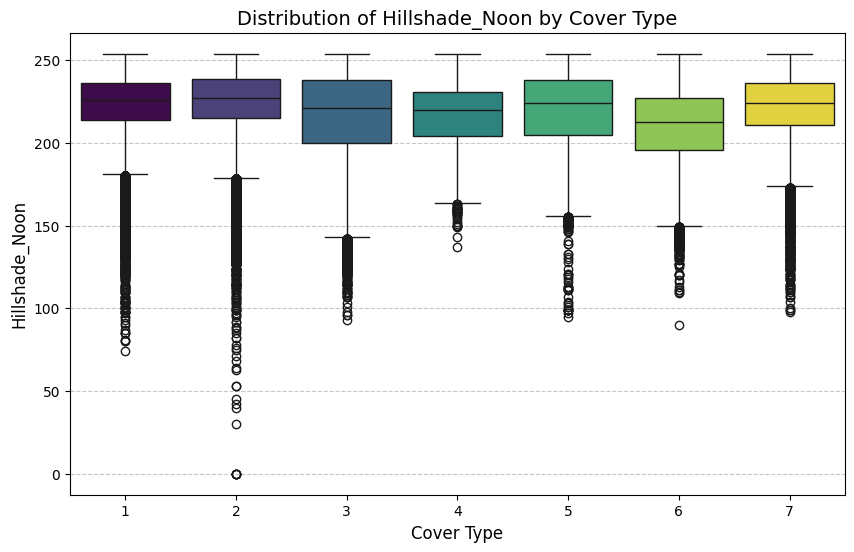

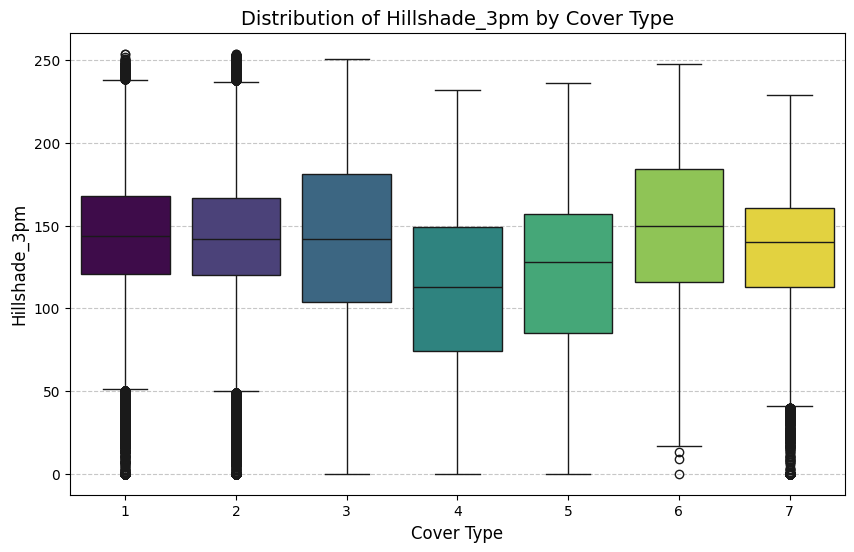

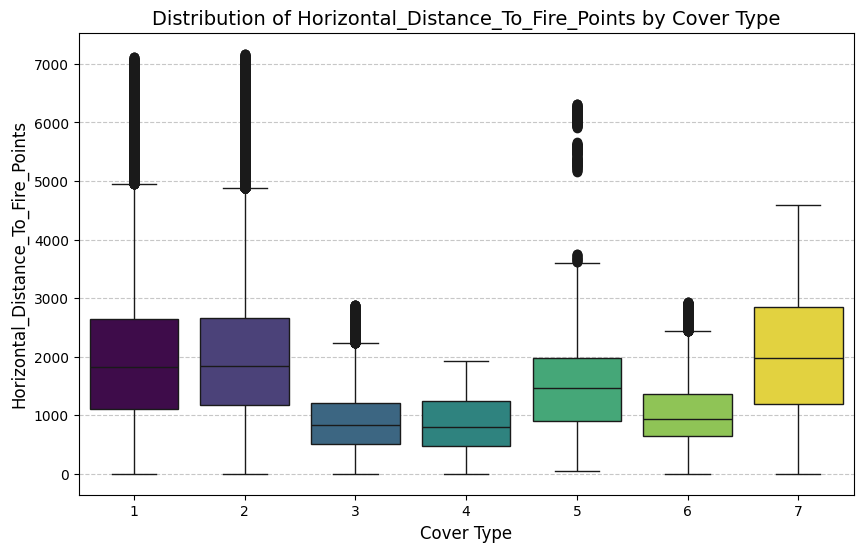

Box plots for numerical features generation complete.


In [ ]:
print("Generating box plots for numerical features against Cover_Type...")
for col in numerical_cols_for_analysis:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cover_Type', y=col, data=df, palette='viridis', hue='Cover_Type', legend=False)
    plt.title(f'Distribution of {col} by Cover Type', fontsize=14)
    plt.xlabel('Cover Type', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("Box plots for numerical features generation complete.")

Generating count plots for categorical/discrete features against Cover_Type...


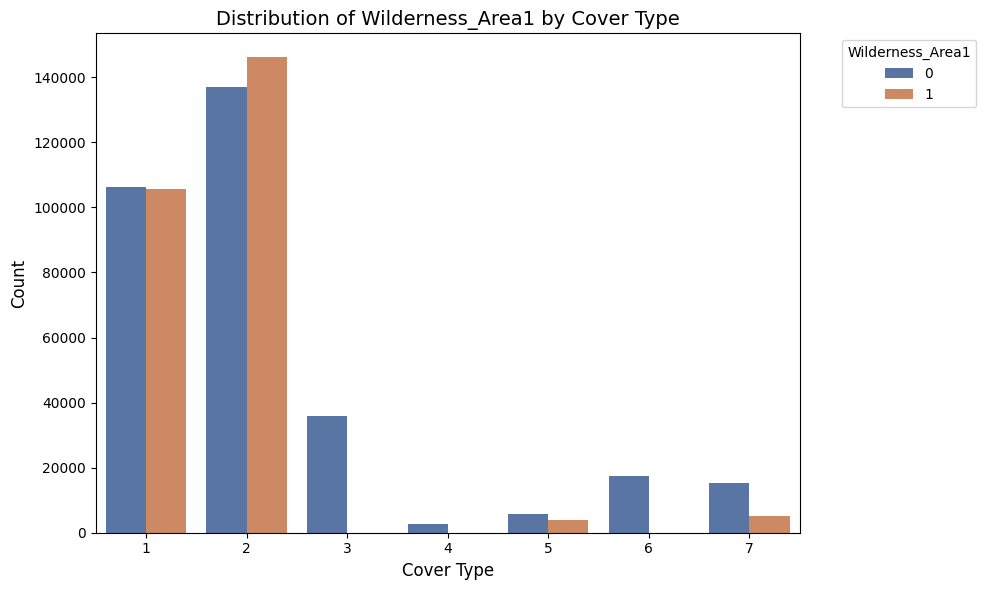

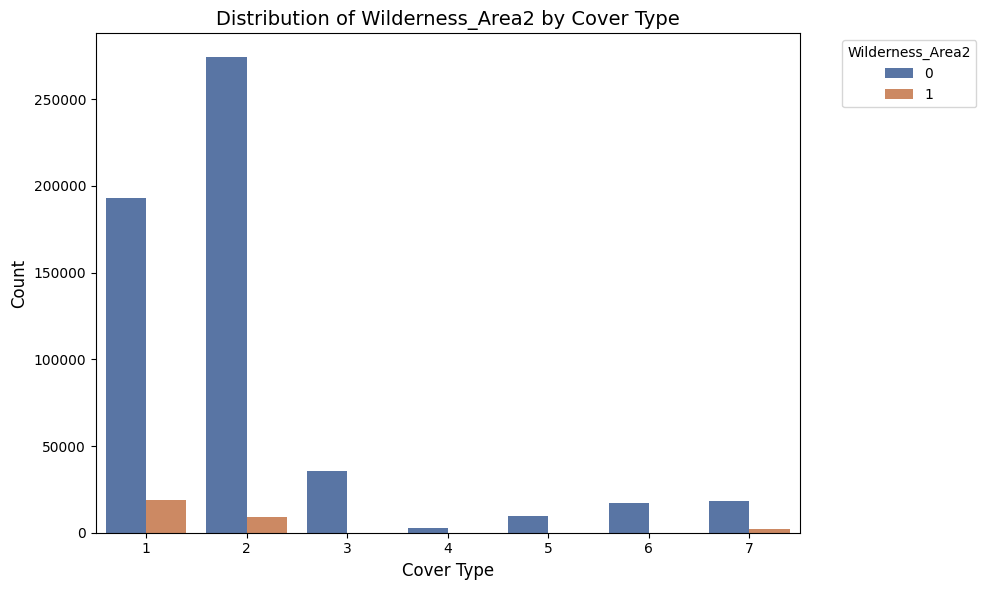

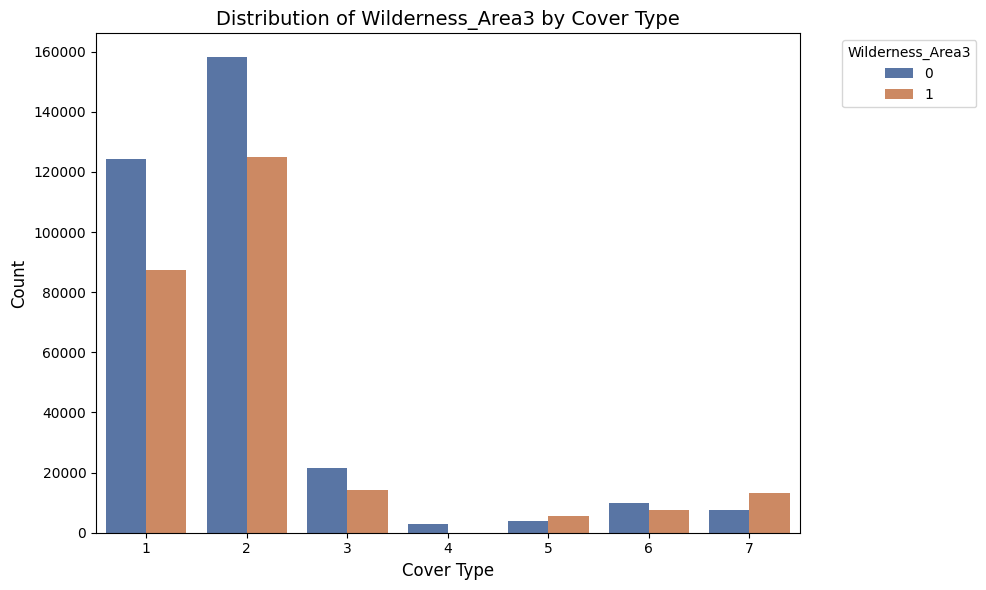

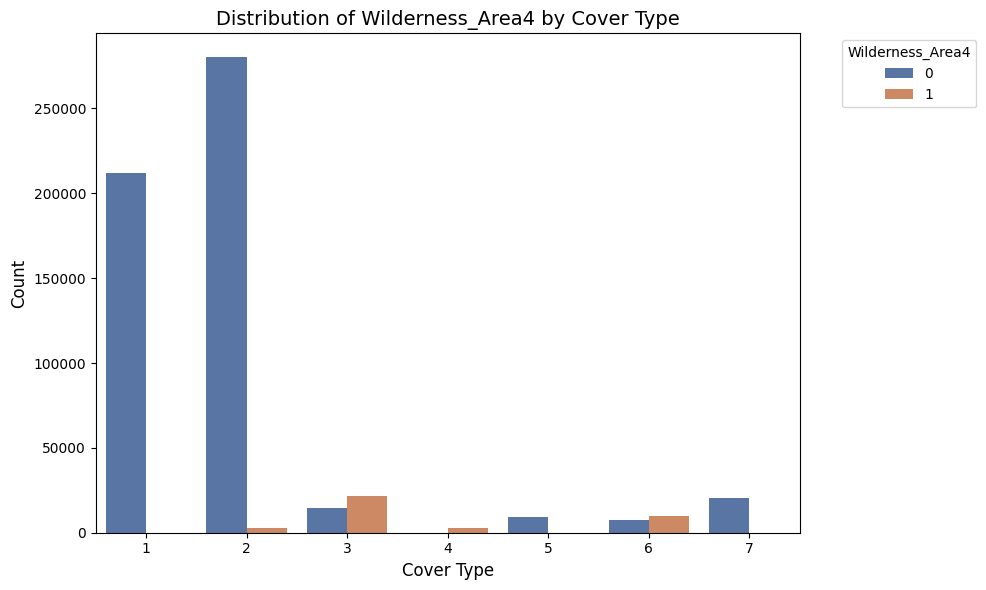

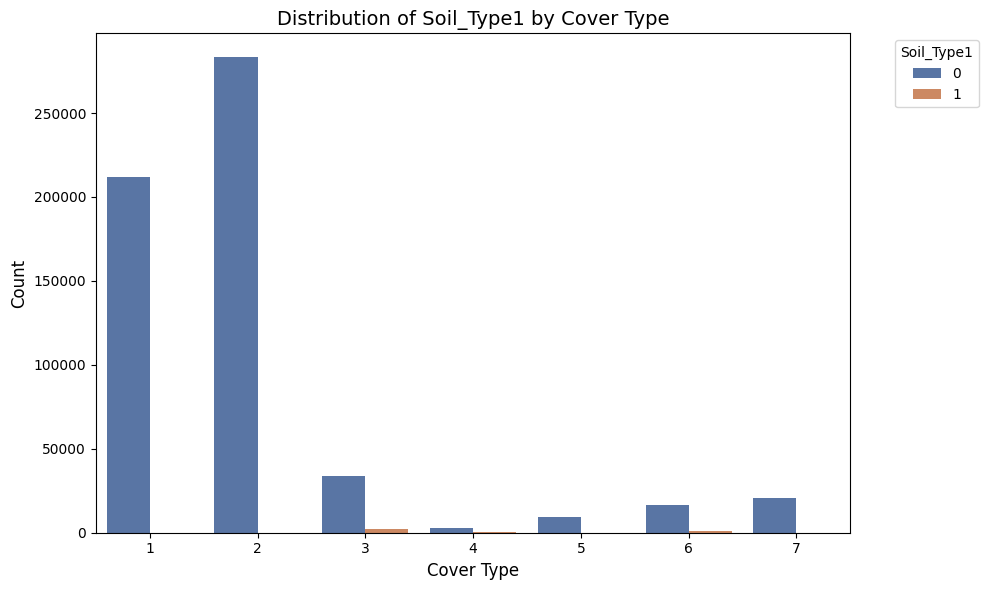

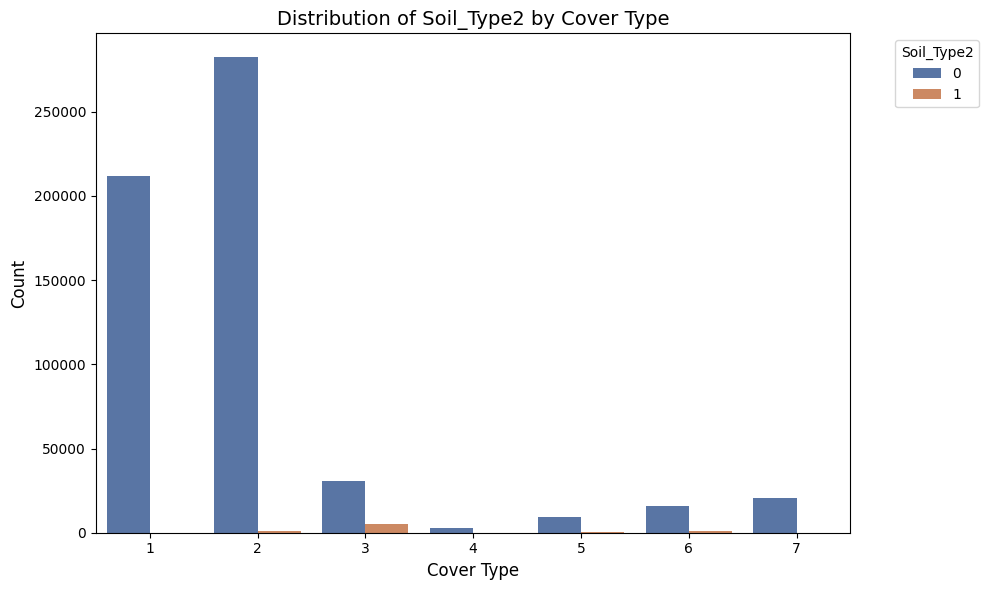

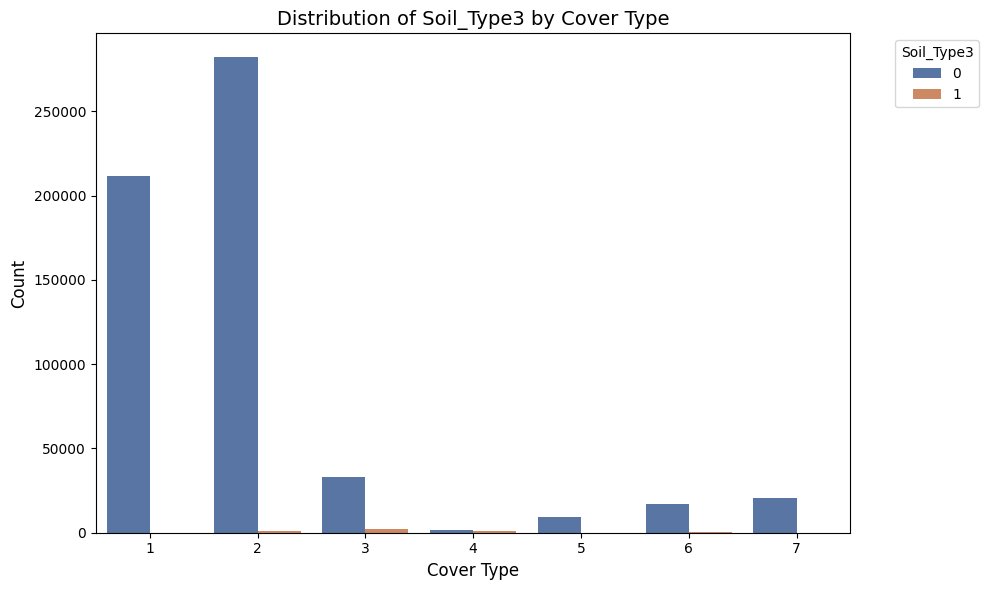

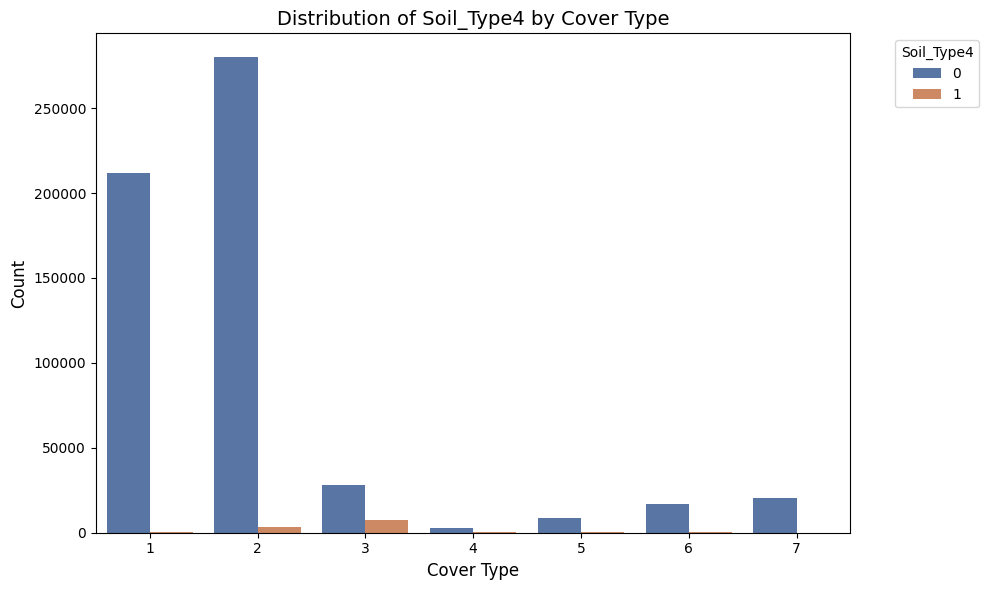

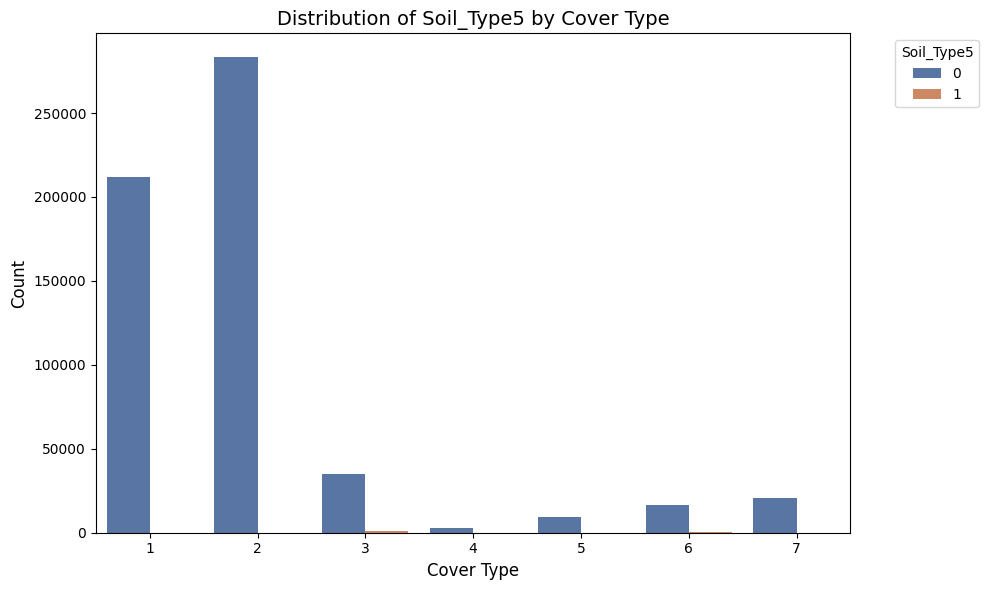

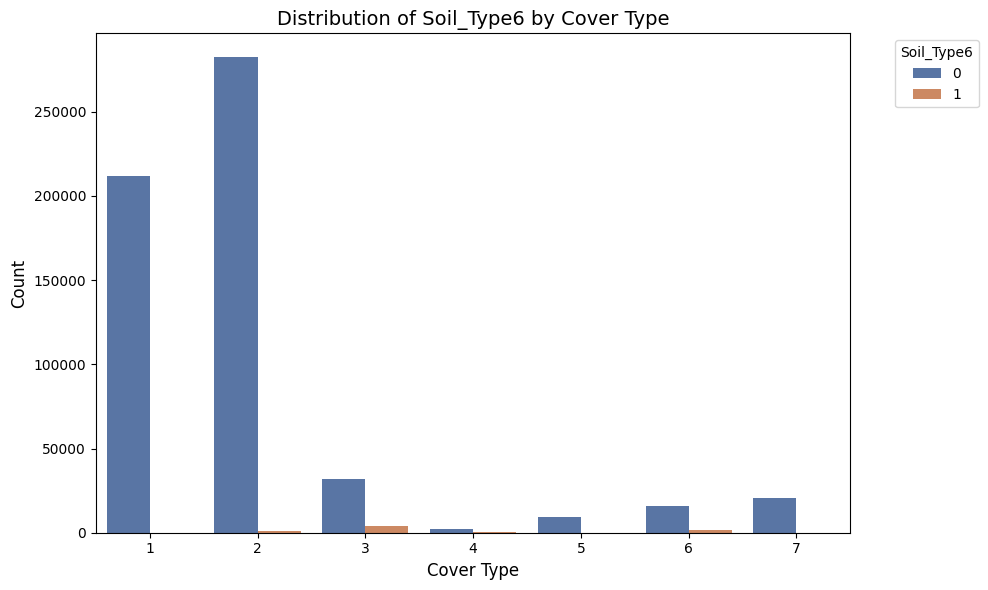

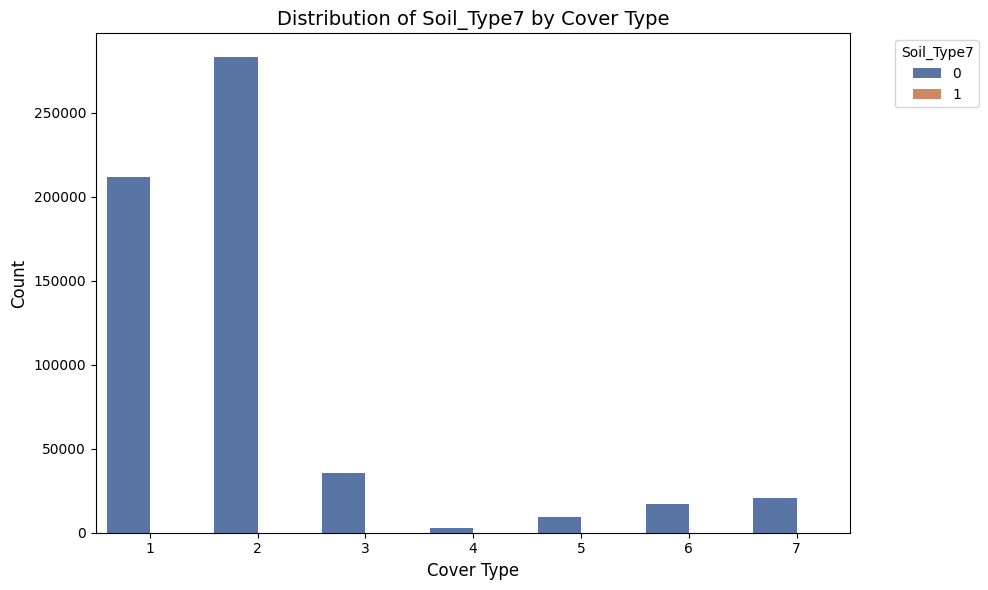

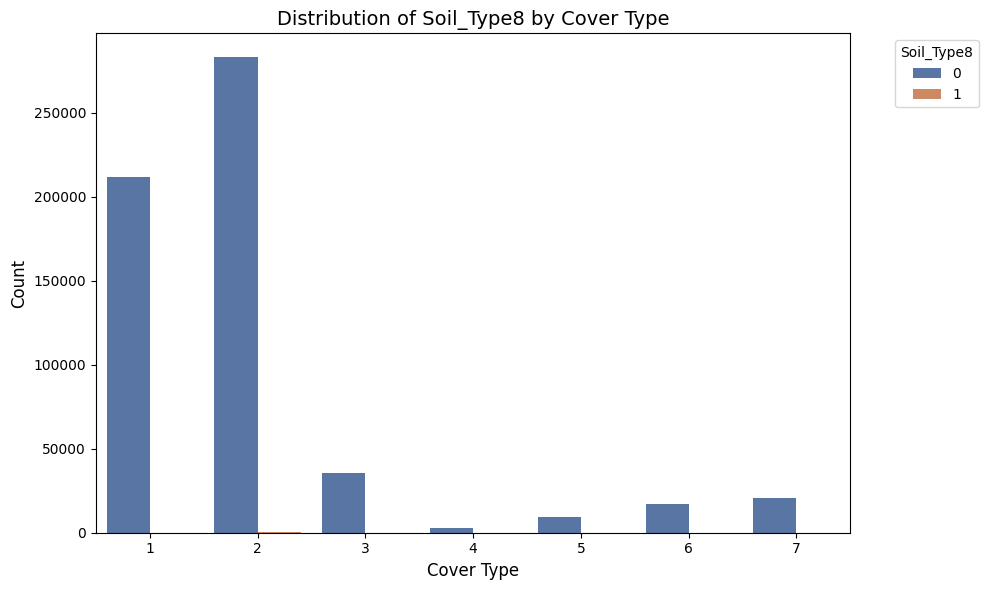

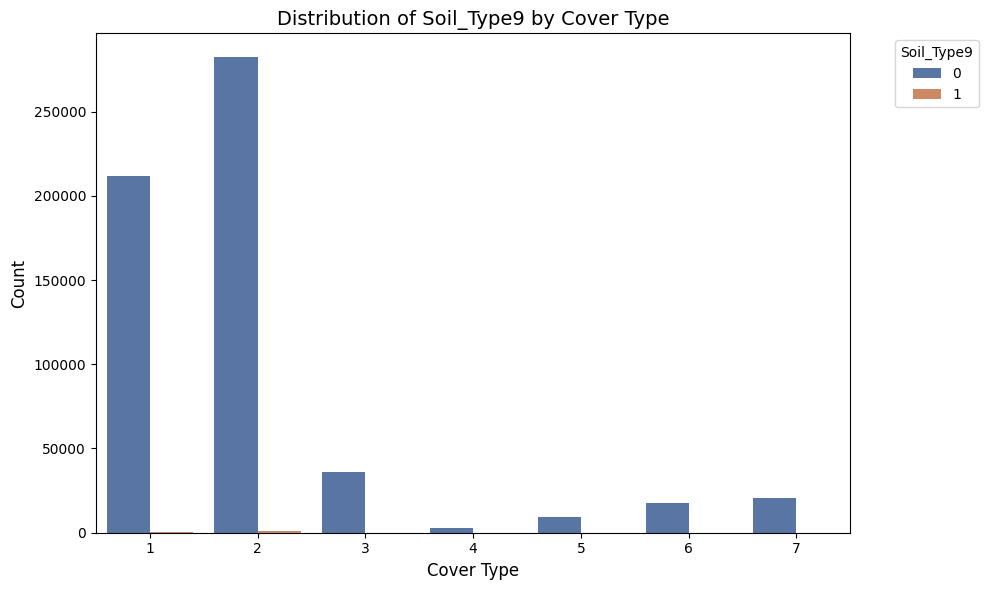

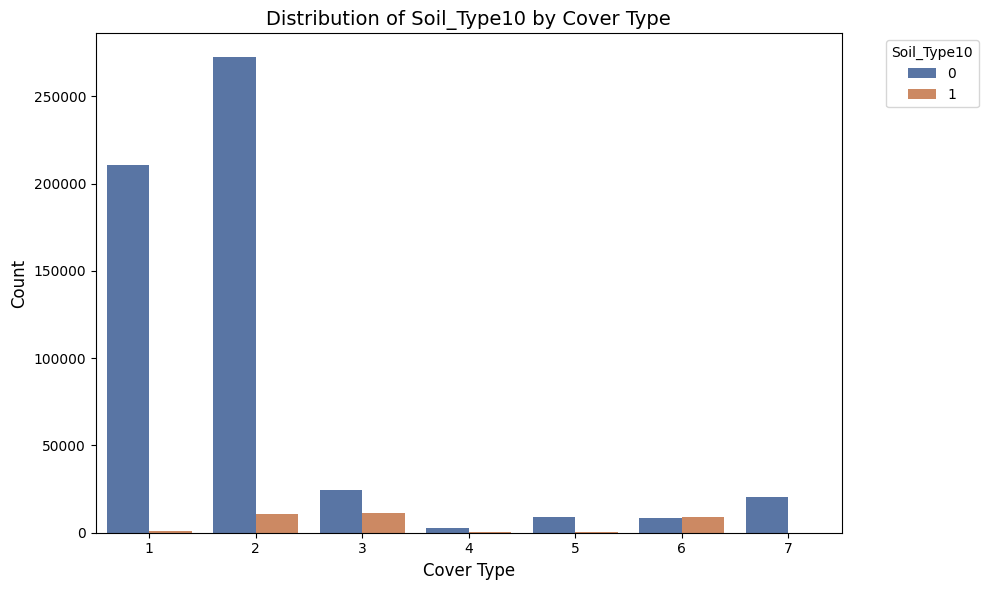

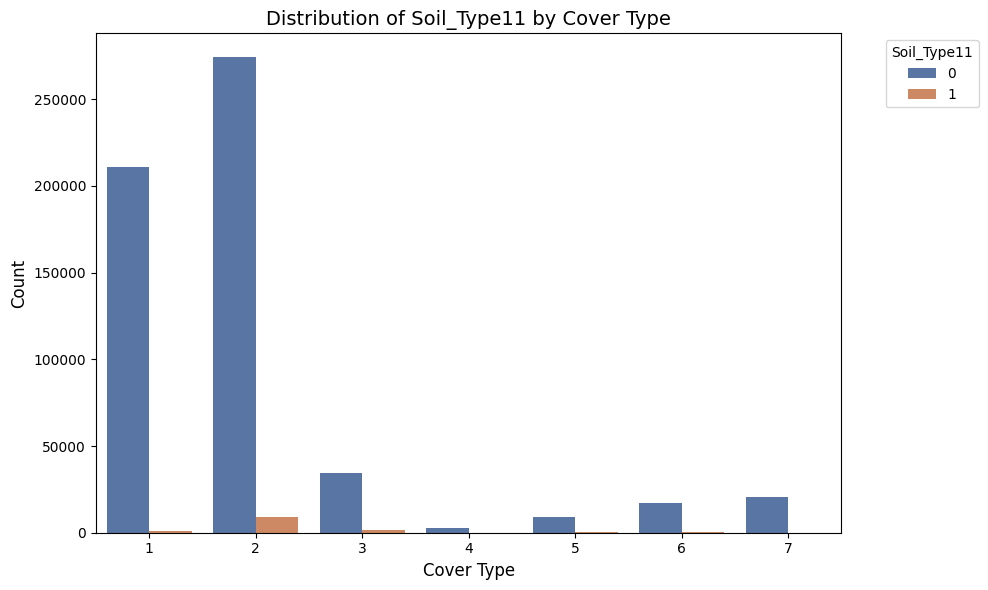

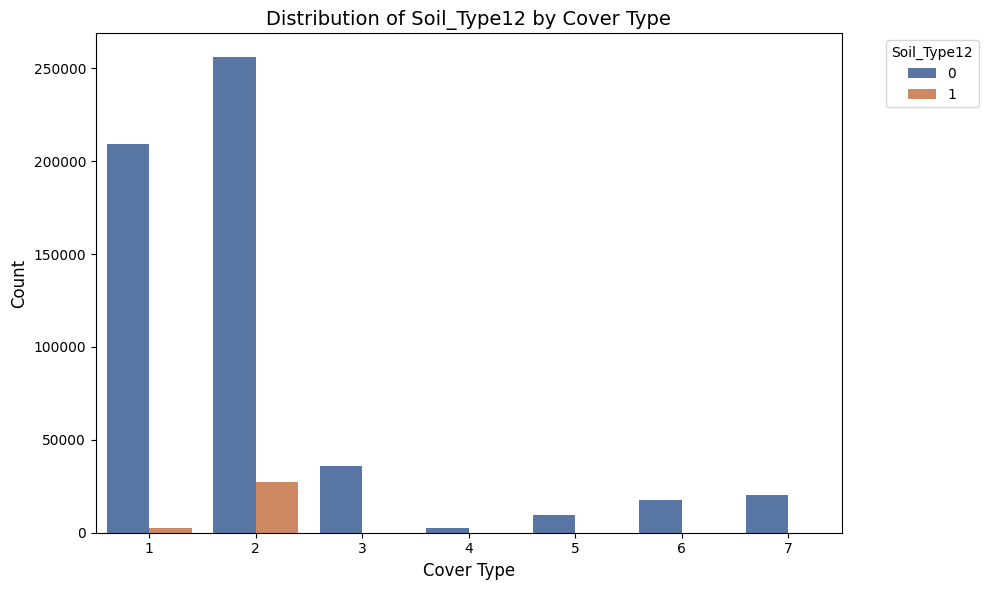

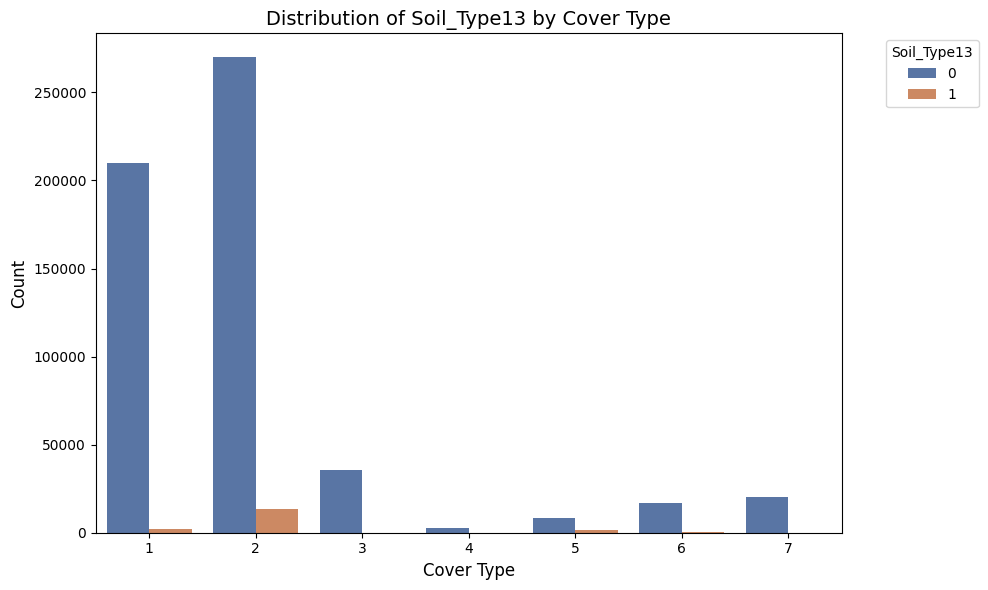

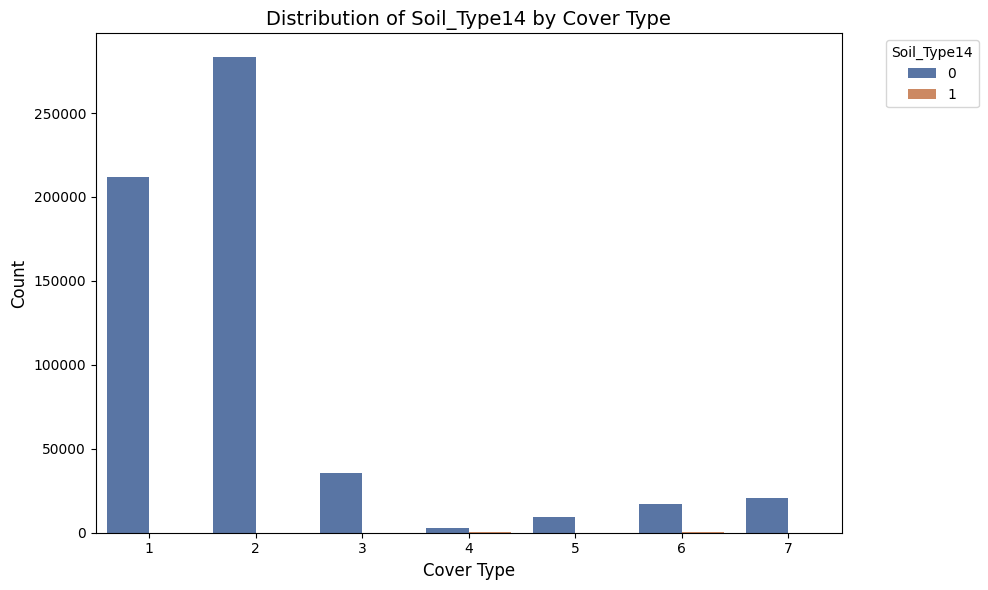

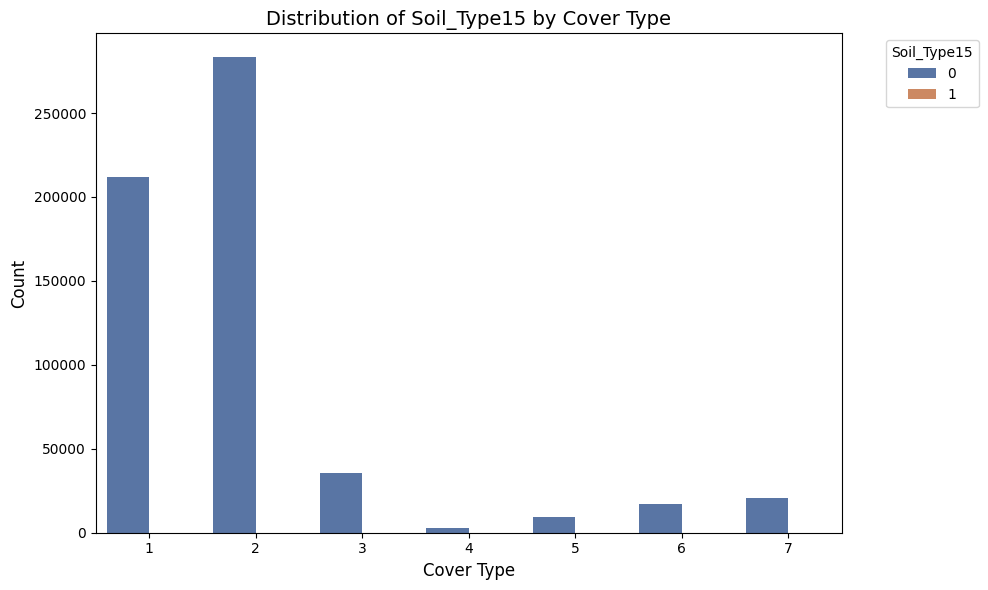

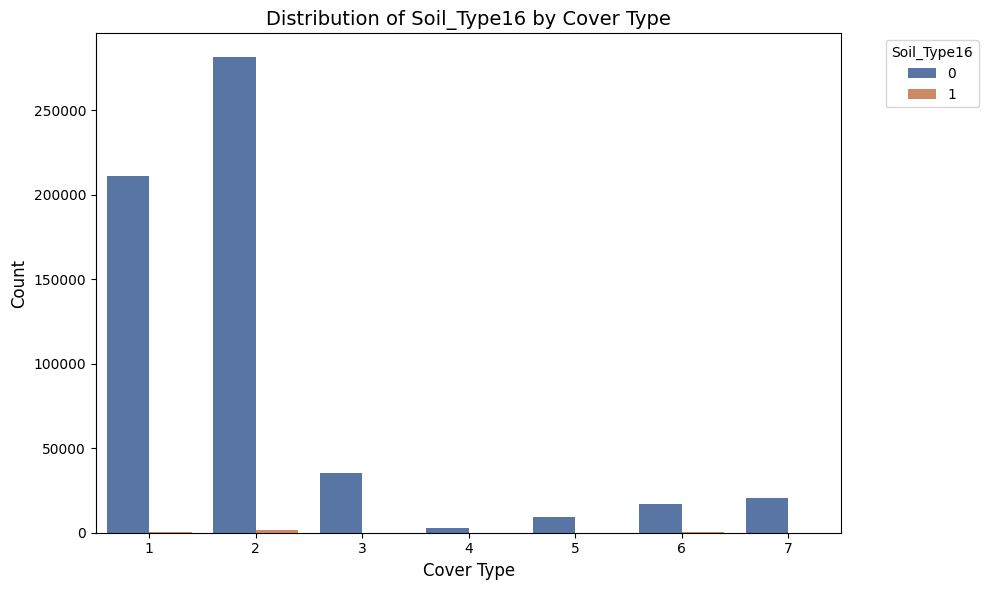

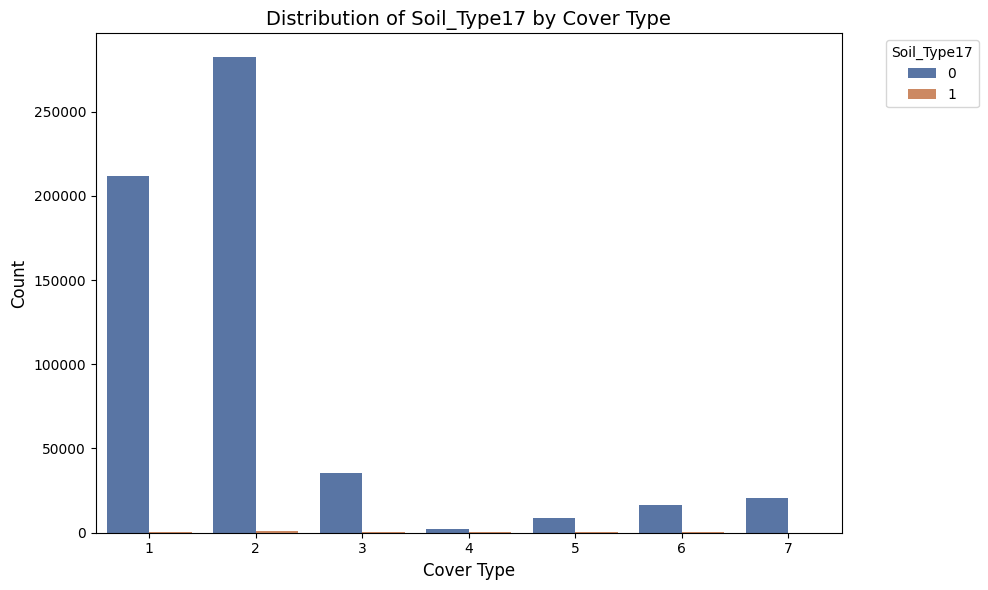

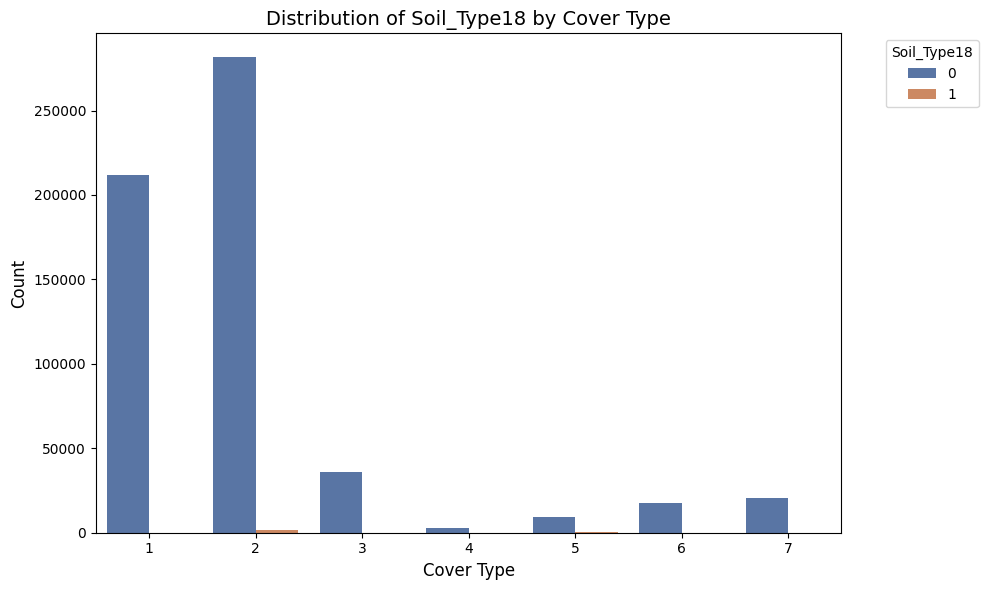

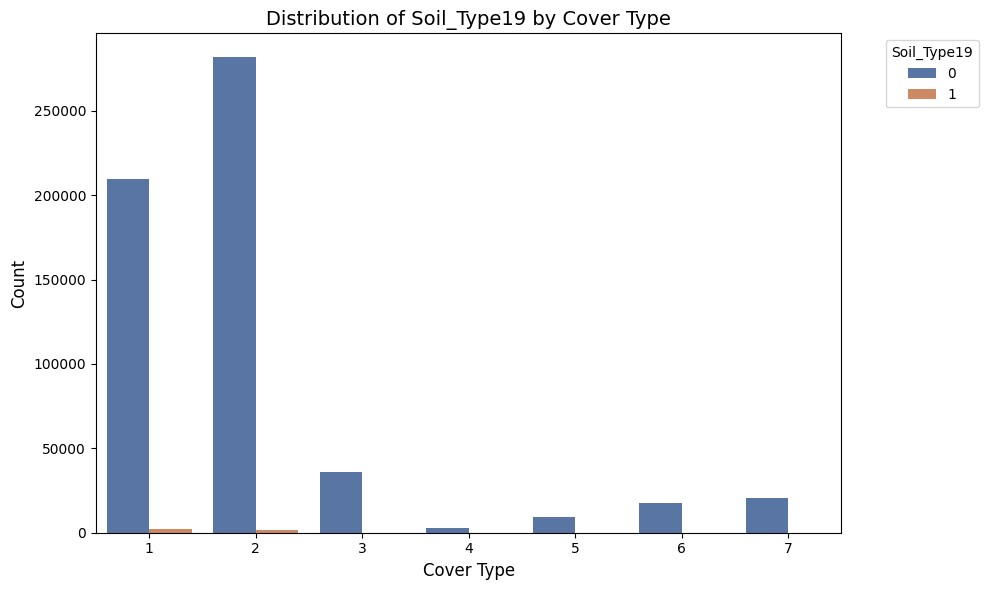

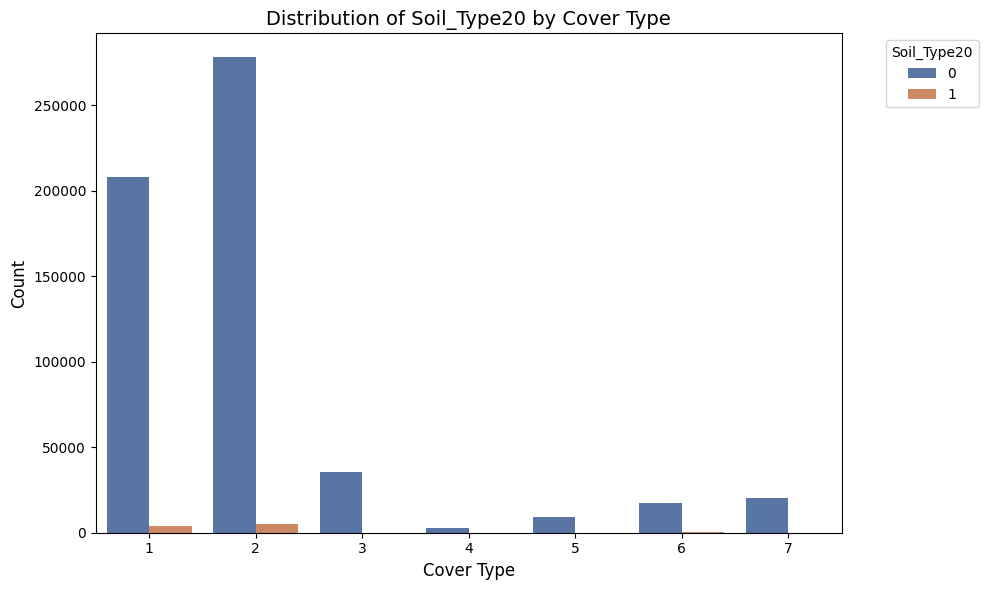

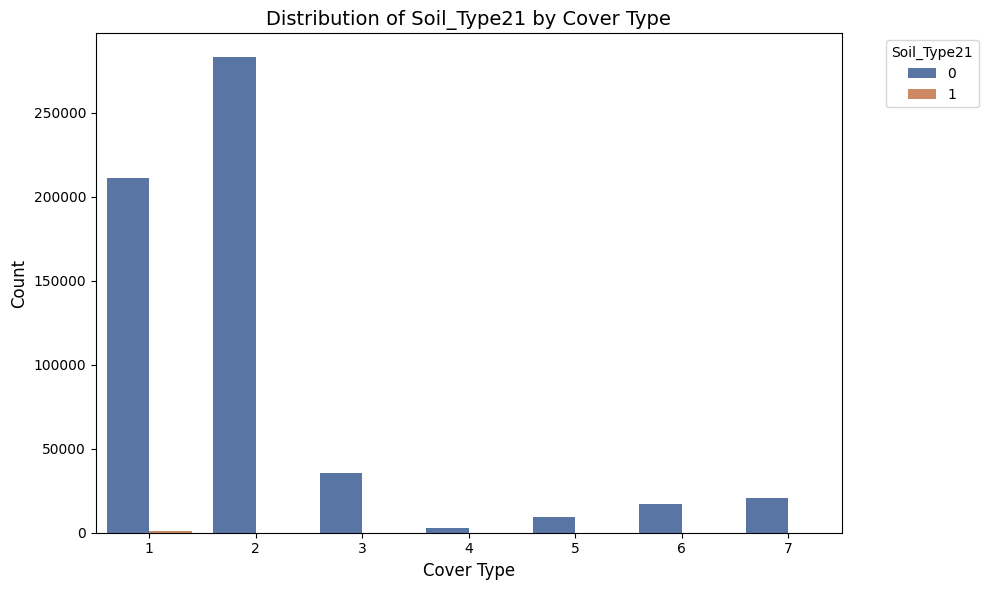

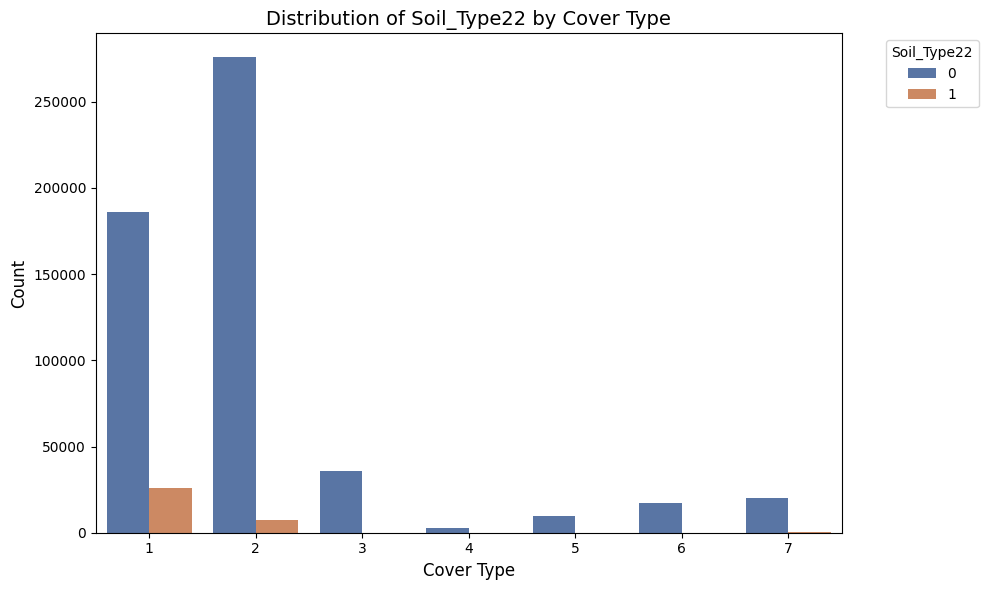

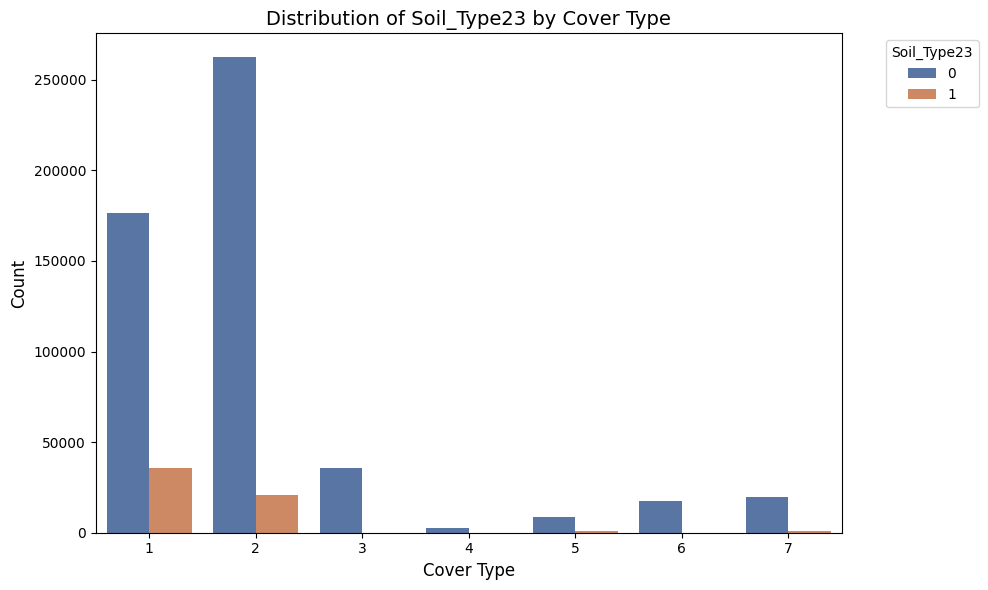

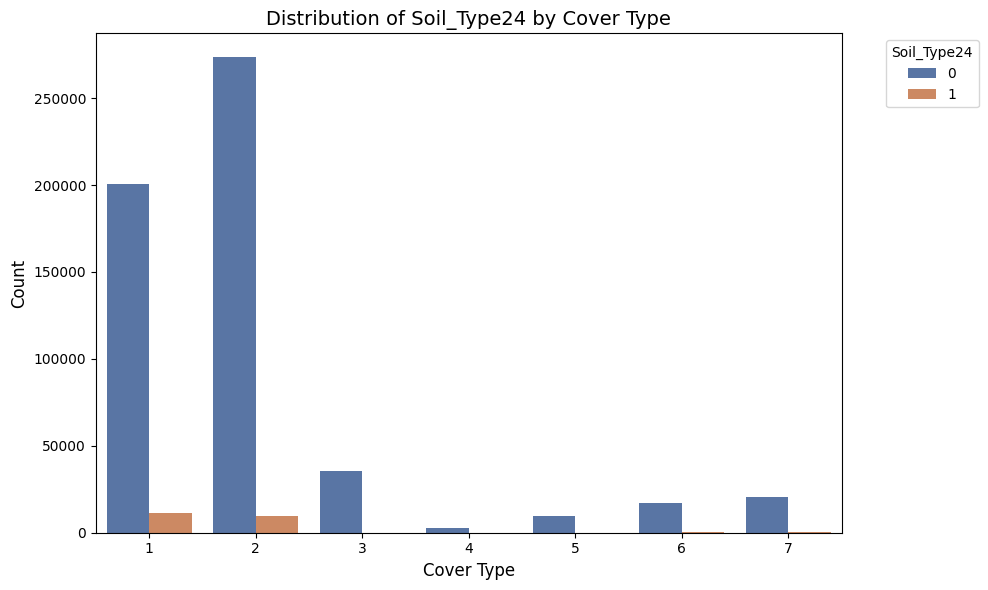

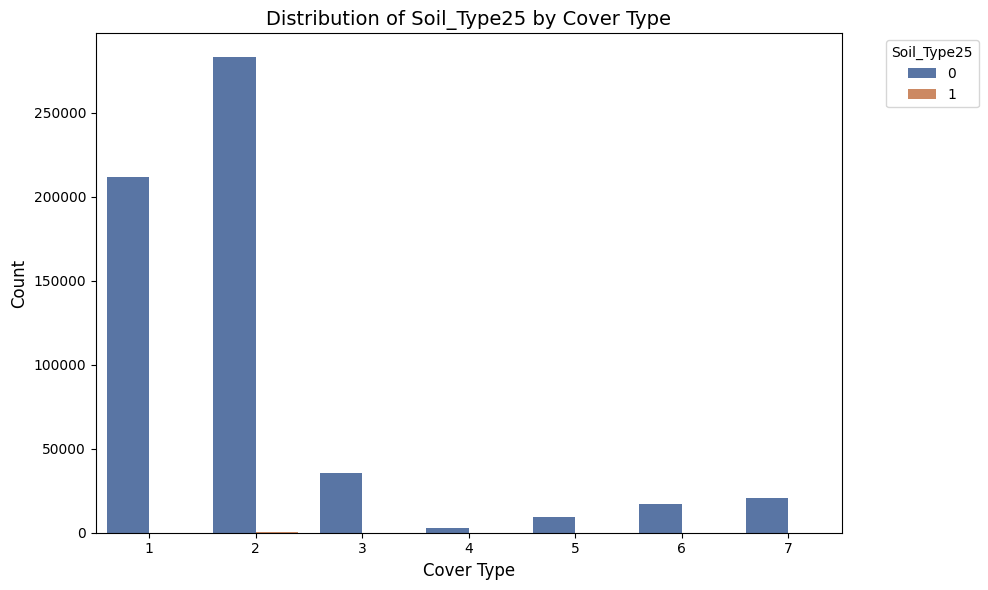

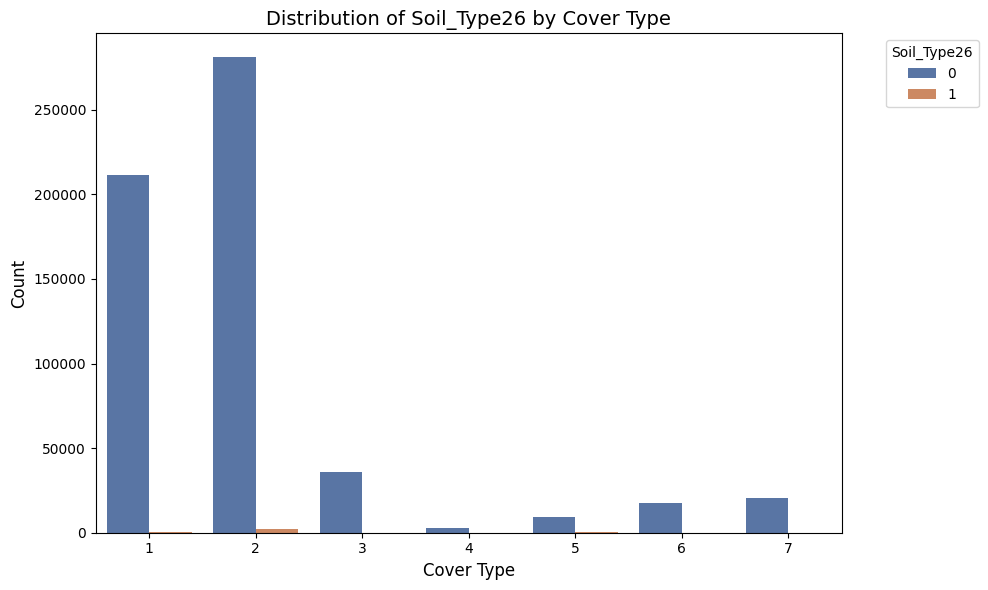

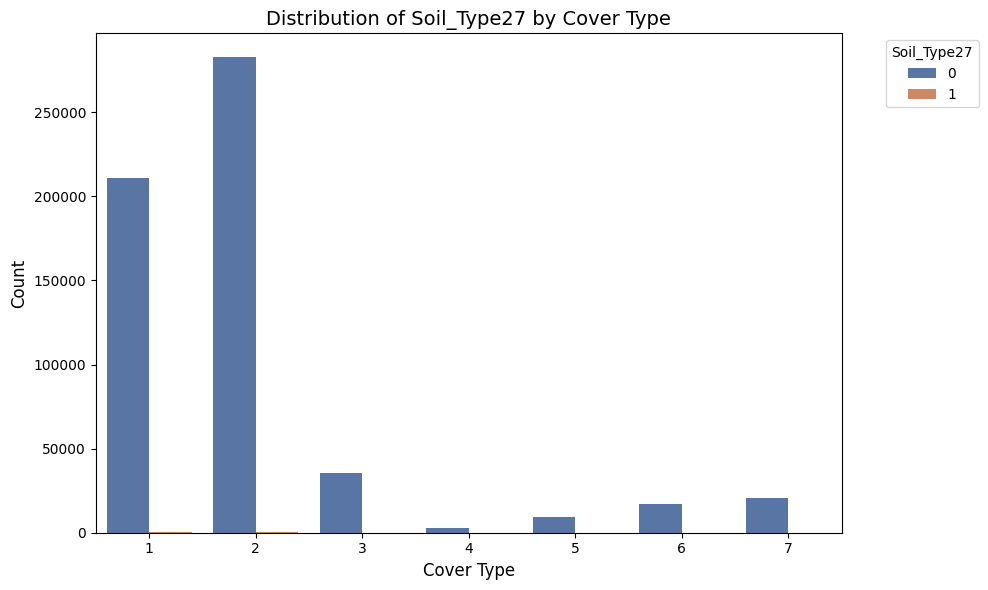

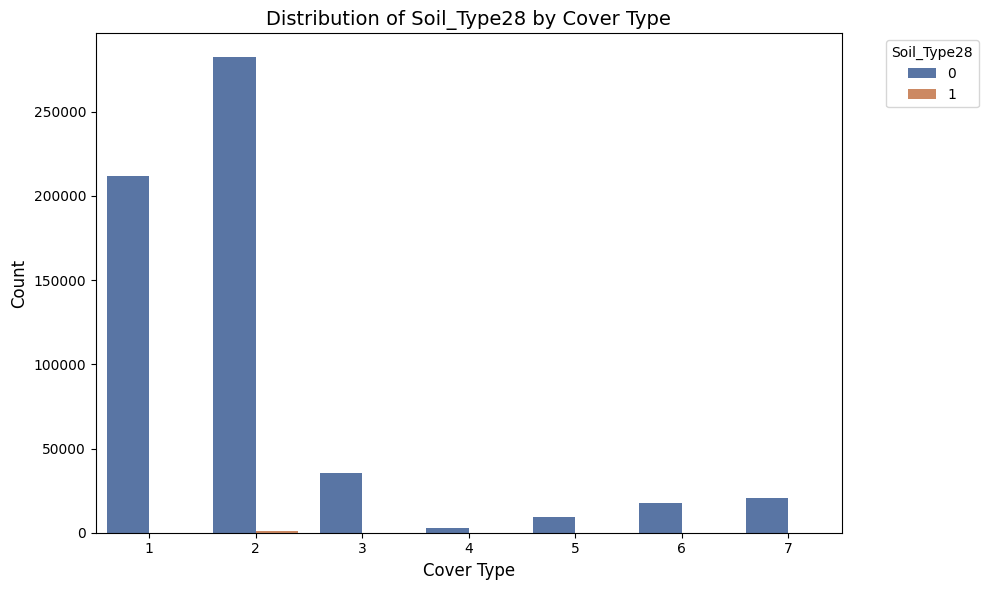

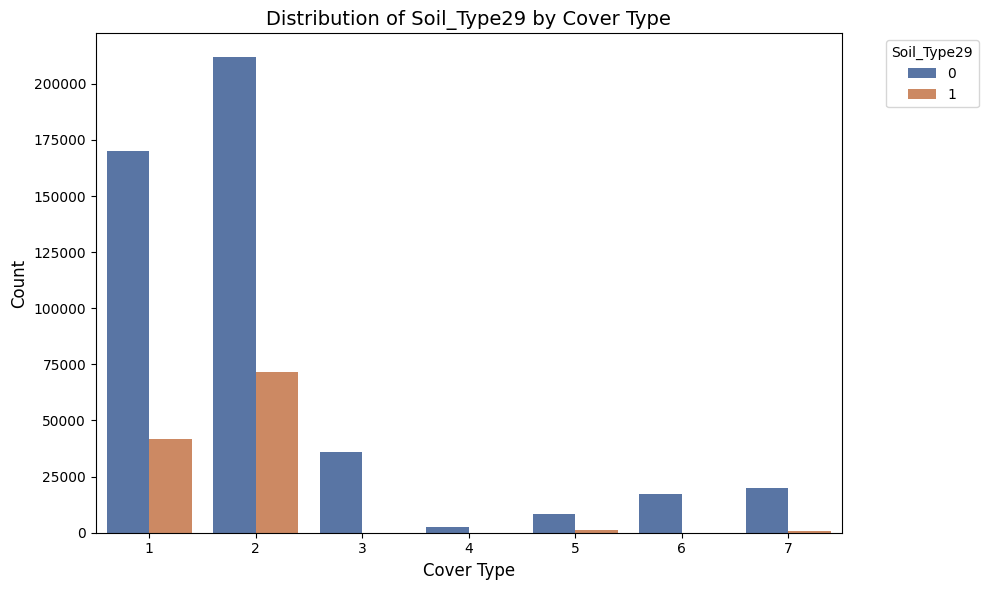

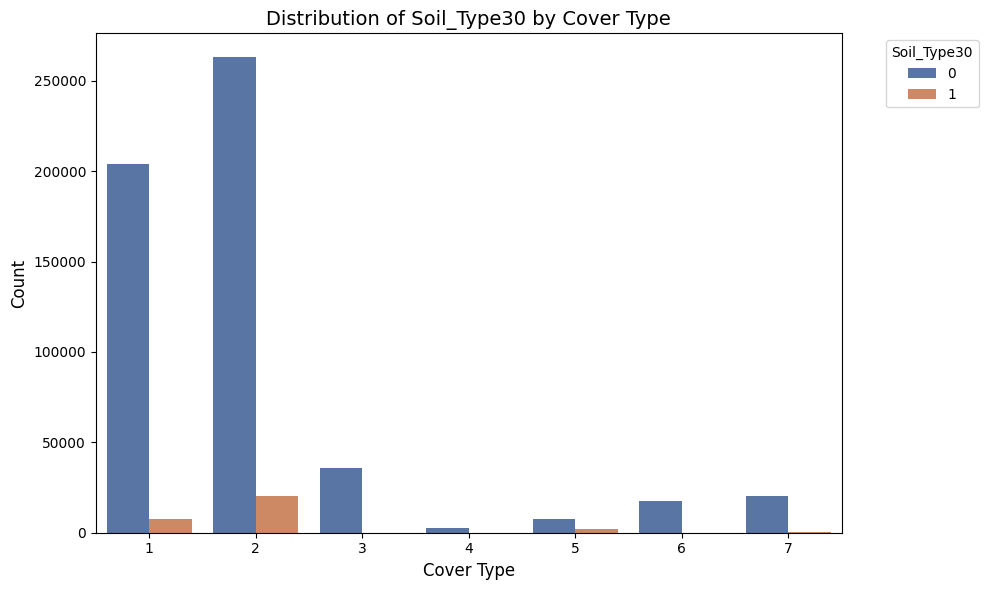

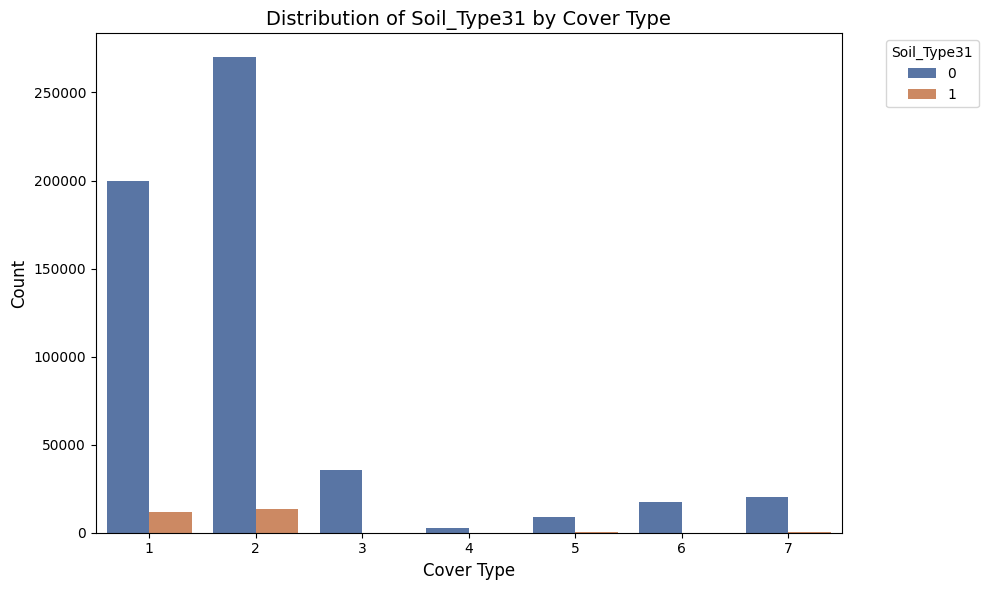

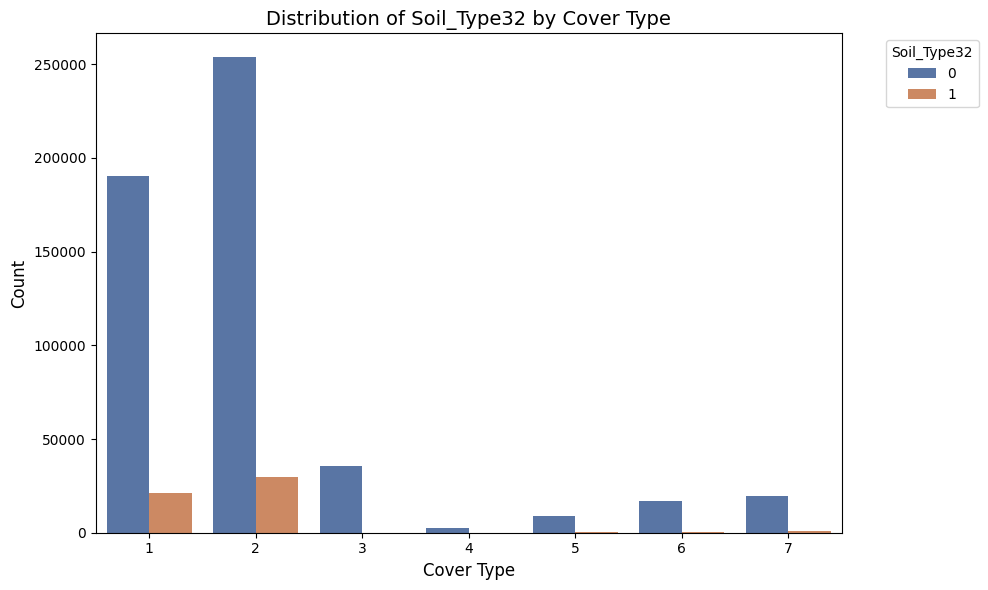

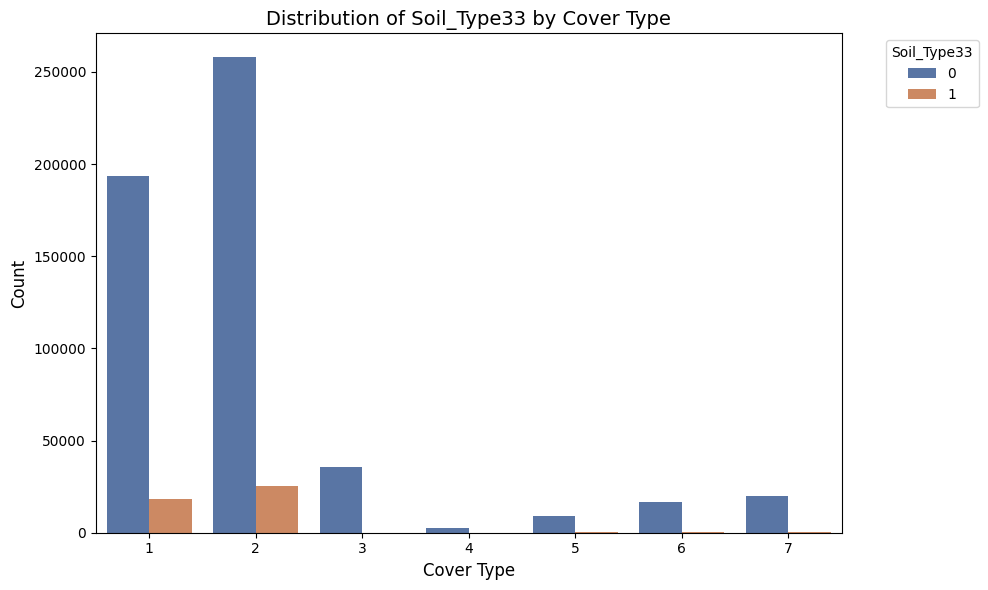

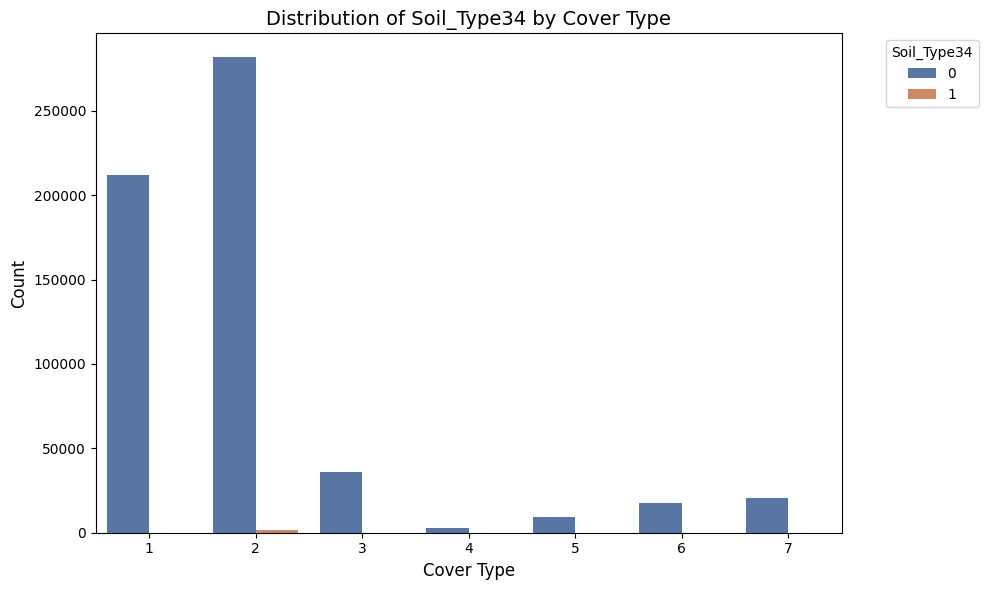

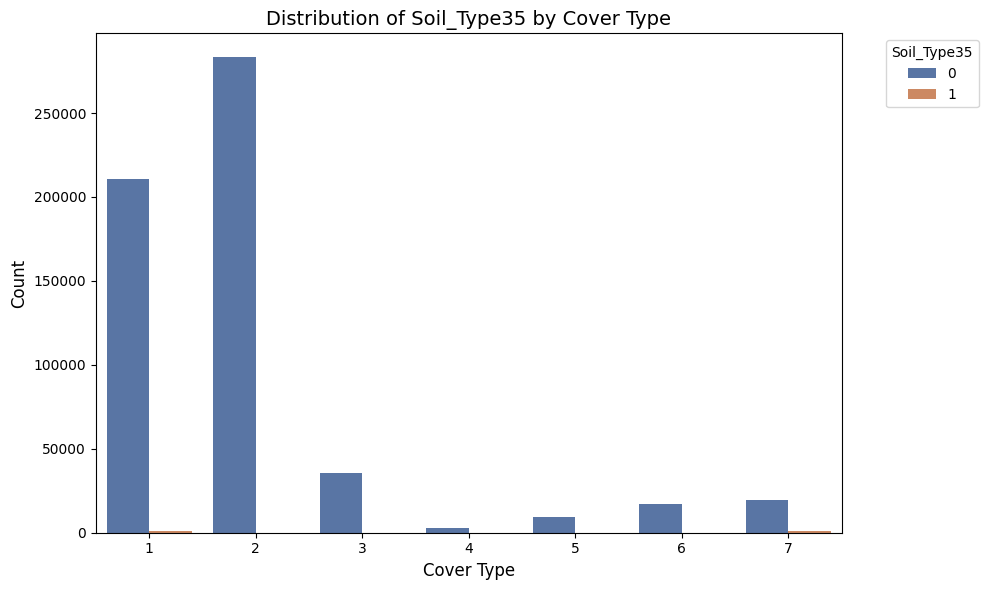

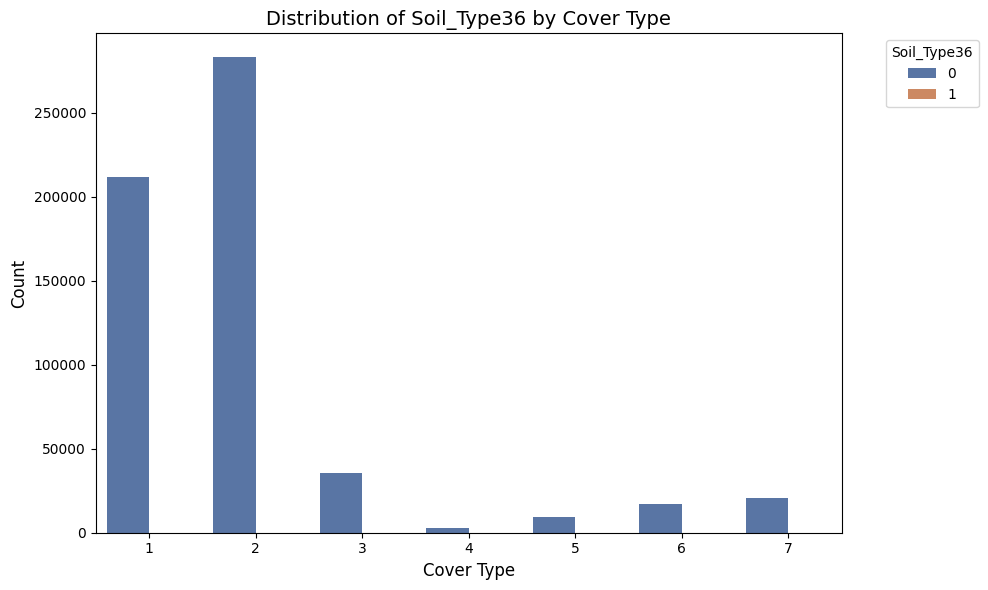

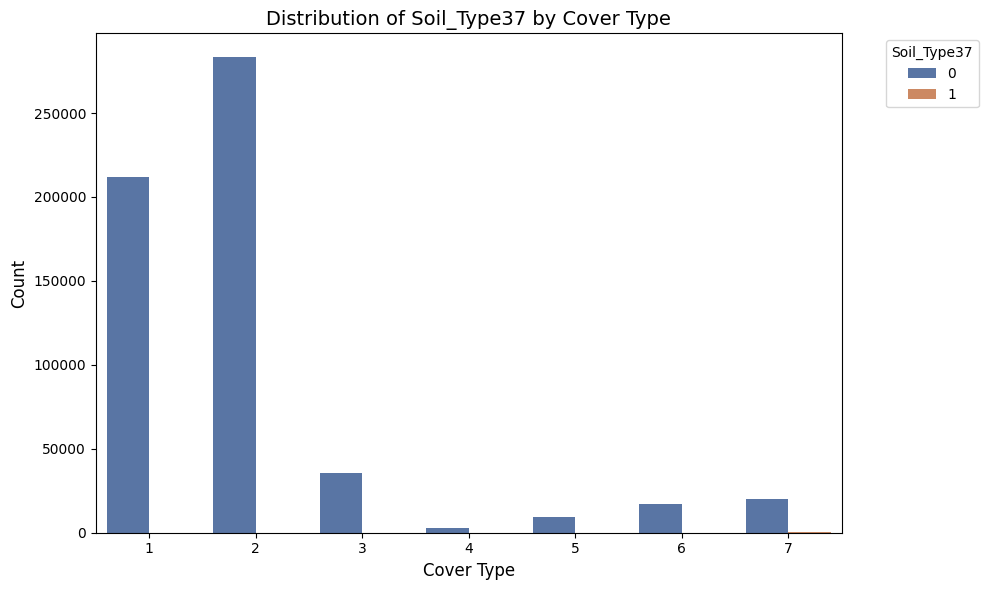

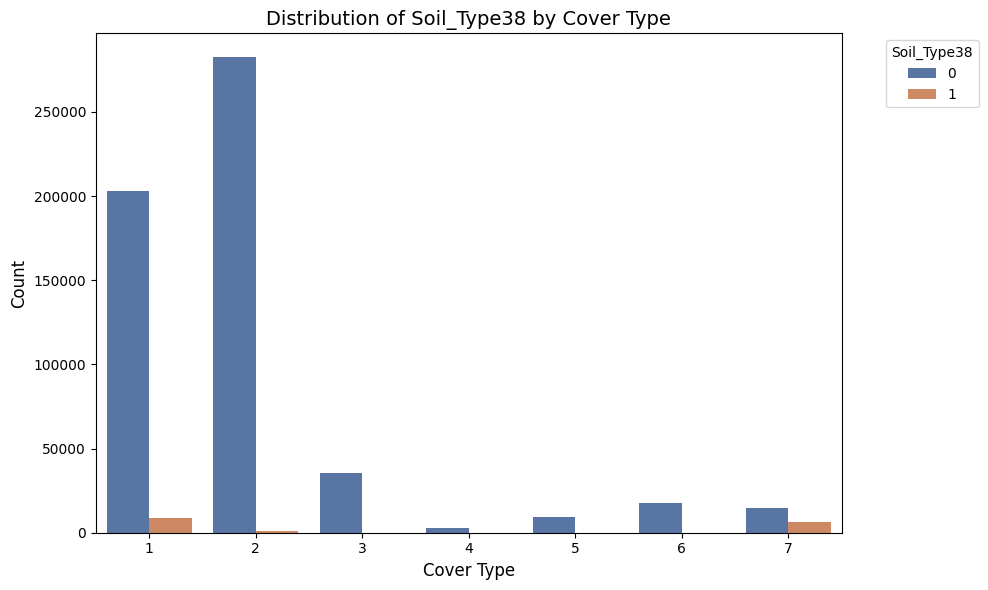

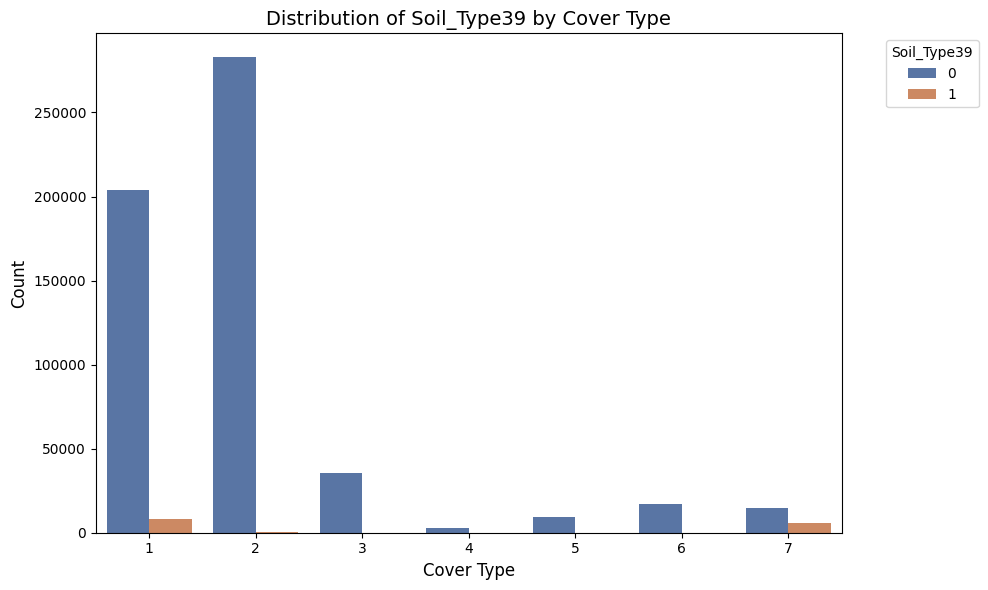

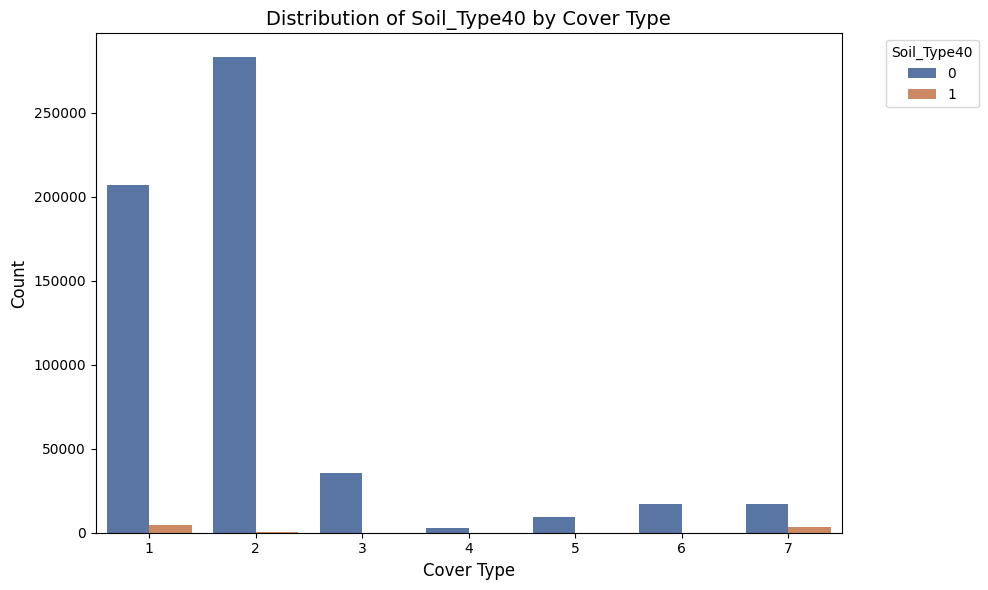

Count plots for categorical/discrete features generation complete.


In [ ]:
print("Generating count plots for categorical/discrete features against Cover_Type...")

# Ensure categorical_discrete_cols is defined from previous steps
# Exclude 'Cover_Type' itself from the features to plot against the target
categorical_features_for_analysis = [col for col in categorical_discrete_cols if col != 'Cover_Type']

for col in categorical_features_for_analysis:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x='Cover_Type', hue=col, data=df, palette='deep')
        plt.title(f'Distribution of {col} by Cover Type', fontsize=14)
        plt.xlabel('Cover Type', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in DataFrame. Skipping.")

print("Count plots for categorical/discrete features generation complete.")


### Data Analysis Key Findings

*   **Data Structure and Quality**: The dataset comprises 581,012 entries and 55 columns, all of `int64` data type. Crucially, no missing values were identified, indicating a clean dataset for analysis. The target variable is named `Cover_Type`, not 'Forest Cover Type'.
*   **Numerical Feature Distributions**:
    *   Many numerical features (e.g., `Slope`, `Horizontal_Distance_To_Hydrology`, `Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points`) exhibit right-skewed distributions, indicating a concentration of values at the lower end with a tail extending to higher values.
    *   `Elevation` is slightly left-skewed, while `Aspect` shows a multi-modal distribution.
    *   Significant outliers were observed in several distance-related numerical features, such as `Horizontal_Distance_To_Hydrology` (0 to 1397m), `Vertical_Distance_To_Hydrology` (-173m to 601m), `Horizontal_Distance_To_Roadways` (0 to 7117m), and `Horizontal_Distance_To_Fire_Points` (0 to 7173m).
*   **Categorical Feature Distributions**:
    *   `Wilderness_Area1` and `Wilderness_Area3` are more prevalent than `Wilderness_Area2` and `Wilderness_Area4`.
    *   The 40 `Soil_TypeX` features are largely sparse and one-hot encoded, with many types being rare. `Soil_Type29` appears to be the most common among the soil types.
*   **Target Variable Imbalance**: The target variable, `Cover_Type`, exhibits severe class imbalance. `Cover_Type` 2 (283,301 instances) and `Cover_Type` 1 (211,840 instances) are the most frequent, while `Cover_Type` 4 (2,747 instances) is the least common.
*   **Correlation Analysis**:
    *   Strong positive correlations exist, such as between `Elevation` and both `Horizontal_Distance_To_Roadways` and `Horizontal_Distance_To_Fire_Points`.
    *   Negative correlations were observed between `Elevation` and `Slope`, and between `Hillshade_9am` and `Hillshade_3pm`.
    *   The `Cover_Type` shows varying degrees of correlation with `Elevation`, distance features, `Hillshade` features, and specific `Wilderness_Area` and `Soil_Type` indicators.
*   **Bivariate Relationships with Cover\_Type**:
    *   Box plots for numerical features revealed distinct distributions across different `Cover_Type`s. For example, specific `Cover_Type`s are associated with higher or lower `Elevation`s and show unique patterns in `Hillshade` values.
    *   Count plots for categorical features demonstrated that specific `Wilderness_Area`s and `Soil_Type`s are strongly associated with particular `Cover_Type`s, suggesting they are important predictors. For instance, `Wilderness_Area4` is notably associated with `Cover_Type` 4 and `Cover_Type` 7.

### Insights

*   **Address Class Imbalance**: The severe class imbalance in the `Cover_Type` variable will require careful handling during model training, possibly through resampling techniques (e.g., SMOTE, ADASYN), using weighted loss functions, or selecting algorithms robust to imbalance.
*   **Handle Outliers and High Dimensionality**: Given the presence of significant outliers in numerical features and the high dimensionality coupled with sparsity (especially in `Soil_TypeX` features), preprocessing steps such as outlier treatment (clipping, winsorization), feature selection, or dimensionality reduction techniques (e.g., PCA) should be considered to improve model performance and robustness.


# Model Implementation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Separate features (X) and target (y)
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (581012, 54)
Target (y) shape: (581012,)


**Reasoning**:
The next step is to split the features (X) and target (y) into training and testing sets, as per the instructions, to prepare for model training and evaluation.



In [ ]:
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Splitting data into training and testing sets...
X_train shape: (464809, 54)
X_test shape: (116203, 54)
y_train shape: (464809,)
y_test shape: (116203,)


**Reasoning**:
Now I will apply feature scaling to the identified numerical features in the training and testing sets, as specified in the instructions. I'll use `StandardScaler` to fit on `X_train` and then transform both `X_train` and `X_test`.



In [ ]:
print("Applying StandardScaler to numerical features...")

numerical_cols_to_scale = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Feature scaling complete for numerical columns.")
print("X_train (scaled) head:\n", X_train[numerical_cols_to_scale].head())
print("X_test (scaled) head:\n", X_test[numerical_cols_to_scale].head())

Applying StandardScaler to numerical features...
Feature scaling complete for numerical columns.
X_train (scaled) head:
         Elevation    Aspect     Slope  Horizontal_Distance_To_Hydrology  \
261834   0.755252  0.206925  0.787406                          0.003068   
549114   0.383857  0.421250  1.588777                         -1.268183   
7085     1.508757  1.600035 -1.349584                         -0.505432   
436844   0.383857  0.778458 -0.681775                         -0.561932   
177145  -0.855320 -0.864698  0.653844                         -0.505432   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
261834                        0.027120                         0.260485   
549114                       -0.797161                         0.669635   
7085                         -0.402193                         0.701058   
436844                       -0.522401                         0.295756   
177145                       -0.093088               

In [ ]:
print("Applying SMOTE to training data to address class imbalance...")

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("SMOTE application complete.")
print("Original training data shapes: X_train", X_train.shape, "y_train", y_train.shape)
print("Resampled training data shapes: X_resampled", X_resampled.shape, "y_resampled", y_resampled.shape)
print("Class distribution in original y_train:\n", y_train.value_counts())
print("Class distribution in resampled y_resampled:\n", y_resampled.value_counts())

Applying SMOTE to training data to address class imbalance...
SMOTE application complete.
Original training data shapes: X_train (464809, 54) y_train (464809,)
Resampled training data shapes: X_resampled (1586480, 54) y_resampled (1586480,)
Class distribution in original y_train:
 Cover_Type
2    226640
1    169472
3     28603
7     16408
6     13894
5      7594
4      2198
Name: count, dtype: int64
Class distribution in resampled y_resampled:
 Cover_Type
2    226640
7    226640
1    226640
5    226640
3    226640
4    226640
6    226640
Name: count, dtype: int64


## K-Means Clustering and Classification Interpretation

### Subtask:
Apply K-Means clustering to the preprocessed data, map clusters to 'Cover_Type' labels, and evaluate its performance as a classification model.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

Necessary libraries imported for K-Means clustering and evaluation.


In [ ]:
# Initialize KMeans with 7 clusters (for 7 Cover_Types)
kmeans_model = KMeans(n_clusters=7, random_state=42, n_init=10) # n_init is set to 10 to suppress warning

# Fit the model to the oversampled training data
kmeans_model.fit(X_resampled)

print("KMeans model fitted to X_resampled.")

Initializing and fitting KMeans model...
KMeans model fitted to X_resampled.


In [ ]:
print("Predicting cluster labels for resampled training data...")
# Predict cluster labels for the resampled training data
kmeans_labels_resampled = kmeans_model.predict(X_resampled)

print("Creating mapping from cluster IDs to actual Cover_Type labels...")
# Create a mapping dictionary from cluster ID to actual Cover_Type label
# This is done by finding the most frequent Cover_Type within each cluster in the resampled training data
cluster_to_cover_type = {}
for cluster_id in np.unique(kmeans_labels_resampled):
    # Get the indices of samples belonging to the current cluster
    indices = np.where(kmeans_labels_resampled == cluster_id)
    # Get the actual Cover_Type labels for these samples
    actual_cover_types = y_resampled.iloc[indices]
    # Find the most frequent Cover_Type in this cluster
    most_frequent_cover_type = actual_cover_types.mode()[0]
    cluster_to_cover_type[cluster_id] = most_frequent_cover_type

print("Mapping created:", cluster_to_cover_type)

print("Predicting cluster labels for test data...")
# Predict cluster labels for the test data
kmeans_labels_test = kmeans_model.predict(X_test)

print("Mapping test cluster labels to predicted Cover_Type labels...")
# Map the test cluster labels to predicted Cover_Type labels using the created mapping
y_pred_kmeans = np.array([cluster_to_cover_type[label] for label in kmeans_labels_test])

print("Evaluating K-Means pseudo-classification performance...")
# Evaluate the pseudo-classification performance
accuracy = accuracy_score(y_test, y_pred_kmeans)
class_report = classification_report(y_test, y_pred_kmeans)
conf_matrix = confusion_matrix(y_test, y_pred_kmeans)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:\n", class_report)
print("\nConfusion Matrix:\n", conf_matrix)

print("K-Means clustering and evaluation complete.")

Predicting cluster labels for resampled training data...
Creating mapping from cluster IDs to actual Cover_Type labels...
Mapping created: {np.int32(0): np.int64(6), np.int32(1): np.int64(1), np.int32(2): np.int64(5), np.int32(3): np.int64(1), np.int32(4): np.int64(4), np.int32(5): np.int64(7), np.int32(6): np.int64(4)}
Predicting cluster labels for test data...
Mapping test cluster labels to predicted Cover_Type labels...
Evaluating K-Means pseudo-classification performance...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Accuracy: 0.3110

Classification Report:
               precision    recall  f1-score   support

           1       0.44      0.77      0.56     42368
           2       0.00      0.00      0.00     56661
           3       0.00      0.00      0.00      7151
           4       0.04      0.89      0.07       549
           5       0.06      0.35      0.10      1899
           6       0.20      0.40      0.27      3473
           7       0.10      0.27      0.15      4102

    accuracy                           0.31    116203
   macro avg       0.12      0.38      0.16    116203
weighted avg       0.17      0.31      0.22    116203


Confusion Matrix:
 [[32483     0     0   727  3983   701  4474]
 [37156     0     0  6034  5875  2408  5188]
 [  334     0     0  4138   271  2330    78]
 [    0     0     0   488     0    60     1]
 [  648     0     0   445   660    40   106]
 [  169     0     0  1794   114  1391     5]
 [ 2477     0     0     0   495     8  1122]]
K-Means clustering and e

# Task
## Gaussian Mixture Model (GMM) and Classification Interpretation

### Subtask:
Implement a Gaussian Mixture Model (GMM) for clustering on the preprocessed data. Similar to K-Means, map each GMM component to the dominant 'Cover_Type' it represents and evaluate its performance as a classification method.

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np


Necessary libraries imported for GMM clustering.


In [ ]:
gmm_model = GaussianMixture(n_components=7, random_state=42, covariance_type='full') # 'full' is default, explicit for clarity

# Fit the model to the oversampled training data
gmm_model.fit(X_resampled)

print("GMM model fitted to X_resampled.")

Initializing and fitting GMM model...
GMM model fitted to X_resampled.


In [ ]:
print("Predicting GMM component labels for resampled training data...")
# Predict GMM component labels for the resampled training data
gmm_labels_resampled = gmm_model.predict(X_resampled)

print("Creating mapping from GMM component IDs to actual Cover_Type labels...")
gmm_component_to_cover_type = {}
for component_id in np.unique(gmm_labels_resampled):
    # Get the indices of samples belonging to the current component
    indices = np.where(gmm_labels_resampled == component_id)
    # Get the actual Cover_Type labels for these samples
    actual_cover_types_in_component = y_resampled.iloc[indices]
    # Find the most frequent Cover_Type in this component
    most_frequent_cover_type = actual_cover_types_in_component.mode()[0]
    gmm_component_to_cover_type[component_id] = most_frequent_cover_type

print("Mapping created:", gmm_component_to_cover_type)

print("Predicting GMM component labels for test data...")
# Predict GMM component labels for the test data
gmm_labels_test = gmm_model.predict(X_test)

print("Mapping test GMM component labels to predicted Cover_Type labels...")
# Map the test GMM component labels to predicted Cover_Type labels using the created mapping
y_pred_gmm = np.array([gmm_component_to_cover_type[label] for label in gmm_labels_test])

print("Evaluating GMM pseudo-classification performance...")
# Evaluate the pseudo-classification performance
accuracy_gmm = accuracy_score(y_test, y_pred_gmm)
class_report_gmm = classification_report(y_test, y_pred_gmm)
conf_matrix_gmm = confusion_matrix(y_test, y_pred_gmm)

print(f"\nAccuracy (GMM): {accuracy_gmm:.4f}")
print("\nClassification Report (GMM):\n", class_report_gmm)
print("\nConfusion Matrix (GMM):\n", conf_matrix_gmm)

print("GMM clustering and evaluation complete.")

Predicting GMM component labels for resampled training data...
Creating mapping from GMM component IDs to actual Cover_Type labels...
Mapping created: {np.int64(0): np.int64(3), np.int64(1): np.int64(7), np.int64(2): np.int64(6), np.int64(3): np.int64(4), np.int64(4): np.int64(1), np.int64(5): np.int64(5), np.int64(6): np.int64(4)}
Predicting GMM component labels for test data...
Mapping test GMM component labels to predicted Cover_Type labels...
Evaluating GMM pseudo-classification performance...

Accuracy (GMM): 0.1986

Classification Report (GMM):
               precision    recall  f1-score   support

           1       0.52      0.32      0.40     42368
           2       0.00      0.00      0.00     56661
           3       0.55      0.46      0.50      7151
           4       0.01      0.62      0.02       549
           5       0.03      0.03      0.03      1899
           6       0.11      0.64      0.19      3473
           7       0.12      0.86      0.21      4102

    accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Necessary libraries imported for Logistic Regression.


In [ ]:
logistic_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)

# Train the model using the oversampled training data
logistic_model.fit(X_resampled, y_resampled)

print("Logistic Regression model trained.")

Initializing and training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained.


In [ ]:
y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
class_report_logistic = classification_report(y_test, y_pred_logistic)
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

print(f"\nAccuracy (Logistic Regression): {accuracy_logistic:.4f}")
print("\nClassification Report (Logistic Regression):\n", class_report_logistic)
print("\nConfusion Matrix (Logistic Regression):\n", conf_matrix_logistic)

print("Logistic Regression model evaluation complete.")

Making predictions on the test set...
Evaluating Logistic Regression model performance...

Accuracy (Logistic Regression): 0.5640

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           1       0.67      0.64      0.65     42368
           2       0.79      0.47      0.59     56661
           3       0.62      0.57      0.59      7151
           4       0.27      0.89      0.42       549
           5       0.08      0.71      0.14      1899
           6       0.30      0.60      0.40      3473
           7       0.39      0.88      0.54      4102

    accuracy                           0.56    116203
   macro avg       0.45      0.68      0.48    116203
weighted avg       0.69      0.56      0.60    116203


Confusion Matrix (Logistic Regression):
 [[27183  6749    49     0  2843   401  5143]
 [13189 26754  1599    46 12105  2438   530]
 [    0    24  4088   916   296  1827     0]
 [    0     0    32   486     0    31     0]
 [  

## Support Vector Machine (SVM) Classifier Implementation

### Subtask:
Train a Support Vector Machine (SVM) classifier on the preprocessed data. Given the large dataset size, consider strategies like sampling or using a linear SVM variant if computational cost is high. Evaluate its performance on the test set.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Necessary libraries imported for LinearSVC.")

Necessary libraries imported for LinearSVC.


In [ ]:
linsvc_model = LinearSVC(multi_class='ovr', random_state=42, max_iter=10000, dual=False)

# Train the model using the oversampled training data
linsvc_model.fit(X_resampled, y_resampled)

print("LinearSVC model trained.")

Initializing and training LinearSVC model...
LinearSVC model trained.


In [ ]:
y_pred_linsvc = linsvc_model.predict(X_test)

accuracy_linsvc = accuracy_score(y_test, y_pred_linsvc)
class_report_linsvc = classification_report(y_test, y_pred_linsvc)
conf_matrix_linsvc = confusion_matrix(y_test, y_pred_linsvc)

print(f"\nAccuracy (LinearSVC): {accuracy_linsvc:.4f}")
print("\nClassification Report (LinearSVC):\n", class_report_linsvc)
print("\nConfusion Matrix (LinearSVC):\n", conf_matrix_linsvc)

print("LinearSVC model evaluation complete.")

Making predictions on the test set...
Evaluating LinearSVC model performance...

Accuracy (LinearSVC): 0.5521

Classification Report (LinearSVC):
               precision    recall  f1-score   support

           1       0.65      0.66      0.65     42368
           2       0.80      0.44      0.57     56661
           3       0.63      0.54      0.58      7151
           4       0.26      0.89      0.40       549
           5       0.08      0.72      0.14      1899
           6       0.29      0.60      0.39      3473
           7       0.39      0.87      0.54      4102

    accuracy                           0.55    116203
   macro avg       0.44      0.68      0.47    116203
weighted avg       0.69      0.55      0.59    116203


Confusion Matrix (LinearSVC):
 [[27828  6059    46     0  2947   425  5063]
 [14358 24917  1404    58 12777  2662   485]
 [    0    23  3893   980   296  1959     0]
 [    0     0    29   491     0    29     0]
 [   53   248   159     0  1367    72     0]

Visualizing the Confusion Matrix (LinearSVC)


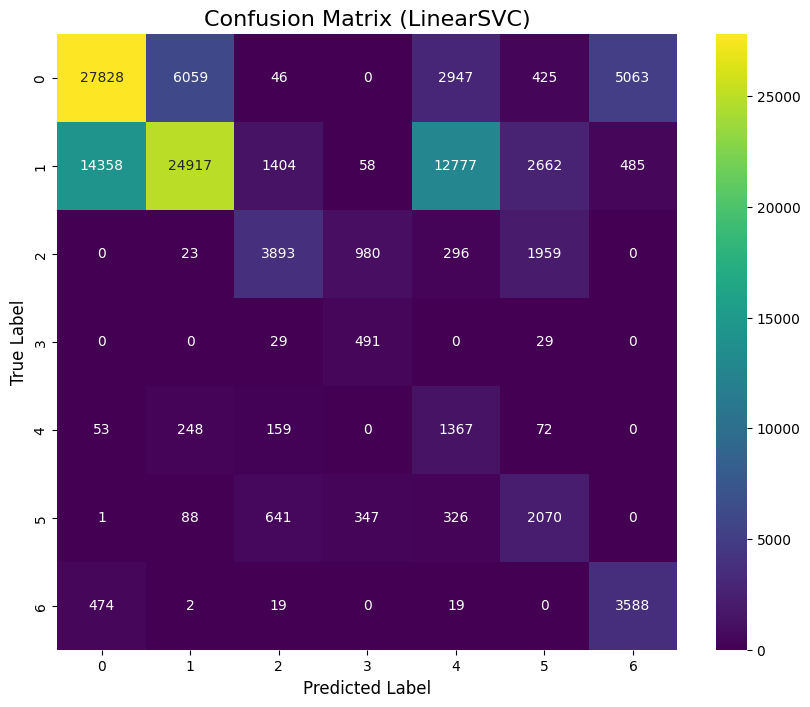

Confusion Matrix visualization complete.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_test_adjusted_labels = np.arange(7)

print("Visualizing the Confusion Matrix (LinearSVC)")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='viridis',
            xticklabels=[str(i) for i in y_test_adjusted_labels],
            yticklabels=[str(i) for i in y_test_adjusted_labels])
plt.title('Confusion Matrix (LinearSVC)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix visualization complete.")

## Neural Network Classifier Implementation

### Subtask:
Design and train a simple Neural Network for the multiclass classification task. This will involve defining the network architecture (layers, activation functions), compiling the model, and training it on the preprocessed data. Evaluate its performance on the test set.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np


In [ ]:
print("Defining Neural Network architecture...")

num_features = X_resampled.shape[1]
num_classes = len(np.unique(y_resampled))

model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)), # Input layer
    Dense(64, activation='relu'), # Hidden layer
    Dense(num_classes, activation='softmax') # Output layer
])

print("Neural Network architecture defined.")
model.summary()

Defining Neural Network architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network architecture defined.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,135 (31.78 KB)

 Trainable params: 8,135 (31.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Evaluating Neural Network model performance...")

y_pred_nn_probabilities = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn_probabilities, axis=1)

accuracy_nn = accuracy_score(y_test_adjusted, y_pred_nn)
class_report_nn = classification_report(y_test_adjusted, y_pred_nn)
conf_matrix_nn = confusion_matrix(y_test_adjusted, y_pred_nn)

print(f"\nAccuracy (Neural Network): {accuracy_nn:.4f}")
print("\nClassification Report (Neural Network):\n", class_report_nn)
print("\nConfusion Matrix (Neural Network):\n", conf_matrix_nn)

print("Neural Network model evaluation complete.")

Evaluating Neural Network model performance...
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step

Accuracy (Neural Network): 0.8691

Classification Report (Neural Network):
               precision    recall  f1-score   support

           0       0.85      0.88      0.86     42368
           1       0.91      0.86      0.88     56661
           2       0.84      0.95      0.89      7151
           3       0.77      0.93      0.85       549
           4       0.55      0.96      0.70      1899
           5       0.84      0.79      0.81      3473
           6       0.94      0.82      0.87      4102

    accuracy                           0.87    116203
   macro avg       0.81      0.88      0.84    116203
weighted avg       0.87      0.87      0.87    116203


Confusion Matrix (Neural Network):
 [[37147  4816    18     0   173    26   188]
 [ 5793 48587   633     4  1247   353    44]
 [    0    56  6822   101    27   145     0]
 [    0     0    32   511     0     6     0]
 [    3    54    14

In [ ]:
import tensorflow as tf

# Check if a GPU is available
gpu_available = tf.config.list_physical_devices('GPU')

if gpu_available:
    print(f"GPU is available: {gpu_available}")
    print("Training will utilize the GPU if configured correctly.")
else:
    print("No GPU devices found. TensorFlow will use CPU.")
    print("To enable GPU, go to Runtime -> Change runtime type -> Hardware accelerator -> GPU.")

# Optionally, verify the device placement for a simple operation
print("\nVerifying device placement for a simple operation:")
with tf.device('/GPU:0' if gpu_available else '/CPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
    c = tf.matmul(a, b)
    print("Tensor 'c' computed on device:", c.device)

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training will utilize the GPU if configured correctly.

Verifying device placement for a simple operation:
Tensor 'c' computed on device: /job:localhost/replica:0/task:0/device:GPU:0


In [ ]:
print("Training Neural Network model...")

# Adjust target labels to be 0-indexed for sparse_categorical_crossentropy
y_resampled_adjusted = y_resampled - 1
y_test_adjusted = y_test - 1

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_resampled, y_resampled_adjusted, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

print("Neural Network model training complete.")

Training Neural Network model...
Epoch 1/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 127s 3ms/step - accuracy: 0.9310 - loss: 0.1807 - val_accuracy: 0.9026 - val_loss: 0.2779
Epoch 2/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 113s 3ms/step - accuracy: 0.9313 - loss: 0.1799 - val_accuracy: 0.8808 - val_loss: 0.3089
Epoch 3/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 113s 3ms/step - accuracy: 0.9318 - loss: 0.1777 - val_accuracy: 0.8992 - val_loss: 0.2762
Epoch 4/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - accuracy: 0.9323 - loss: 0.1766 - val_accuracy: 0.9265 - val_loss: 0.2069
Epoch 5/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 113s 3ms/step - accuracy: 0.9332 - loss: 0.1752 - val_accuracy: 0.8753 - val_loss: 0.3476
Epoch 6/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 114s 3ms/step - accuracy: 0.9330 - loss: 0.1746 - val_accuracy: 0.9018 - val_loss: 0.2822
Epoch 7/20
39662/39662 ━━━━━━━━━━━━━━━━━━━━ 116s 3ms/step - accuracy: 0.9337 - loss: 0.1743 - val_accuracy: 0.8662 - val_loss: 0.3928
Epoch 8/20
39662/39662 ━━━━━━

In [ ]:
print("Evaluating Neural Network model performance...")

y_pred_nn_probabilities = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn_probabilities, axis=1)

accuracy_nn = accuracy_score(y_test_adjusted, y_pred_nn)
class_report_nn = classification_report(y_test_adjusted, y_pred_nn)
conf_matrix_nn = confusion_matrix(y_test_adjusted, y_pred_nn)

print(f"\nAccuracy (Neural Network): {accuracy_nn:.4f}")
print("\nClassification Report (Neural Network):\n", class_report_nn)
print("\nConfusion Matrix (Neural Network):\n", conf_matrix_nn)

print("Neural Network model evaluation complete.")

Evaluating Neural Network model performance...
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step

Accuracy (Neural Network): 0.8747

Classification Report (Neural Network):
               precision    recall  f1-score   support

           0       0.90      0.82      0.86     42368
           1       0.87      0.91      0.89     56661
           2       0.88      0.93      0.91      7151
           3       0.70      0.95      0.81       549
           4       0.63      0.95      0.76      1899
           5       0.80      0.86      0.83      3473
           6       0.90      0.89      0.89      4102

    accuracy                           0.87    116203
   macro avg       0.81      0.90      0.85    116203
weighted avg       0.88      0.87      0.87    116203


Confusion Matrix (Neural Network):
 [[34573  7266    14     0   126    22   367]
 [ 3306 51428   494     4   902   501    26]
 [    0    66  6672   164    32   217     0]
 [    0     0    17   524     0     8     0]
 [    6    62    1

Visualizing the Neural Network Confusion Matrix...


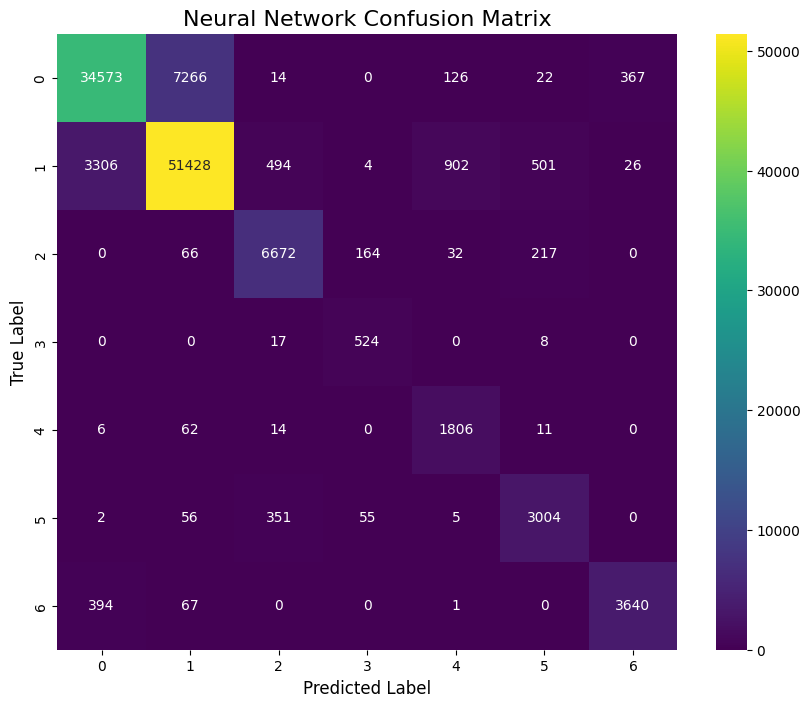

Confusion Matrix visualization complete.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing the Neural Network Confusion Matrix...")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in np.unique(y_test_adjusted)],
            yticklabels=[str(i) for i in np.unique(y_test_adjusted)])
plt.title('Neural Network Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix visualization complete.")